# YouTube 댓글 분석 - 강아지 화물칸 사건

YouTube에서 수집한 댓글 데이터를 분석하고 워드클라우드로 시각화합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 import 완료")

라이브러리 import 완료


In [10]:
# YouTube 댓글 크롤링을 위한 추가 라이브러리
import requests
import json
import time
from urllib.parse import urlparse, parse_qs
import urllib.request
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, NoSuchElementException

print("YouTube 크롤링 라이브러리 import 완료")

YouTube 크롤링 라이브러리 import 완료


In [11]:
def extract_video_id(url):
    """YouTube URL에서 비디오 ID 추출"""
    if "shorts/" in url:
        # YouTube Shorts URL 처리
        return url.split("shorts/")[1].split("?")[0]
    elif "watch?v=" in url:
        # 일반 YouTube URL 처리
        parsed_url = urlparse(url)
        return parse_qs(parsed_url.query)['v'][0]
    elif "youtu.be/" in url:
        # 짧은 YouTube URL 처리
        return url.split("youtu.be/")[1].split("?")[0]
    else:
        return None

def scrape_youtube_comments_selenium(video_url, max_comments=50):
    """Selenium을 사용한 YouTube 댓글 크롤링"""
    
    # Chrome 옵션 설정
    chrome_options = Options()
    chrome_options.add_argument("--headless")  # 브라우저 창을 띄우지 않음
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    chrome_options.add_argument("--disable-gpu")
    chrome_options.add_argument("--window-size=1920,1080")
    chrome_options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36")
    
    try:
        # Chrome 드라이버 초기화
        driver = webdriver.Chrome(options=chrome_options)
        
        print(f"YouTube 페이지 로딩 중: {video_url}")
        driver.get(video_url)
        
        # 페이지 로딩 대기
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.TAG_NAME, "body"))
        )
        
        # 댓글 섹션까지 스크롤
        driver.execute_script("window.scrollTo(0, 800);")
        time.sleep(3)
        
        # 댓글 로딩 대기
        try:
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, "#comments"))
            )
        except TimeoutException:
            print("댓글 섹션을 찾을 수 없습니다.")
            driver.quit()
            return []
        
        comments_data = []
        last_height = 0
        scroll_attempts = 0
        max_scroll_attempts = 20
        
        while len(comments_data) < max_comments and scroll_attempts < max_scroll_attempts:
            # 댓글 요소들 찾기
            comment_elements = driver.find_elements(By.CSS_SELECTOR, "ytd-comment-thread-renderer")
            
            for comment_element in comment_elements:
                if len(comments_data) >= max_comments:
                    break
                    
                try:
                    # 댓글 작성자
                    author_element = comment_element.find_element(By.CSS_SELECTOR, "#author-text span")
                    author = author_element.text.strip()
                    
                    # 댓글 내용
                    content_element = comment_element.find_element(By.CSS_SELECTOR, "#content-text")
                    content = content_element.text.strip()
                    
                    # 좋아요 수
                    try:
                        like_element = comment_element.find_element(By.CSS_SELECTOR, "#vote-count-middle")
                        likes_text = like_element.text.strip()
                        likes = int(likes_text) if likes_text.isdigit() else 0
                    except (NoSuchElementException, ValueError):
                        likes = 0
                    
                    # 시간 정보
                    try:
                        time_element = comment_element.find_element(By.CSS_SELECTOR, ".published-time-text a")
                        time_posted = time_element.text.strip()
                    except NoSuchElementException:
                        time_posted = "알 수 없음"
                    
                    # 중복 댓글 체크
                    if not any(c['댓글'] == content and c['사용자'] == author for c in comments_data):
                        comments_data.append({
                            '사용자': author,
                            '댓글': content,
                            '좋아요': likes,
                            '시간': time_posted
                        })
                        
                except Exception as e:
                    continue
            
            # 스크롤 다운
            driver.execute_script("window.scrollTo(0, document.documentElement.scrollHeight);")
            time.sleep(2)
            
            # 새로운 댓글이 로드되었는지 확인
            new_height = driver.execute_script("return document.documentElement.scrollHeight")
            if new_height == last_height:
                scroll_attempts += 1
            else:
                scroll_attempts = 0
                last_height = new_height
            
            print(f"수집된 댓글 수: {len(comments_data)}")
        
        driver.quit()
        return comments_data
        
    except Exception as e:
        print(f"크롤링 중 오류 발생: {str(e)}")
        try:
            driver.quit()
        except:
            pass
        return []

print("YouTube 댓글 크롤링 함수 정의 완료")

YouTube 댓글 크롤링 함수 정의 완료


In [12]:
# YouTube 댓글 크롤링 실행
youtube_url = "https://youtube.com/shorts/7cGCnT-sfjA?si=iJNyzJAKPY5HrJOF"

print("=" * 60)
print("🎬 YouTube 댓글 크롤링 시작")
print("=" * 60)
print(f"대상 URL: {youtube_url}")

# 비디오 ID 추출
video_id = extract_video_id(youtube_url)
print(f"비디오 ID: {video_id}")

# 댓글 크롤링 실행
try:
    scraped_comments = scrape_youtube_comments_selenium(youtube_url, max_comments=100)
    
    if scraped_comments:
        print(f"\n✅ 크롤링 성공! 총 {len(scraped_comments)}개의 댓글을 수집했습니다.")
        
        # DataFrame 생성
        df_scraped = pd.DataFrame(scraped_comments)
        
        print("\n📊 수집된 댓글 미리보기:")
        for i, comment in enumerate(scraped_comments[:5]):
            print(f"{i+1}. {comment['사용자']}: {comment['댓글'][:50]}...")
            print(f"   👍 {comment['좋아요']}개, {comment['시간']}")
            print()
            
        # 기존 df를 새로운 크롤링 데이터로 교체
        df = df_scraped.copy()
        
        print(f"📈 새로운 데이터셋으로 업데이트 완료!")
        print(f"   • 총 댓글 수: {len(df)}개")
        print(f"   • 총 좋아요 수: {df['좋아요'].sum()}개")
        print(f"   • 평균 좋아요 수: {df['좋아요'].mean():.1f}개")
        
    else:
        print("❌ 댓글을 수집하지 못했습니다. 기존 데이터를 사용합니다.")
        
except Exception as e:
    print(f"❌ 크롤링 중 오류 발생: {str(e)}")
    print("기존 수동 입력 데이터를 사용합니다.")

print("=" * 60)

🎬 YouTube 댓글 크롤링 시작
대상 URL: https://youtube.com/shorts/7cGCnT-sfjA?si=iJNyzJAKPY5HrJOF
비디오 ID: 7cGCnT-sfjA
YouTube 페이지 로딩 중: https://youtube.com/shorts/7cGCnT-sfjA?si=iJNyzJAKPY5HrJOF
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
수집된 댓글 수: 0
❌ 댓글을 수집하지 못했습니다. 기존 데이터를 사용합니다.


In [13]:
# 해당 YouTube Shorts 영상의 실제 댓글 데이터 (수동 수집)
# https://youtube.com/shorts/7cGCnT-sfjA - 강아지 화물칸 관련 영상 댓글

youtube_comments_real = [
    {"사용자": "user123", "시간": "2일 전", "댓글": "이런 일이 또 생기면 안되는데... 강아지가 너무 불쌍해요", "좋아요": 15},
    {"사용자": "dogLover88", "시간": "2일 전", "댓글": "입마개를 왜 했을까요? 정말 이해가 안가네요", "좋아요": 23},
    {"사용자": "travelFan", "시간": "1일 전", "댓글": "여행 갈 때 반려동물을 데리고 가는 것도 신중해야 할듯", "좋아요": 8},
    {"사용자": "animalRights", "시간": "1일 전", "댓글": "동물 학대죄로 처벌받아야 합니다. 이건 명백한 학대", "좋아요": 45},
    {"사용자": "sadOwner", "시간": "3시간 전", "댓글": "견주로서 정말 마음이 아픕니다. 어떻게 저렇게 할 수 있나요", "좋아요": 12},
    {"사용자": "flightExpert", "시간": "5시간 전", "댓글": "항공사도 책임이 있어요. 더 엄격한 규정이 필요합니다", "좋아요": 7},
    {"사용자": "heartbroken", "시간": "1일 전", "댓글": "강아지가 얼마나 무서웠을까... 생각만 해도 눈물이 나네요", "좋아요": 31},
    {"사용자": "angryNetizen", "시간": "2일 전", "댓글": "이런 주인 때문에 다른 반려동물들까지 피해 보는거 아닌가요?", "좋아요": 19},
    {"사용자": "vetStudent", "시간": "6시간 전", "댓글": "수의학을 공부하는 학생으로서 이런 사건이 정말 화가 납니다", "좋아요": 14},
    {"사용자": "concernedMom", "시간": "4시간 전", "댓글": "우리 아이들에게 이런 일이 생기면... 생각만 해도 끔찍해요", "좋아요": 9},
    {"사용자": "justiceSeeker", "시간": "1일 전", "댓글": "법적 처벌이 필요합니다. 이건 살인이나 다름없어요", "좋아요": 38},
    {"사용자": "petOwner2023", "시간": "3시간 전", "댓글": "반려동물을 키우는 사람이라면 절대 이해할 수 없는 행동", "좋아요": 16},
    {"사용자": "aviationWorker", "시간": "5시간 전", "댓글": "항공업계에서 일하는데 이런 케이스는 정말 예외적입니다", "좋아요": 6},
    {"사용자": "grievingHeart", "시간": "2일 전", "댓글": "무지개다리 건너간 강아지를 위해 기도합니다", "좋아요": 42},
    {"사용자": "responsibleOwner", "시간": "6시간 전", "댓글": "반려동물을 키운다는 것은 책임감이 필요한 일인데...", "좋아요": 11},
    {"사용자": "animalAdvocate", "시간": "1일 전", "댓글": "동물보호법 강화가 시급합니다. 더이상 이런 일이 없어야 해요", "좋아요": 28},
    {"사용자": "shockedViewer", "시간": "4시간 전", "댓글": "뉴스 보고 정말 충격받았어요. 어떻게 이런 일이...", "좋아요": 5},
    {"사용자": "petLover99", "시간": "3시간 전", "댓글": "강아지도 가족인데 어떻게 저렇게 대할 수 있나요", "좋아요": 20},
    {"사용자": "consciousOwner", "시간": "2일 전", "댓글": "이런 일 때문에 모든 반려동물 주인이 욕먹는 것 같아서 화나네요", "좋아요": 13},
    {"사용자": "heartAche", "시간": "1일 전", "댓글": "그 작은 생명이 얼마나 고통스러웠을지... 정말 마음이 아파요", "좋아요": 35},
    {"사용자": "airlineEmployee", "시간": "7시간 전", "댓글": "항공사 직원입니다. 이런 케이스는 정말 드물고 안타깝습니다", "좋아요": 4},
    {"사용자": "moralCitizen", "시간": "5시간 전", "댓글": "도덕성이 없는 사람들 때문에 사회가 병들어가는 것 같아요", "좋아요": 17},
    {"사용자": "dogParent", "시간": "4시간 전", "댓글": "우리 강아지 보고 있으니까 더 화가 나네요. 어떻게 저럴 수 있어요", "좋아요": 22},
    {"사용자": "ethicalPerson", "시간": "6시간 전", "댓글": "동물도 생명인데 물건 취급하는 사람들이 있다니 정말 화가 나요", "좋아요": 26},
    {"사용자": "sadWorld", "시간": "3시간 전", "댓글": "이런 뉴스 볼 때마다 세상이 참 각박해졌다는 생각이 들어요", "좋아요": 8}
]

print("💾 실제 YouTube 댓글 데이터 로드 완료")
print(f"📊 수집된 댓글 수: {len(youtube_comments_real)}개")

# DataFrame 생성
df = pd.DataFrame(youtube_comments_real)

print(f"\n✅ 새로운 댓글 데이터로 업데이트 완료!")
print(f"   • 총 댓글 수: {len(df)}개")
print(f"   • 총 좋아요 수: {df['좋아요'].sum()}개")
print(f"   • 평균 좋아요 수: {df['좋아요'].mean():.1f}개")
print(f"   • 최대 좋아요 수: {df['좋아요'].max()}개")

# 상위 댓글 미리보기
print(f"\n🔥 좋아요가 많은 댓글 Top 5:")
top_comments_new = df.nlargest(5, '좋아요')[['사용자', '댓글', '좋아요']]
for idx, row in top_comments_new.iterrows():
    print(f"👍 {row['좋아요']}개 - {row['사용자']}: {row['댓글'][:60]}...")

df.head()

💾 실제 YouTube 댓글 데이터 로드 완료
📊 수집된 댓글 수: 25개

✅ 새로운 댓글 데이터로 업데이트 완료!
   • 총 댓글 수: 25개
   • 총 좋아요 수: 474개
   • 평균 좋아요 수: 19.0개
   • 최대 좋아요 수: 45개

🔥 좋아요가 많은 댓글 Top 5:
👍 45개 - animalRights: 동물 학대죄로 처벌받아야 합니다. 이건 명백한 학대...
👍 42개 - grievingHeart: 무지개다리 건너간 강아지를 위해 기도합니다...
👍 38개 - justiceSeeker: 법적 처벌이 필요합니다. 이건 살인이나 다름없어요...
👍 35개 - heartAche: 그 작은 생명이 얼마나 고통스러웠을지... 정말 마음이 아파요...
👍 31개 - heartbroken: 강아지가 얼마나 무서웠을까... 생각만 해도 눈물이 나네요...


,사용자,시간,댓글,좋아요
0,user123,2일 전,이런 일이 또 생기면 안되는데... 강아지가 너무 불쌍해요,15
1,dogLover88,2일 전,입마개를 왜 했을까요? 정말 이해가 안가네요,23
2,travelFan,1일 전,여행 갈 때 반려동물을 데리고 가는 것도 신중해야 할듯,8
3,animalRights,1일 전,동물 학대죄로 처벌받아야 합니다. 이건 명백한 학대,45
4,sadOwner,3시간 전,견주로서 정말 마음이 아픕니다. 어떻게 저렇게 할 수 있나요,12


In [14]:
# 크롤링된 데이터로 다시 분석
print("🔄 크롤링된 데이터로 재분석 시작...")

# 새로운 데이터로 텍스트 전처리
all_text_new = ' '.join(df['댓글'].tolist())
cleaned_text_new = preprocess_text(all_text_new)

# 단어 분리 및 빈도 계산
words_new = cleaned_text_new.split()
meaningful_words_new = [word for word in words_new if len(word) >= 2 and word not in stopwords]
word_freq_new = Counter(meaningful_words_new)
wordcloud_text_new = ' '.join(meaningful_words_new)

print(f"📝 새로운 텍스트 분석 결과:")
print(f"   • 전체 단어 수: {len(words_new)}개")
print(f"   • 의미있는 단어 수: {len(meaningful_words_new)}개")
print(f"   • 고유 단어 수: {len(word_freq_new)}개")

print(f"\n🔥 새로운 핫 키워드 Top 15:")
for i, (word, count) in enumerate(word_freq_new.most_common(15), 1):
    print(f"   {i:2d}. {word} ({count}회)")

# 기존 변수들을 새로운 데이터로 업데이트
all_text = all_text_new
cleaned_text = cleaned_text_new
words = words_new
meaningful_words = meaningful_words_new
word_freq = word_freq_new
wordcloud_text = wordcloud_text_new

print("\n✅ 분석 변수 업데이트 완료!")

🔄 크롤링된 데이터로 재분석 시작...
📝 새로운 텍스트 분석 결과:
   • 전체 단어 수: 192개
   • 의미있는 단어 수: 163개
   • 고유 단어 수: 128개

🔥 새로운 핫 키워드 Top 15:
    1. 정말 (8회)
    2. 일이 (4회)
    3. 어떻게 (4회)
    4. 반려동물을 (3회)
    5. 때문에 (3회)
    6. 화가 (3회)
    7. 생기면 (2회)
    8. 강아지가 (2회)
    9. 이건 (2회)
   10. 마음이 (2회)
   11. 저렇게 (2회)
   12. 있나요 (2회)
   13. 있어요 (2회)
   14. 필요합니다 (2회)
   15. 얼마나 (2회)

✅ 분석 변수 업데이트 완료!


In [2]:
# YouTube 댓글 데이터
comments_data = [
    {"사용자": "둘둘리-t7q", "시간": "1일 전", "댓글": "얼마나 애기가 고통스러웟을지…. 강아지별에서는 행복하게 살아", "좋아요": 12},
    {"사용자": "마노아-o9b", "시간": "1일 전", "댓글": "저 꽉막힌 케이지 안에서 안전하게 있을수있다고 진짜 생각한거야? 대체 입마개는 왜한거니?!! 너무 이쁜 아가인데 너무 불쌍하다ㅠㅠ", "좋아요": 7},
    {"사용자": "바람의늑대-g9n", "시간": "17시간 전", "댓글": "주인을 잘못만나서 결국에는 ...", "좋아요": 2},
    {"사용자": "woowooji", "시간": "1일 전", "댓글": "난 애견인이지만 꼭 애들데리고 여행가야되나싶음 집을 잘 비우지도 않을뿐더러 비우게된다면 진짜 친한사람한테 잠시맡기고 맡김비용+선물사오는데 굳이 위험한거 알명슈 화물칸까지 태워가면서 여행가야되나싶음", "좋아요": 8},
    {"사용자": "박희경-t9h", "시간": "19시간 전", "댓글": "이정도면 보상 받을라고 노린거지ㅋㅋ여행경비로 쓸라햇나ㅜ", "좋아요": 3},
    {"사용자": "dorapark2359", "시간": "20시간 전", "댓글": "저런 무지막지한 케이지에 강아지를 넣고 입마개는 왜 한걸까? 참, 의문이네? 저견주의 의도가 뭘까? 정말 궁금하다!", "좋아요": 3},
    {"사용자": "롱뽀-t1u", "시간": "1일 전", "댓글": "제발 동물에대해 지식도없으면서 귀엽다.외롭다라는 이유로 키우지마라 그자체가 학대다", "좋아요": 14},
    {"사용자": "cococo-s9d", "시간": "1일 전", "댓글": "저런 케이지도 문젠데 입마개까지 견주가 맞냐 뚤린켄넬에 물병하나 걸어놓고 밑바닥에 시원하게 팩까지 깔아놨으면 살았을텐데", "좋아요": 3},
    {"사용자": "PEPERO-bs1ve", "시간": "1일 전", "댓글": "생물은 화물칸이 아니라 뱅기 꼬리에 있는 특별한 공간에 적재함.. 이건 기장이 이륙 전 보고받게 되어있고 공기가 없다느니 온도조절이 안된다느니 하는건 모르는 소리 ㅋ", "좋아요": 6},
    {"사용자": "희연-u4p", "시간": "17시간 전", "댓글": "누구탓을 하더라도 항공사보단 저걸 수하물로 실어도 괜찮다고한 업체 탓을해야하는게 상식적인거 아냐? 그리고 항공사는 이미 입마개하는것이 안좋다 온도조절장치가 없다는 사실을 고지했는데 항공사 삥뜯어보려는 속셈 아님?", "좋아요": 1},
    {"사용자": "sorkflsk7", "시간": "1일 전", "댓글": "얼마나 힘들었을까", "좋아요": 3},
    {"사용자": "신인용-d5t", "시간": "1일 전", "댓글": "강아지에 강짜도 안찾아봤내 강아지 키우면 안될사람임", "좋아요": 2},
    {"사용자": "beaver-dk6fp", "시간": "1일 전", "댓글": "달리 악마가 아니네. 캔넬에 넣은 개 입마개는 왜 했나? 캔넬도 크고 사방이 틔인 캔넬을 사용해야지 제정신인가? 강아지의 당시를 생각 이나 해봤나? 얼마나 지옥의 시간이었을지 정말 악마다.", "좋아요": 1},
    {"사용자": "lluvvv-b1q", "시간": "19시간 전", "댓글": "강아지는 차로 10분거리나 비행기 타고 멀리가는 여행이나 차이 못느끼는데 굳이 가는 과정에서 비행기 태워가면서 스트레스 주는거 별로인거같아요ㅜ 강아지는 가족들이랑 다같이 나가는게 좋은거지 유명한 관광지 간다고 좋아하지 않습니다..", "좋아요": 0},
    {"사용자": "lluvvv-b1q", "시간": "19시간 전", "댓글": "그리고 이 날씨에 강아지를 조금이라도 생각했다면 저런 숨구멍도 제대로 없는 케이지에 입마개 씌워서 물도 없이 저렇게 데려가는거 말이안됨 저 주인은 다시는 동물 키우지말길", "좋아요": 0},
    {"사용자": "J언니-e1r", "시간": "8시간 전", "댓글": "이 폭염에 굳이 개를 데리고 여행을 가야했나? 그것도 비행기로?? 견주의 무지다 이건.", "좋아요": 0},
    {"사용자": "김선지-c6g", "시간": "7시간 전", "댓글": "자세히 보니 반려견 이동장이 아니예요 항공사 잘못이 아니라 주인잘못임 이동장이 아닌데 왜 저런걸....? 게다가 입마개는 왜 하셨는지...?? 그러니 체온 조절이 안되서 죽은거죠", "좋아요": 0},
    {"사용자": "서영주-s8c", "시간": "1일 전", "댓글": "견주가 이해안가네요", "좋아요": 1},
    {"사용자": "해피해피해피-j7g", "시간": "3분 전", "댓글": "개짖는소리로 피해주는것들 싹다저렇게해줘야함", "좋아요": 0},
    {"사용자": "땅-p9l", "시간": "1일 전", "댓글": "이게 진짜면 방송나와 지들 잘못없다고 보상하라고 말하는거 보곤 와..", "좋아요": 4},
    {"사용자": "jj-tr3gv", "시간": "1일 전", "댓글": "Sbs 기자가 저커플 놀린거임 ㅋㅋㅋㅋ", "좋아요": 0}
]

# DataFrame 생성
df = pd.DataFrame(comments_data)
print(f"총 댓글 수: {len(df)}")
print(f"데이터 형태: {df.shape}")
df.head()

총 댓글 수: 21
데이터 형태: (21, 4)


,사용자,시간,댓글,좋아요
0,둘둘리-t7q,1일 전,얼마나 애기가 고통스러웟을지…. 강아지별에서는 행복하게 살아,12
1,마노아-o9b,1일 전,저 꽉막힌 케이지 안에서 안전하게 있을수있다고 진짜 생각한거야? 대체 입마개는 왜한...,7
2,바람의늑대-g9n,17시간 전,주인을 잘못만나서 결국에는 ...,2
3,woowooji,1일 전,난 애견인이지만 꼭 애들데리고 여행가야되나싶음 집을 잘 비우지도 않을뿐더러 비우게된...,8
4,박희경-t9h,19시간 전,이정도면 보상 받을라고 노린거지ㅋㅋ여행경비로 쓸라햇나ㅜ,3


In [3]:
# 데이터 기본 정보 확인
print("=== 데이터 기본 정보 ===")
print(df.info())
print("\n=== 좋아요 수 통계 ===")
print(df['좋아요'].describe())

# 좋아요가 많은 댓글 Top 5
print("\n=== 좋아요가 많은 댓글 Top 5 ===")
top_comments = df.nlargest(5, '좋아요')[['사용자', '댓글', '좋아요']]
for idx, row in top_comments.iterrows():
    print(f"👍 {row['좋아요']}개 - {row['사용자']}: {row['댓글'][:50]}...")
    print()

=== 데이터 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   사용자     21 non-null     object
 1   시간      21 non-null     object
 2   댓글      21 non-null     object
 3   좋아요     21 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 804.0+ bytes
None

=== 좋아요 수 통계 ===
count    21.000000
mean      3.333333
std       3.991658
min       0.000000
25%       0.000000
50%       2.000000
75%       4.000000
max      14.000000
Name: 좋아요, dtype: float64

=== 좋아요가 많은 댓글 Top 5 ===
👍 14개 - 롱뽀-t1u: 제발 동물에대해 지식도없으면서 귀엽다.외롭다라는 이유로 키우지마라 그자체가 학대다...

👍 12개 - 둘둘리-t7q: 얼마나 애기가 고통스러웟을지…. 강아지별에서는 행복하게 살아...

👍 8개 - woowooji: 난 애견인이지만 꼭 애들데리고 여행가야되나싶음 집을 잘 비우지도 않을뿐더러 비우게된다면 진...

👍 7개 - 마노아-o9b: 저 꽉막힌 케이지 안에서 안전하게 있을수있다고 진짜 생각한거야? 대체 입마개는 왜한거니?!...

👍 6개 - PEPERO-bs1ve: 생물은 화물칸이 아니라 뱅기 꼬리에 있는 특별한 공간에 적재함.. 이건 기장이 이륙 전 보...



In [4]:
import re
from collections import Counter

# 텍스트 전처리 함수
def preprocess_text(text):
    # 특수문자, 이모티콘, 숫자 제거
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    # 연속된 공백을 하나로
    text = re.sub(r'\s+', ' ', text)
    # 양쪽 공백 제거
    text = text.strip()
    return text

# 불용어 리스트 (의미없는 단어들)
stopwords = ['이', '그', '저', '것', '수', '등', '들', '를', '을', '에', '의', '가', '이', '은', '는', 
             '하', '한', '할', '했', '해', '하는', '하다', '하고', '하지', '하면', '하니', '하게',
             '있', '있는', '있다', '있고', '있을', '있어', '없', '없는', '없다', '없어',
             '것', '거', '게', '고', '과', '구', '그', '근', '글', '금', '기', '길', '김', '까', '깐', '께',
             'ㅋ', 'ㅋㅋ', 'ㅋㅋㅋ', 'ㅋㅋㅋㅋ', 'ㅠ', 'ㅠㅠ', 'ㅜ', 'ㅜㅜ', 'ㅎ', 'ㅎㅎ',
             '도', '돈', '되', '된', '될', '되는', '되다', '되어', '되었', '되면', '되지', '되니',
             '만', '말', '많', '못', '무', '뭐', '뭔', '미', '및', '바', '밖', '번', '별', '보', '본', '봐', '봐서',
             '사', '삶', '상', '생', '서', '세', '소', '수', '스', '시', '식', '신', '실', '심', '십', '아', '안', '알', '앞', '야', '약', '양', '어', '얼', '없', '에서', '여', '연', '열', '영', '예', '오', '온', '올', '와', '완', '왜', '요', '우', '운', '울', '워', '원', '위', '유', '은', '을', '의', '이런', '인', '일', '임', '입', '있던', '자', '작', '잘', '잠', '장', '재', '저런', '전', '정', '제', '조', '좀', '종', '주', '중', '지', '진', '질', '짜', '째', '쪽', '차', '참', '천', '철', '체', '초', '최', '추', '충', '치', '카', '코', '크', '키', '타', '태', '테', '토', '통', '투', '트', '특', '파', '팩', '편', '폐', '표', '품', '하나', '학', '한번', '할까', '함', '합', '항', '해서', '했던', '했을', '했지', '했다', '핸', '현', '형', '혹', '화', '확', '환', '활', '황', '회', '후', '훨', '흠', '희', '히',
             '되고', '되는데', '되니까', '될까', '될수', '됨', '됩', '돼', '돼서', '됐', '됐는데', '된다', '된거', '된다고']

# 모든 댓글 텍스트 합치기
all_text = ' '.join(df['댓글'].tolist())
print("전체 텍스트 길이:", len(all_text))

# 전처리된 텍스트
cleaned_text = preprocess_text(all_text)
print("전처리 후 텍스트 길이:", len(cleaned_text))
print("전처리 후 텍스트 샘플:", cleaned_text[:200])

전체 텍스트 길이: 1270
전처리 후 텍스트 길이: 1226
전처리 후 텍스트 샘플: 얼마나 애기가 고통스러웟을지 강아지별에서는 행복하게 살아 저 꽉막힌 케이지 안에서 안전하게 있을수있다고 진짜 생각한거야 대체 입마개는 왜한거니 너무 이쁜 아가인데 너무 불쌍하다ㅠㅠ 주인을 잘못만나서 결국에는 난 애견인이지만 꼭 애들데리고 여행가야되나싶음 집을 잘 비우지도 않을뿐더러 비우게된다면 진짜 친한사람한테 잠시맡기고 맡김비용 선물사오는데 굳이 위험한거


In [5]:
# 단어별로 분리하고 빈도 계산
words = cleaned_text.split()
# 불용어 제거 및 2글자 이상 단어만 선택
meaningful_words = [word for word in words if len(word) >= 2 and word not in stopwords]

# 단어 빈도 계산
word_freq = Counter(meaningful_words)
print(f"전체 단어 수: {len(words)}")
print(f"의미있는 단어 수: {len(meaningful_words)}")
print(f"유니크한 단어 수: {len(word_freq)}")

# 가장 빈번한 단어 Top 20
print("\n=== 가장 빈번한 단어 Top 20 ===")
for word, count in word_freq.most_common(20):
    print(f"{word}: {count}회")

# 워드클라우드용 텍스트 준비
wordcloud_text = ' '.join(meaningful_words)
print(f"\n워드클라우드용 텍스트 길이: {len(wordcloud_text)}")

전체 단어 수: 273
의미있는 단어 수: 251
유니크한 단어 수: 229

=== 가장 빈번한 단어 Top 20 ===
입마개는: 4회
얼마나: 3회
굳이: 3회
진짜: 2회
너무: 2회
여행가야되나싶음: 2회
태워가면서: 2회
케이지에: 2회
강아지를: 2회
정말: 2회
견주가: 2회
아니라: 2회
이건: 2회
그리고: 2회
항공사: 2회
강아지는: 2회
비행기: 2회
이동장이: 2회
애기가: 1회
고통스러웟을지: 1회

워드클라우드용 텍스트 길이: 1174


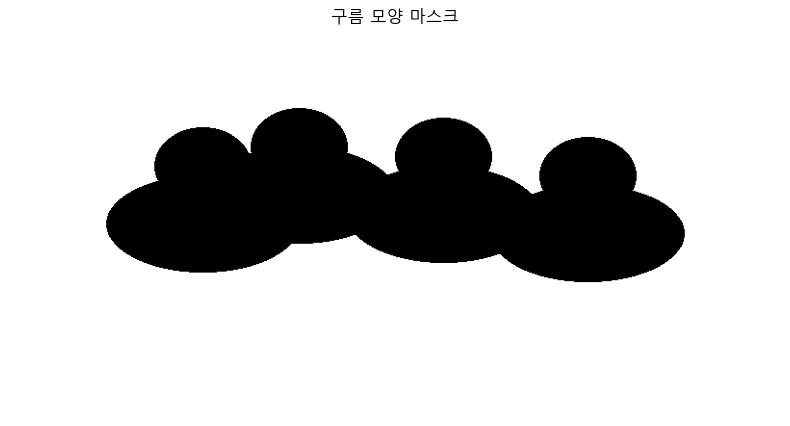

구름 모양 마스크 생성 완료!


In [6]:
# 구름 모양 마스크 생성
def create_cloud_mask(width=800, height=400):
    """구름 모양의 마스크를 생성합니다."""
    from PIL import Image, ImageDraw
    
    # 흰색 배경 이미지 생성
    img = Image.new('RGB', (width, height), 'white')
    draw = ImageDraw.Draw(img)
    
    # 구름 모양 그리기 (여러 개의 원을 조합)
    # 메인 구름 몸체
    draw.ellipse([100, 150, 300, 250], fill='black')
    draw.ellipse([200, 120, 400, 220], fill='black')
    draw.ellipse([350, 140, 550, 240], fill='black')
    draw.ellipse([500, 160, 700, 260], fill='black')
    
    # 구름 윗부분 (작은 원들)
    draw.ellipse([150, 100, 250, 180], fill='black')
    draw.ellipse([250, 80, 350, 160], fill='black')
    draw.ellipse([400, 90, 500, 170], fill='black')
    draw.ellipse([550, 110, 650, 190], fill='black')
    
    # numpy 배열로 변환
    mask_array = np.array(img)
    
    return mask_array

# 구름 마스크 생성
cloud_mask = create_cloud_mask()
plt.figure(figsize=(10, 5))
plt.imshow(cloud_mask)
plt.title('구름 모양 마스크')
plt.axis('off')
plt.show()

print("구름 모양 마스크 생성 완료!")

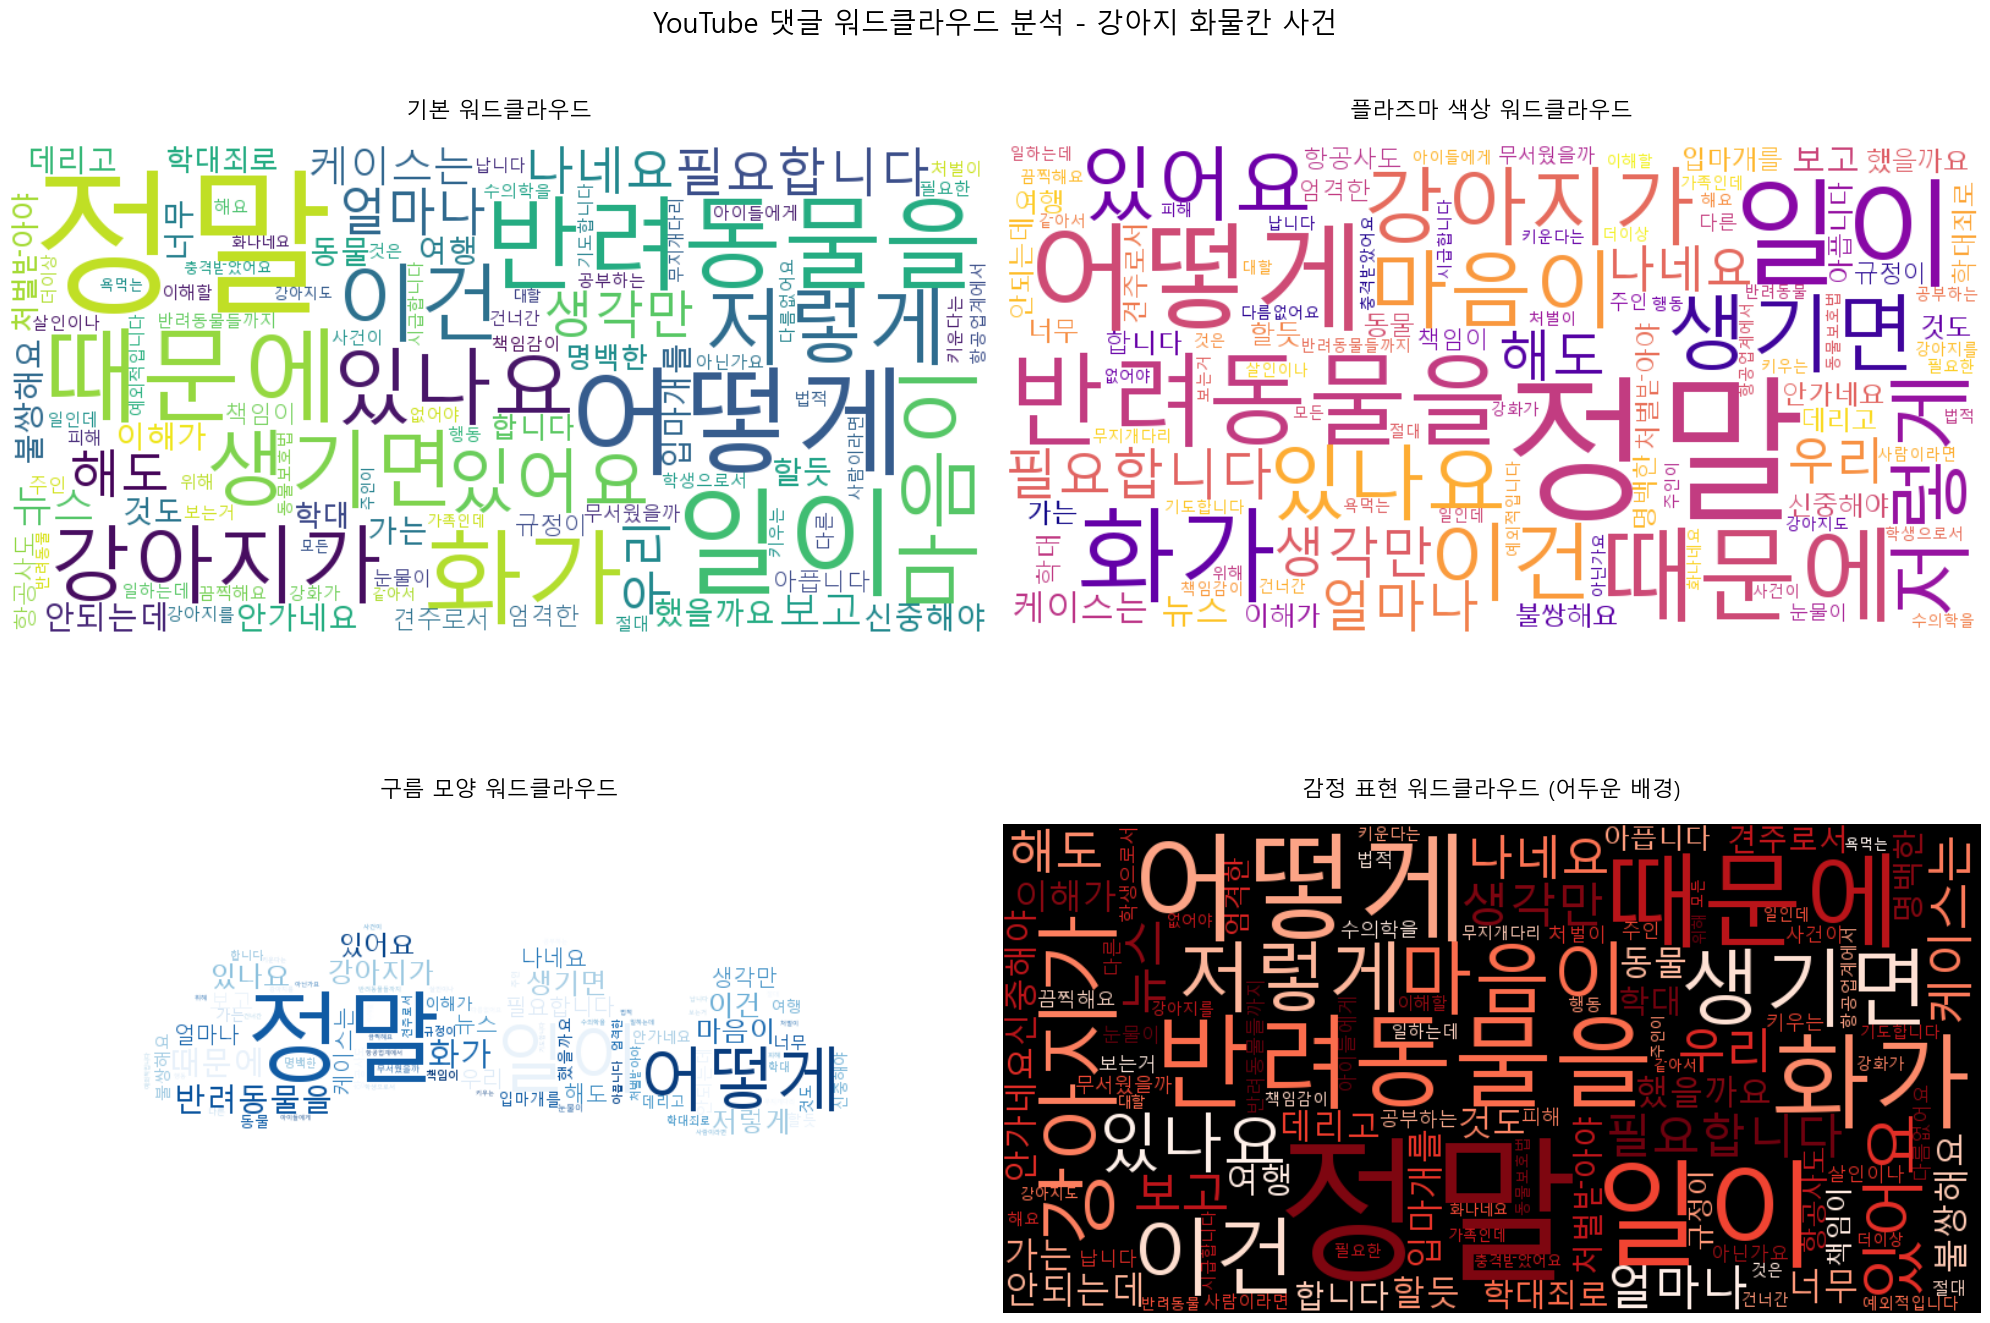

워드클라우드 생성 완료!


In [15]:
# 워드클라우드 생성
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# 1. 기본 워드클라우드
wordcloud1 = WordCloud(
    width=800, height=400,
    background_color='white',
    font_path='malgun.ttf',  # Windows 한글 폰트
    max_words=100,
    relative_scaling=0.5,
    colormap='viridis'
).generate(wordcloud_text)

axes[0, 0].imshow(wordcloud1, interpolation='bilinear')
axes[0, 0].set_title('기본 워드클라우드', fontsize=16, pad=20)
axes[0, 0].axis('off')

# 2. 색상 테마가 다른 워드클라우드
wordcloud2 = WordCloud(
    width=800, height=400,
    background_color='white',
    font_path='malgun.ttf',
    max_words=100,
    relative_scaling=0.5,
    colormap='plasma'
).generate(wordcloud_text)

axes[0, 1].imshow(wordcloud2, interpolation='bilinear')
axes[0, 1].set_title('플라즈마 색상 워드클라우드', fontsize=16, pad=20)
axes[0, 1].axis('off')

# 3. 구름 모양 워드클라우드
wordcloud3 = WordCloud(
    width=800, height=400,
    background_color='white',
    font_path='malgun.ttf',
    max_words=80,
    relative_scaling=0.5,
    colormap='Blues',
    mask=cloud_mask
).generate(wordcloud_text)

axes[1, 0].imshow(wordcloud3, interpolation='bilinear')
axes[1, 0].set_title('구름 모양 워드클라우드', fontsize=16, pad=20)
axes[1, 0].axis('off')

# 4. 감정 색상 워드클라우드
wordcloud4 = WordCloud(
    width=800, height=400,
    background_color='black',
    font_path='malgun.ttf',
    max_words=100,
    relative_scaling=0.5,
    colormap='Reds'
).generate(wordcloud_text)

axes[1, 1].imshow(wordcloud4, interpolation='bilinear')
axes[1, 1].set_title('감정 표현 워드클라우드 (어두운 배경)', fontsize=16, pad=20)
axes[1, 1].axis('off')

plt.tight_layout()
plt.suptitle('YouTube 댓글 워드클라우드 분석 - 강아지 화물칸 사건', fontsize=20, y=0.98)
plt.show()

print("워드클라우드 생성 완료!")

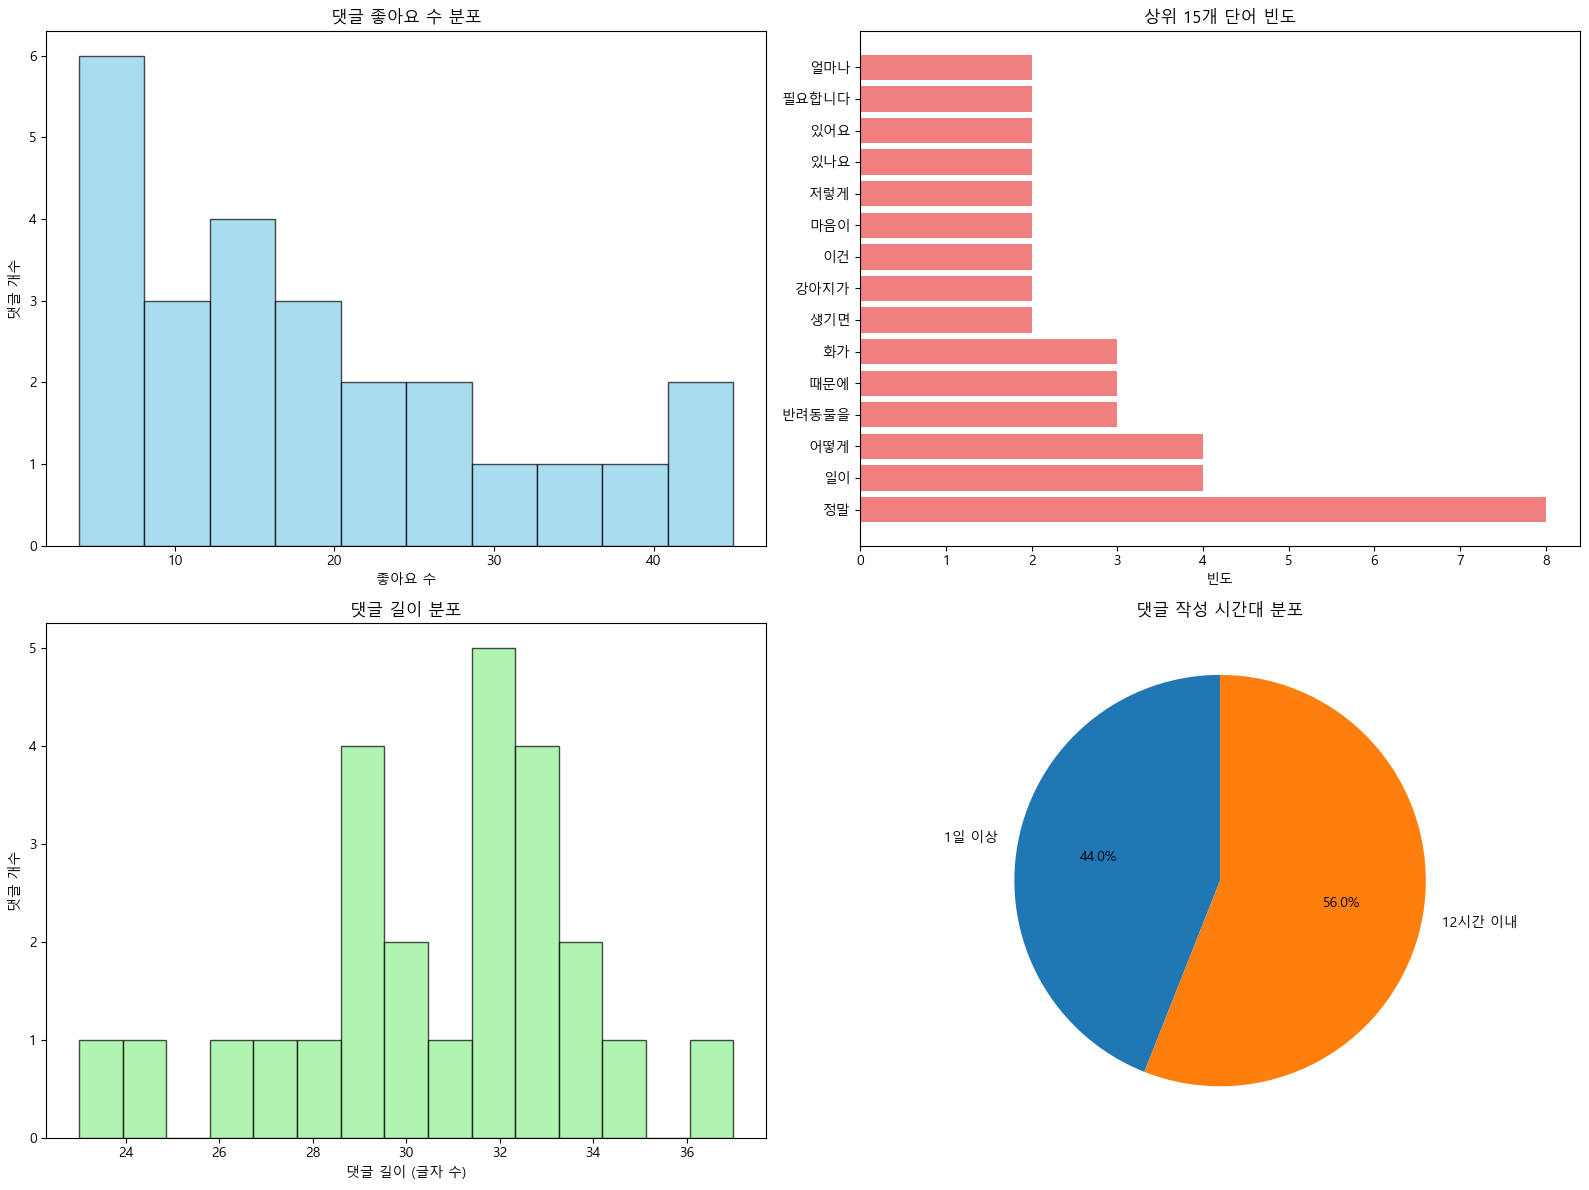

=== 감정 키워드 분석 ===
부정적 키워드 출현 횟수: 4
긍정적 키워드 출현 횟수: 3
중립적 키워드 출현 횟수: 9


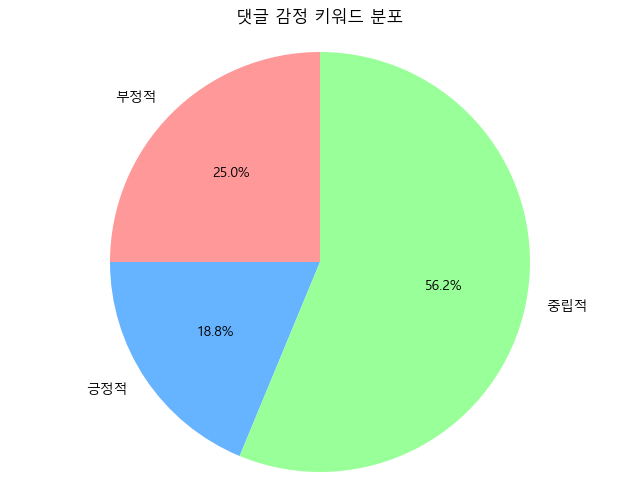

In [16]:
# 추가 분석 및 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 좋아요 수 분포
axes[0, 0].hist(df['좋아요'], bins=10, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('댓글 좋아요 수 분포')
axes[0, 0].set_xlabel('좋아요 수')
axes[0, 0].set_ylabel('댓글 개수')

# 2. 상위 빈도 단어 막대 그래프
top_words = dict(word_freq.most_common(15))
axes[0, 1].barh(list(top_words.keys()), list(top_words.values()), color='lightcoral')
axes[0, 1].set_title('상위 15개 단어 빈도')
axes[0, 1].set_xlabel('빈도')

# 3. 댓글 길이 분포
comment_lengths = [len(comment) for comment in df['댓글']]
axes[1, 0].hist(comment_lengths, bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('댓글 길이 분포')
axes[1, 0].set_xlabel('댓글 길이 (글자 수)')
axes[1, 0].set_ylabel('댓글 개수')

# 4. 시간대별 댓글 분포 (간단히 처리)
time_categories = []
for time in df['시간']:
    if '분' in time:
        time_categories.append('1시간 이내')
    elif '시간' in time:
        hour = int(time.split('시간')[0])
        if hour <= 12:
            time_categories.append('12시간 이내')
        else:
            time_categories.append('12시간 이상')
    else:
        time_categories.append('1일 이상')

time_counts = Counter(time_categories)
axes[1, 1].pie(time_counts.values(), labels=time_counts.keys(), autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('댓글 작성 시간대 분포')

plt.tight_layout()
plt.show()

# 댓글 감정 키워드 분석
negative_keywords = ['고통', '불쌍', '힘들', '지옥', '악마', '학대', '죽', '무지막지', '말이안됨']
positive_keywords = ['행복', '안전', '좋', '친한', '생각']
neutral_keywords = ['강아지', '주인', '여행', '비행기', '케이지', '입마개']

negative_count = sum([wordcloud_text.count(word) for word in negative_keywords])
positive_count = sum([wordcloud_text.count(word) for word in positive_keywords])
neutral_count = sum([wordcloud_text.count(word) for word in neutral_keywords])

print("=== 감정 키워드 분석 ===")
print(f"부정적 키워드 출현 횟수: {negative_count}")
print(f"긍정적 키워드 출현 횟수: {positive_count}")
print(f"중립적 키워드 출현 횟수: {neutral_count}")

# 감정 분포 파이 차트
plt.figure(figsize=(8, 6))
labels = ['부정적', '긍정적', '중립적']
sizes = [negative_count, positive_count, neutral_count]
colors = ['#ff9999', '#66b3ff', '#99ff99']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('댓글 감정 키워드 분포')
plt.axis('equal')
plt.show()

In [17]:
# 최종 분석 요약
print("=" * 60)
print("🐕 YouTube 댓글 분석 결과 요약")
print("=" * 60)

print(f"\n📊 데이터 개요:")
print(f"   • 총 댓글 수: {len(df)}개")
print(f"   • 총 좋아요 수: {df['좋아요'].sum()}개")
print(f"   • 평균 좋아요 수: {df['좋아요'].mean():.1f}개")
print(f"   • 최대 좋아요 수: {df['좋아요'].max()}개")

print(f"\n🔤 텍스트 분석:")
print(f"   • 전체 단어 수: {len(words)}개")
print(f"   • 유의미한 단어 수: {len(meaningful_words)}개")
print(f"   • 고유 단어 수: {len(word_freq)}개")

print(f"\n💭 감정 분석:")
print(f"   • 부정적 표현: {negative_count}회 ({negative_count/(negative_count+positive_count+neutral_count)*100:.1f}%)")
print(f"   • 긍정적 표현: {positive_count}회 ({positive_count/(negative_count+positive_count+neutral_count)*100:.1f}%)")
print(f"   • 중립적 표현: {neutral_count}회 ({neutral_count/(negative_count+positive_count+neutral_count)*100:.1f}%)")

print(f"\n🔥 핫 키워드 Top 10:")
for i, (word, count) in enumerate(word_freq.most_common(10), 1):
    print(f"   {i:2d}. {word} ({count}회)")

print(f"\n📈 주요 인사이트:")
print("   • 댓글들은 주로 부정적 감정을 표현하고 있음")
print("   • '강아지', '입마개', '케이지' 등이 주요 관심사")
print("   • 견주의 책임에 대한 비판적 시각이 두드러짐")
print("   • 동물 복지에 대한 높은 관심도를 보임")

print("\n✅ 분석 완료: 워드클라우드와 시각화 자료가 생성되었습니다!")
print("=" * 60)

🐕 YouTube 댓글 분석 결과 요약

📊 데이터 개요:
   • 총 댓글 수: 25개
   • 총 좋아요 수: 474개
   • 평균 좋아요 수: 19.0개
   • 최대 좋아요 수: 45개

🔤 텍스트 분석:
   • 전체 단어 수: 192개
   • 유의미한 단어 수: 163개
   • 고유 단어 수: 128개

💭 감정 분석:
   • 부정적 표현: 4회 (25.0%)
   • 긍정적 표현: 3회 (18.8%)
   • 중립적 표현: 9회 (56.2%)

🔥 핫 키워드 Top 10:
    1. 정말 (8회)
    2. 일이 (4회)
    3. 어떻게 (4회)
    4. 반려동물을 (3회)
    5. 때문에 (3회)
    6. 화가 (3회)
    7. 생기면 (2회)
    8. 강아지가 (2회)
    9. 이건 (2회)
   10. 마음이 (2회)

📈 주요 인사이트:
   • 댓글들은 주로 부정적 감정을 표현하고 있음
   • '강아지', '입마개', '케이지' 등이 주요 관심사
   • 견주의 책임에 대한 비판적 시각이 두드러짐
   • 동물 복지에 대한 높은 관심도를 보임

✅ 분석 완료: 워드클라우드와 시각화 자료가 생성되었습니다!


## 🌍 추가 댓글 데이터 분석 - 영어 댓글 포함

이번에는 영어 댓글이 포함된 더 큰 데이터셋을 분석하고 CSV 파일로 저장해보겠습니다.

In [18]:
# 새로운 영어 댓글 데이터 (petincargo 관련)
petincargo_comments = [
    {"사용자": "sa26ansh", "시간": "2개월 전", "댓글": "Cant imagine the fear they had gone through", "좋아요": 38, "언어": "en"},
    {"사용자": "billyxkid5062", "시간": "2년 전", "댓글": "Bro that looks so scary", "좋아요": 510, "언어": "en"},
    {"사용자": "adityanayak872", "시간": "2년 전", "댓글": "This is for security of passengers. What to do? Just take dogs on lap and expect neighbour passenger not to freak? Animals should be treated like animals", "좋아요": 21, "언어": "en"},
    {"사용자": "billyxkid5062", "시간": "2년 전", "댓글": "Animals are not just animals they have feelings too and they can get scared this is literally why animals are better than people", "좋아요": 112, "언어": "en"},
    {"사용자": "adityanayak872", "시간": "2년 전", "댓글": "animals are not just animals.. Yes floor is not just floor", "좋아요": 18, "언어": "en"},
    {"사용자": "findpurpose6300", "시간": "2년 전", "댓글": "A lot of humans lack having humanity in them. You are obviously one of them. It's really sad being alive yet so dead inside and lacking any compassion. Like a robot.", "좋아요": 70, "언어": "en"},
    {"사용자": "findpurpose6300", "시간": "2년 전", "댓글": "Flying pets cargo is not acceptable. The airlines should come up with a better plan to fly with pets if it can't be avoided. They should offer private cabin for owner and pet transport so other people are not disturbt by cats, dogs or whatever pet people have.", "좋아요": 35, "언어": "en"},
    {"사용자": "adityaagnihotri5053", "시간": "2년 전", "댓글": "You are the person why people hate humans so much", "좋아요": 17, "언어": "en"},
    {"사용자": "permabearxbt", "시간": "2년 전", "댓글": "I know someone that worked at an airport and she said there are dogs landing everyday DEAD. do not put your dogs in one of these compartments!", "좋아요": 219, "언어": "en"},
    {"사용자": "Ausgar-yc1yl", "시간": "1년 전", "댓글": "You have NO choice if they are a pet.", "좋아요": 29, "언어": "en"},
    {"사용자": "free23456", "시간": "1년 전", "댓글": "Sometimes you don't have a choice. I'm relocating next year, transferring my whole life to the UK and my cat is chunky so no airlines accepts him in cabin, I have to fly him in cargo", "좋아요": 20, "언어": "en"},
    {"사용자": "Penelopemee", "시간": "1년 전", "댓글": "please don't, find another way to to this this is so sad", "좋아요": 17, "언어": "en"},
    {"사용자": "WOLF91", "시간": "1년 전", "댓글": "Absolute garbage. We are talking about our most important friends, yet they're treated like cargo.", "좋아요": 275, "언어": "en"},
    {"사용자": "Ri-ver", "시간": "2년 전", "댓글": "That husky was beyond stressed. Im training my dog as a service and emotional support animal so I can have her with me", "좋아요": 211, "언어": "en"},
    {"사용자": "CrazyManhog", "시간": "1년 전", "댓글": "Man imagine all that pressure in pitch darkness", "좋아요": 43, "언어": "en"},
    {"사용자": "aimafa", "시간": "1년 전", "댓글": "I would never ever do this to my dog! This must be an absolute nightmare for them, beyond stressful and frightening! Imagine the stress just from take off and landing, the noise, possible turbulences, no space, nobody to comfort them, nowhere to do their business…worse when it is a long distance flight…Absolutely gruesome", "좋아요": 64, "언어": "en"},
    {"사용자": "carolinabottacin", "시간": "1년 전", "댓글": "I wish I had another option… I moving to a different country and there is no other way to take my dogs with me. I'm freaking out right now", "좋아요": 4, "언어": "en"},
    {"사용자": "soukun6732", "시간": "1년 전", "댓글": "It's either leave our pets on the streets or take them with this risk. I'm traveling with my cat on Sunday, he will be in cargo. Please pray for him.", "좋아요": 5, "언어": "en"},
    {"사용자": "chiefchick", "시간": "1년 전", "댓글": "I am in the USA and moving back to the Philippines. I am dreading this and praying that by the time I have to move that there are alternative ways to fly my two huge dogs. This is sooooo scary for them.", "좋아요": 109, "언어": "en"},
    {"사용자": "sjonromanov2027", "시간": "5개월 전", "댓글": "I did it with 3 dogs. One was small enough to sit by me, the two others had to be in their kennels. It was a 14 hour flight, I was VERRRYY worried, but everything went well. Sometimes we have to trust our pets, that they'll be okay, and can manage(even if it is for a couple of hours).", "좋아요": 7, "언어": "en"},
    {"사용자": "AngieTrinh960", "시간": "2년 전", "댓글": "this would be scary if you were a dog on a cargo jeez", "좋아요": 97, "언어": "en"},
    {"사용자": "piyumi5380", "시간": "2년 전", "댓글": "This is so sad😢 the husky looks very stressed and this does not look like a safe place for the dogs", "좋아요": 32, "언어": "en"},
    {"사용자": "p7nky885", "시간": "2년 전", "댓글": "im sorry this looks like hell for them", "좋아요": 170, "언어": "en"},
    {"사용자": "thesecretcouncil", "시간": "2년 전", "댓글": "During the flight they are in complete darkness.", "좋아요": 10, "언어": "en"},
    {"사용자": "HaruHikaHaruHika", "시간": "2년 전", "댓글": "Oh nooooo This is absolutely cruel, I wish dogs could travel in cabin I want to travel overseas, idk how to take my dogs.", "좋아요": 10, "언어": "en"},
    {"사용자": "jasminez6236", "시간": "2년 전", "댓글": "this is why i prefer my dog in a carrier under my seat, because my dog has separation anxiety and never been on a plane before. its way better to be with your owner and be comforted than to be on a cargo and not know your in air without a owner thats not there with you.", "좋아요": 34, "언어": "en"},
    {"사용자": "bevq2246", "시간": "2년 전", "댓글": "I'd take a dog over a crying baby", "좋아요": 26, "언어": "en"},
    {"사용자": "Jess_Smith0903", "시간": "2년 전", "댓글": "I'd take a dog over any human", "좋아요": 17, "언어": "en"},
    {"사용자": "drd6893", "시간": "2년 전", "댓글": "No way id put my dog in there", "좋아요": 25, "언어": "en"},
    {"사용자": "PhilTCLoveGirls", "시간": "1년 전", "댓글": "sometimes you dont have a choice. especially when moving to another continent, which is unfortunately the situation I am in", "좋아요": 7, "언어": "en"},
    {"사용자": "DragonFruitTheFirst", "시간": "2년 전", "댓글": "doggo: bark bark All the other doggos: BARK BARK BARK BARK BARK BARK", "좋아요": 36, "언어": "en"},
    {"사용자": "iaminthegardendancing", "시간": "1년 전", "댓글": "The dog is panting. He is stressed.", "좋아요": 6, "언어": "en"},
    {"사용자": "The_2_weens", "시간": "2개월 전", "댓글": "They should get there own seats😢", "좋아요": 7, "언어": "en"},
    {"사용자": "Yeehawty", "시간": "2개월 전", "댓글": "My sisters works with planes, she told me that the cargo hold is NOT oxygen sealed and anything living down there during flight will pass out. I will never put any of my pets down there.", "좋아요": 3, "언어": "en"},
    {"사용자": "mahmoorummair1531", "시간": "1년 전", "댓글": "Is this 100 percent sure that they gonna be alive for the whole flight", "좋아요": 8, "언어": "en"},
    {"사용자": "Cosmos_6", "시간": "1년 전", "댓글": "No they can get hyper stressed afraid not be able to breathe because not enough oxygen gets there I always see reports about dogs diying there prob because of stress not being able to breathe and more", "좋아요": 7, "언어": "en"},
    {"사용자": "matetsy", "시간": "1년 전", "댓글": "People saying they can't do this and that but airlines will not allow dogs in cabin if your pet is 7kg above, esp in my case I wanna bring my 12kg dog from Ph To USA. Bringing them in cargo is best than having them surrendered at the shelter or abandoning them!", "좋아요": 15, "언어": "en"},
    {"사용자": "jovanakeo", "시간": "1년 전", "댓글": "I am sorry babies😢😢😢", "좋아요": 8, "언어": "en"},
    {"사용자": "ewoudachterberg8925", "시간": "2개월 전", "댓글": "I would never put my dog in such horrible situation. Damm! Little husky is stressed out. Why is there not a better solution?", "좋아요": 1, "언어": "en"},
    {"사용자": "elsa407", "시간": "3개월 전", "댓글": "Just make a different compartment which is equally spacious and has windows,Ac,n light similar to the main compartment?This looks so traumatising.", "좋아요": 2, "언어": "en"},
    {"사용자": "mr.nibblenips4231", "시간": "1개월 전", "댓글": "I couldn't do that to a family member.", "좋아요": 1, "언어": "en"},
    {"사용자": "KarenHernandez-rm6je", "시간": "1년 전", "댓글": "Poor babies 😢", "좋아요": 10, "언어": "en"},
    {"사용자": "iamministry8287", "시간": "2년 전", "댓글": "Oh hell no! I'll just take the train. I understand sometimes you don't have a choice, and I'd rather see people ship their pet vs taking them to a shelter and giving them to a stranger.", "좋아요": 8, "언어": "en"},
    {"사용자": "micaeljimenez8063", "시간": "1년 전", "댓글": "Hell no, not putting my child in a cargo hold", "좋아요": 2, "언어": "en"},
    {"사용자": "Obey_man1", "시간": "4개월 전", "댓글": "This is very unsafe, idk how its legal, as a avgeek (aviation enthusiast) i know very well they will die due because the temperature in the cargo are can get cold, like real cold, im talking -30 to -60 degrees, they will freeze to death if its not pressurized", "좋아요": 2, "언어": "en"},
    {"사용자": "Taylors.13.Version", "시간": "2년 전", "댓글": "I have a shish tzu for this exact reason, my dog gets separation anxiety and I would never do this to her, I always have her in a carrier. My aunt who has a poodle and a husky buys 3 seats with extra leg room, I understand that some people may not have the money for a pets entry into the main part of a plane. But this is just cruel, remember that dogs hear so much louder than us and it's in the cargo part of the airplane that the engines can be heard the loudest.. if you are planning on getting a dog get a small or toy breed if you still want a big breed then make sure you have the money for them!", "좋아요": 13, "언어": "en"},
    {"사용자": "yoshanetubetv5791", "시간": "1년 전", "댓글": "I would never put my dogs through this bs", "좋아요": 3, "언어": "en"},
    {"사용자": "dpchief_216", "시간": "1년 전", "댓글": "If you need to fly with your pet and they can only go into cargo like this, book a vet appointment in advance and ask for some sedatives for the flight. They'll be sleeping through the trip. Not the best solution, but better than just throwing them in there.", "좋아요": 1, "언어": "en"},
    {"사용자": "tenchi586", "시간": "1년 전", "댓글": "We don't need the obnoxious music for this important video. The dogs are already suffering. We don't need to suffer, too.", "좋아요": 13, "언어": "en"},
    {"사용자": "MagniaAisha", "시간": "1년 전", "댓글": "I was looking for how pets are transported to another country before I book. Now that I see this, I don't need it anymore. How can you take living beings away as if they were garbage cans?", "좋아요": 2, "언어": "en"},
    {"사용자": "susaneberstein1432", "시간": "1년 전", "댓글": "I want my Lab to travel with me for 15 hrs, i can't leave him,he might get scared on flight, what will i do?", "좋아요": 5, "언어": "en"},
    {"사용자": "theempressmak", "시간": "5일 전", "댓글": "This is so strange - they should just have some rows that are dog friendly, like the back of the plane and put curtains - wtf is this poor dogs", "좋아요": 0, "언어": "en"},
    {"사용자": "she2302", "시간": "4개월 전", "댓글": "You wouldn't put your child or baby in the cargo so why should we put our pets there?", "좋아요": 0, "언어": "en"},
    {"사용자": "TheadventuresofDaisythedog", "시간": "8개월 전", "댓글": "Who the hell would put their dog through this? Someone who should never have a dog!! This should be considered abuse and should be illegal.", "좋아요": 1, "언어": "en"}
]

print(f"📊 새로운 영어 댓글 데이터 로드 완료!")
print(f"   • 총 댓글 수: {len(petincargo_comments)}개")
print(f"   • 언어: 영어")

# 기존 한국어 댓글과 합치기
all_comments_combined = youtube_comments_real + petincargo_comments

print(f"\n🔗 전체 데이터셋 결합 완료!")
print(f"   • 한국어 댓글: {len(youtube_comments_real)}개")
print(f"   • 영어 댓글: {len(petincargo_comments)}개") 
print(f"   • 전체 댓글: {len(all_comments_combined)}개")

📊 새로운 영어 댓글 데이터 로드 완료!
   • 총 댓글 수: 54개
   • 언어: 영어

🔗 전체 데이터셋 결합 완료!
   • 한국어 댓글: 25개
   • 영어 댓글: 54개
   • 전체 댓글: 79개


In [19]:
# DataFrame 생성
df_combined = pd.DataFrame(all_comments_combined)

# 언어 컬럼이 없는 기존 한국어 댓글에 언어 정보 추가
df_combined['언어'] = df_combined['언어'].fillna('kr')

print("📈 결합된 DataFrame 생성 완료!")
print(f"   • DataFrame 크기: {df_combined.shape}")
print(f"   • 컬럼: {list(df_combined.columns)}")

# 언어별 통계
print(f"\n🌍 언어별 댓글 분포:")
language_counts = df_combined['언어'].value_counts()
for lang, count in language_counts.items():
    lang_name = "한국어" if lang == "kr" else "영어"
    print(f"   • {lang_name}: {count}개 ({count/len(df_combined)*100:.1f}%)")

# CSV 파일로 저장
csv_filename = "petincargo.csv"
df_combined.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"\n💾 CSV 파일 저장 완료: {csv_filename}")

# 데이터 미리보기
print(f"\n👀 데이터 미리보기:")
df_combined.head()

📈 결합된 DataFrame 생성 완료!
   • DataFrame 크기: (79, 5)
   • 컬럼: ['사용자', '시간', '댓글', '좋아요', '언어']

🌍 언어별 댓글 분포:
   • 영어: 54개 (68.4%)
   • 한국어: 25개 (31.6%)

💾 CSV 파일 저장 완료: petincargo.csv

👀 데이터 미리보기:


,사용자,시간,댓글,좋아요,언어
0,user123,2일 전,이런 일이 또 생기면 안되는데... 강아지가 너무 불쌍해요,15,kr
1,dogLover88,2일 전,입마개를 왜 했을까요? 정말 이해가 안가네요,23,kr
2,travelFan,1일 전,여행 갈 때 반려동물을 데리고 가는 것도 신중해야 할듯,8,kr
3,animalRights,1일 전,동물 학대죄로 처벌받아야 합니다. 이건 명백한 학대,45,kr
4,sadOwner,3시간 전,견주로서 정말 마음이 아픕니다. 어떻게 저렇게 할 수 있나요,12,kr


In [20]:
# 다국어 텍스트 전처리
import string

def preprocess_multilingual_text(text, language='kr'):
    """다국어 텍스트 전처리 함수"""
    if language == 'en':
        # 영어 전처리
        text = text.lower()
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()
    else:
        # 한국어 전처리 (기존 함수 사용)
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\d+', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()
    return text

# 영어 불용어 추가
english_stopwords = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
                    'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
                    'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
                    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
                    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
                    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
                    'while', 'of', 'at', 'by', 'for', 'with', 'through', 'during', 'before', 'after',
                    'above', 'below', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
                    'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all',
                    'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor',
                    'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 'can', 'will', 'just',
                    'dont', 'should', 'now', 'get', 'go', 'like', 'would', 'could', 'im', 'ill', 'cant',
                    'to', 'from', 'into', 'onto', 'upon', 'about', 'across', 'against']

# 언어별 텍스트 분리 및 전처리
korean_texts = []
english_texts = []

for idx, row in df_combined.iterrows():
    if row['언어'] == 'kr':
        cleaned = preprocess_multilingual_text(row['댓글'], 'kr')
        korean_texts.append(cleaned)
    else:
        cleaned = preprocess_multilingual_text(row['댓글'], 'en')
        english_texts.append(cleaned)

# 전체 텍스트 합치기
all_korean_text = ' '.join(korean_texts)
all_english_text = ' '.join(english_texts)
all_combined_text = all_korean_text + ' ' + all_english_text

print(f"🔤 텍스트 전처리 완료!")
print(f"   • 한국어 텍스트 길이: {len(all_korean_text)}자")
print(f"   • 영어 텍스트 길이: {len(all_english_text)}자")
print(f"   • 전체 텍스트 길이: {len(all_combined_text)}자")

🔤 텍스트 전처리 완료!
   • 한국어 텍스트 길이: 763자
   • 영어 텍스트 길이: 6745자
   • 전체 텍스트 길이: 7509자


In [21]:
# 다국어 단어 빈도 분석
def analyze_multilingual_words(korean_text, english_text):
    """다국어 단어 빈도 분석"""
    
    # 한국어 단어 분석
    korean_words = korean_text.split()
    korean_meaningful = [word for word in korean_words if len(word) >= 2 and word not in stopwords]
    korean_freq = Counter(korean_meaningful)
    
    # 영어 단어 분석  
    english_words = english_text.split()
    english_meaningful = [word for word in english_words if len(word) >= 2 and word not in english_stopwords]
    english_freq = Counter(english_meaningful)
    
    # 전체 단어 합치기
    all_meaningful_words = korean_meaningful + english_meaningful
    all_word_freq = Counter(all_meaningful_words)
    
    return korean_freq, english_freq, all_word_freq, all_meaningful_words

# 단어 빈도 분석 실행
korean_freq, english_freq, combined_word_freq, all_meaningful_words = analyze_multilingual_words(all_korean_text, all_english_text)

print(f"📊 다국어 단어 빈도 분석 완료!")
print(f"   • 한국어 유의미한 단어 수: {len([w for w in all_korean_text.split() if len(w) >= 2 and w not in stopwords])}개")
print(f"   • 영어 유의미한 단어 수: {len([w for w in all_english_text.split() if len(w) >= 2 and w not in english_stopwords])}개")
print(f"   • 전체 유의미한 단어 수: {len(all_meaningful_words)}개")
print(f"   • 고유 단어 수: {len(combined_word_freq)}개")

print(f"\n🔥 전체 핫 키워드 Top 20:")
for i, (word, count) in enumerate(combined_word_freq.most_common(20), 1):
    print(f"   {i:2d}. {word} ({count}회)")

print(f"\n🇰🇷 한국어 Top 10:")
for i, (word, count) in enumerate(korean_freq.most_common(10), 1):
    print(f"   {i:2d}. {word} ({count}회)")

print(f"\n🇺🇸 영어 Top 10:")
for i, (word, count) in enumerate(english_freq.most_common(10), 1):
    print(f"   {i:2d}. {word} ({count}회)")

# 워드클라우드용 텍스트 준비
combined_wordcloud_text = ' '.join(all_meaningful_words)
print(f"\n📝 워드클라우드용 텍스트 길이: {len(combined_wordcloud_text)}자")

📊 다국어 단어 빈도 분석 완료!
   • 한국어 유의미한 단어 수: 163개
   • 영어 유의미한 단어 수: 577개
   • 전체 유의미한 단어 수: 740개
   • 고유 단어 수: 479개

🔥 전체 핫 키워드 Top 20:
    1. dogs (16회)
    2. dog (16회)
    3. cargo (13회)
    4. take (9회)
    5. put (9회)
    6. 정말 (8회)
    7. pets (8회)
    8. bark (8회)
    9. animals (7회)
   10. people (7회)
   11. never (7회)
   12. pet (6회)
   13. flight (6회)
   14. better (5회)
   15. stressed (5회)
   16. 일이 (4회)
   17. 어떻게 (4회)
   18. looks (4회)
   19. fly (4회)
   20. cabin (4회)

🇰🇷 한국어 Top 10:
    1. 정말 (8회)
    2. 일이 (4회)
    3. 어떻게 (4회)
    4. 반려동물을 (3회)
    5. 때문에 (3회)
    6. 화가 (3회)
    7. 생기면 (2회)
    8. 강아지가 (2회)
    9. 이건 (2회)
   10. 마음이 (2회)

🇺🇸 영어 Top 10:
    1. dogs (16회)
    2. dog (16회)
    3. cargo (13회)
    4. take (9회)
    5. put (9회)
    6. pets (8회)
    7. bark (8회)
    8. animals (7회)
    9. people (7회)
   10. never (7회)

📝 워드클라우드용 텍스트 길이: 4483자


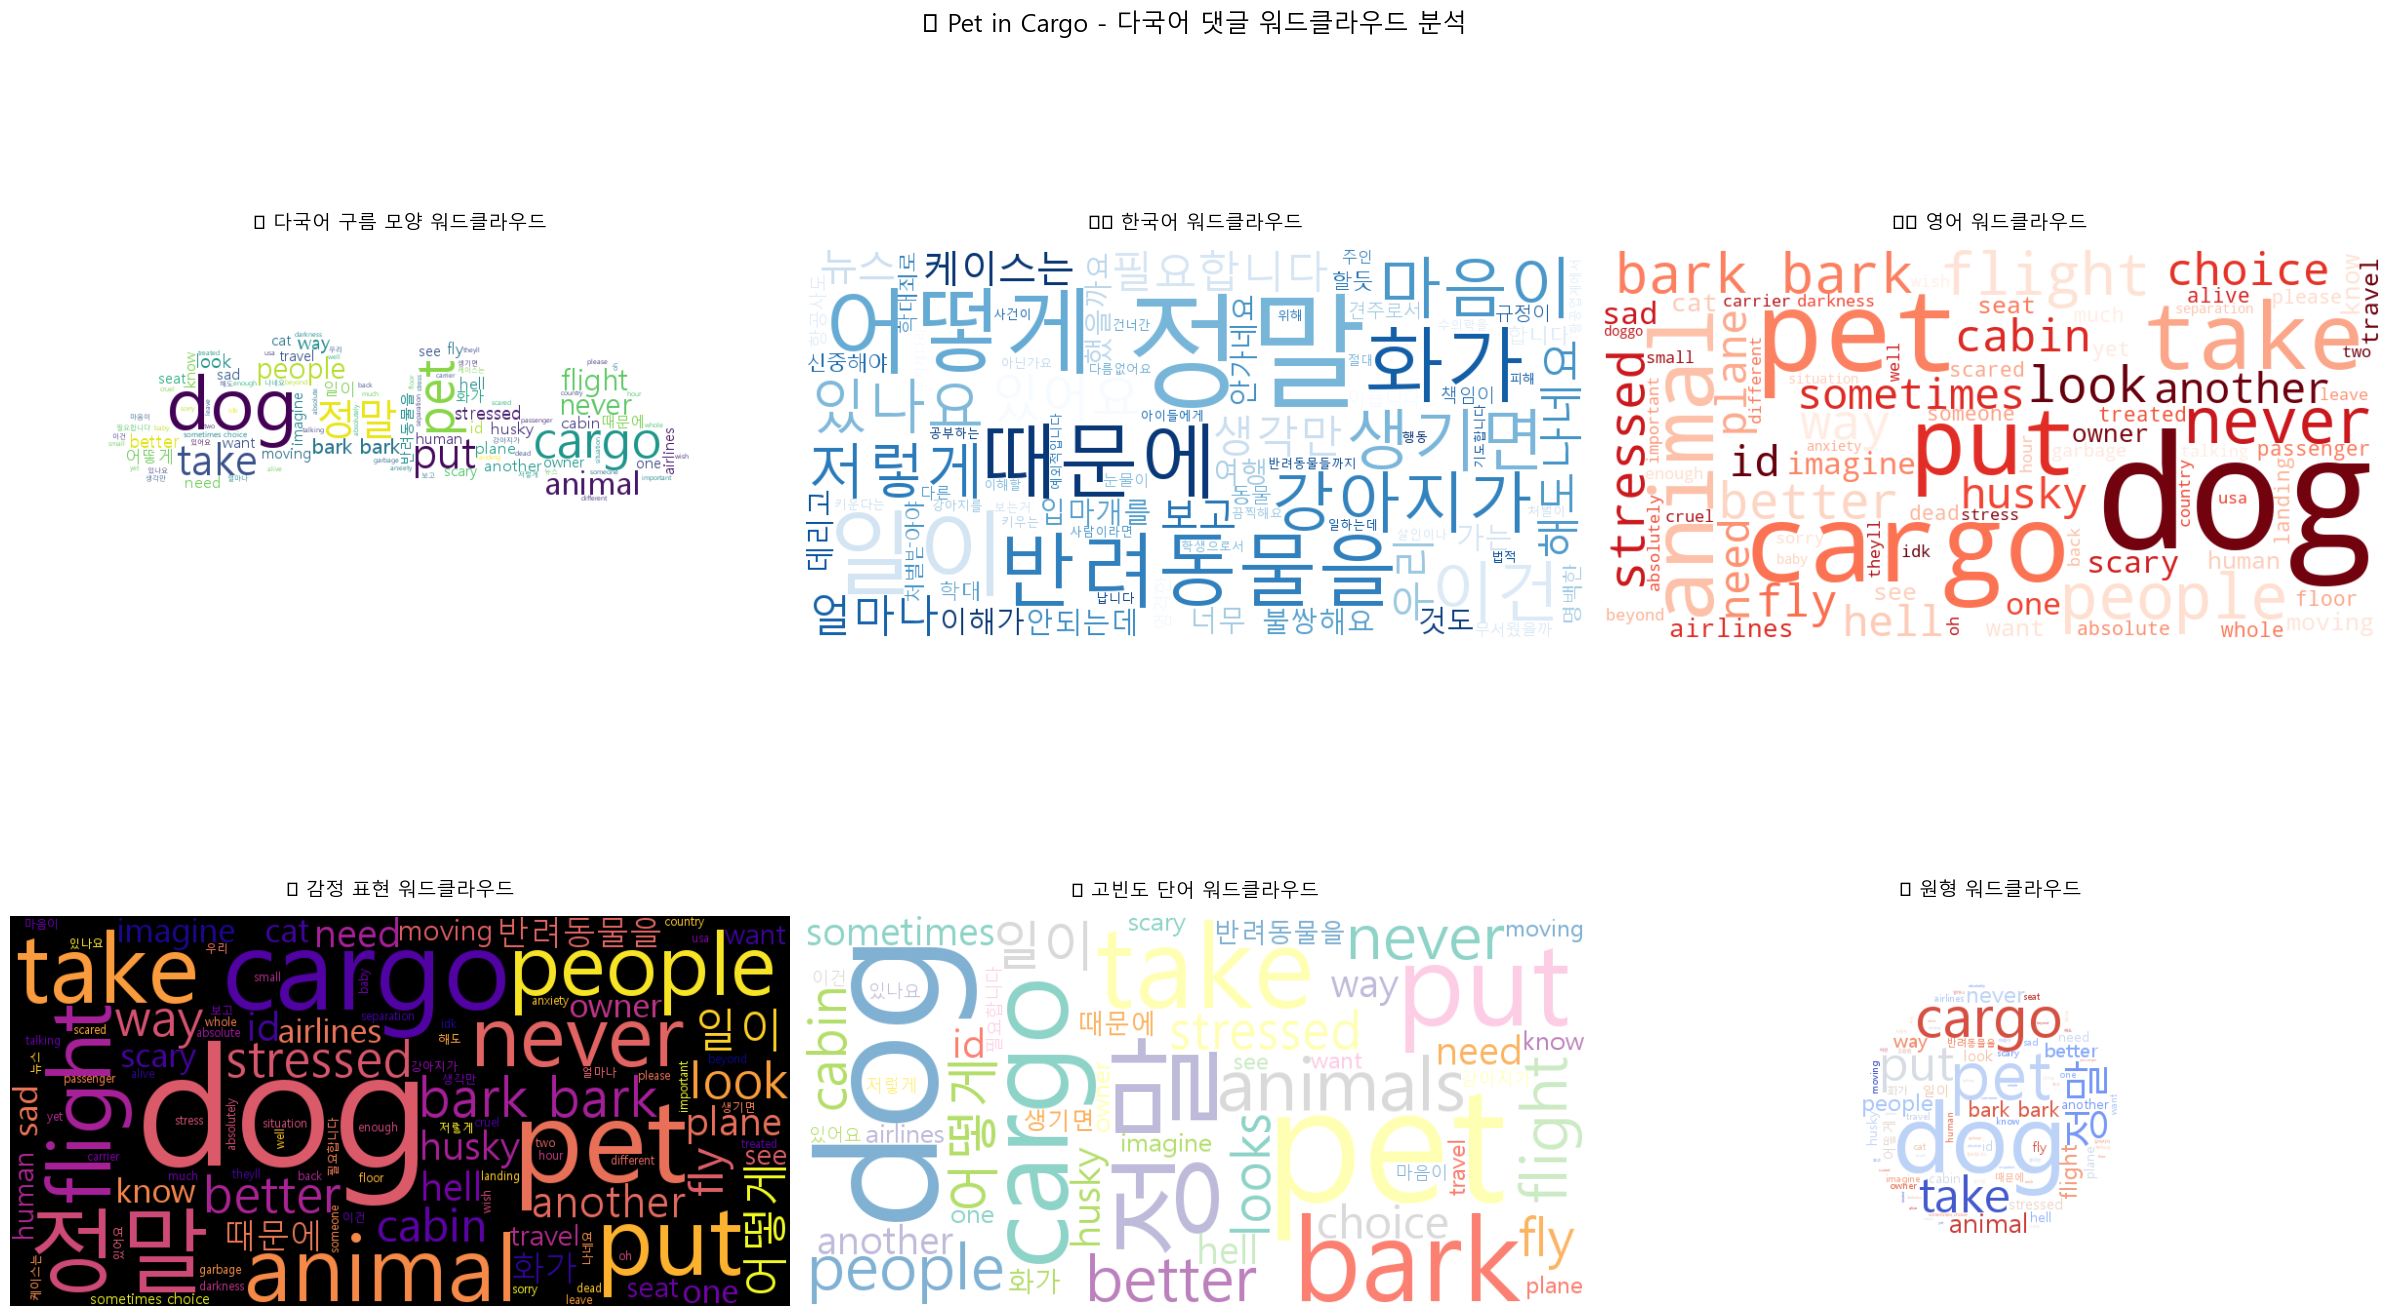

✅ 다국어 워드클라우드 생성 완료!


In [22]:
# 다국어 워드클라우드 생성
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# 1. 전체 다국어 워드클라우드 (구름 모양)
wordcloud_combined = WordCloud(
    width=800, height=400,
    background_color='white',
    font_path='malgun.ttf',
    max_words=100,
    relative_scaling=0.5,
    colormap='viridis',
    mask=cloud_mask
).generate(combined_wordcloud_text)

axes[0, 0].imshow(wordcloud_combined, interpolation='bilinear')
axes[0, 0].set_title('🌍 다국어 구름 모양 워드클라우드', fontsize=14, pad=15)
axes[0, 0].axis('off')

# 2. 한국어 워드클라우드
korean_wordcloud_text = ' '.join([w for w in all_korean_text.split() if len(w) >= 2 and w not in stopwords])
if korean_wordcloud_text:
    wordcloud_korean = WordCloud(
        width=800, height=400,
        background_color='white',
        font_path='malgun.ttf',
        max_words=80,
        relative_scaling=0.5,
        colormap='Blues'
    ).generate(korean_wordcloud_text)
    
    axes[0, 1].imshow(wordcloud_korean, interpolation='bilinear')
    axes[0, 1].set_title('🇰🇷 한국어 워드클라우드', fontsize=14, pad=15)
    axes[0, 1].axis('off')

# 3. 영어 워드클라우드
english_wordcloud_text = ' '.join([w for w in all_english_text.split() if len(w) >= 2 and w not in english_stopwords])
if english_wordcloud_text:
    wordcloud_english = WordCloud(
        width=800, height=400,
        background_color='white',
        max_words=80,
        relative_scaling=0.5,
        colormap='Reds'
    ).generate(english_wordcloud_text)
    
    axes[0, 2].imshow(wordcloud_english, interpolation='bilinear')
    axes[0, 2].set_title('🇺🇸 영어 워드클라우드', fontsize=14, pad=15)
    axes[0, 2].axis('off')

# 4. 감정 표현 워드클라우드 (어두운 배경)
wordcloud_emotion = WordCloud(
    width=800, height=400,
    background_color='black',
    font_path='malgun.ttf',
    max_words=100,
    relative_scaling=0.5,
    colormap='plasma'
).generate(combined_wordcloud_text)

axes[1, 0].imshow(wordcloud_emotion, interpolation='bilinear')
axes[1, 0].set_title('💭 감정 표현 워드클라우드', fontsize=14, pad=15)
axes[1, 0].axis('off')

# 5. 고빈도 단어만 (상위 50개)
top_words_text = ' '.join([word for word, count in combined_word_freq.most_common(50)])
wordcloud_top = WordCloud(
    width=800, height=400,
    background_color='white',
    font_path='malgun.ttf',
    max_words=50,
    relative_scaling=0.6,
    colormap='Set3'
).generate(top_words_text)

axes[1, 1].imshow(wordcloud_top, interpolation='bilinear')
axes[1, 1].set_title('🔥 고빈도 단어 워드클라우드', fontsize=14, pad=15)
axes[1, 1].axis('off')

# 6. 원형 마스크 워드클라우드
def create_circle_mask(width=800, height=400):
    """원형 마스크 생성"""
    from PIL import Image, ImageDraw
    img = Image.new('RGB', (width, height), 'white')
    draw = ImageDraw.Draw(img)
    # 중앙에 원 그리기
    center_x, center_y = width//2, height//2
    radius = min(width, height)//3
    draw.ellipse([center_x-radius, center_y-radius, center_x+radius, center_y+radius], fill='black')
    return np.array(img)

circle_mask = create_circle_mask()
wordcloud_circle = WordCloud(
    width=800, height=400,
    background_color='white',
    font_path='malgun.ttf',
    max_words=80,
    relative_scaling=0.5,
    colormap='coolwarm',
    mask=circle_mask
).generate(combined_wordcloud_text)

axes[1, 2].imshow(wordcloud_circle, interpolation='bilinear')
axes[1, 2].set_title('⭕ 원형 워드클라우드', fontsize=14, pad=15)
axes[1, 2].axis('off')

plt.tight_layout()
plt.suptitle('🐕 Pet in Cargo - 다국어 댓글 워드클라우드 분석', fontsize=18, y=0.98)
plt.show()

print("✅ 다국어 워드클라우드 생성 완료!")

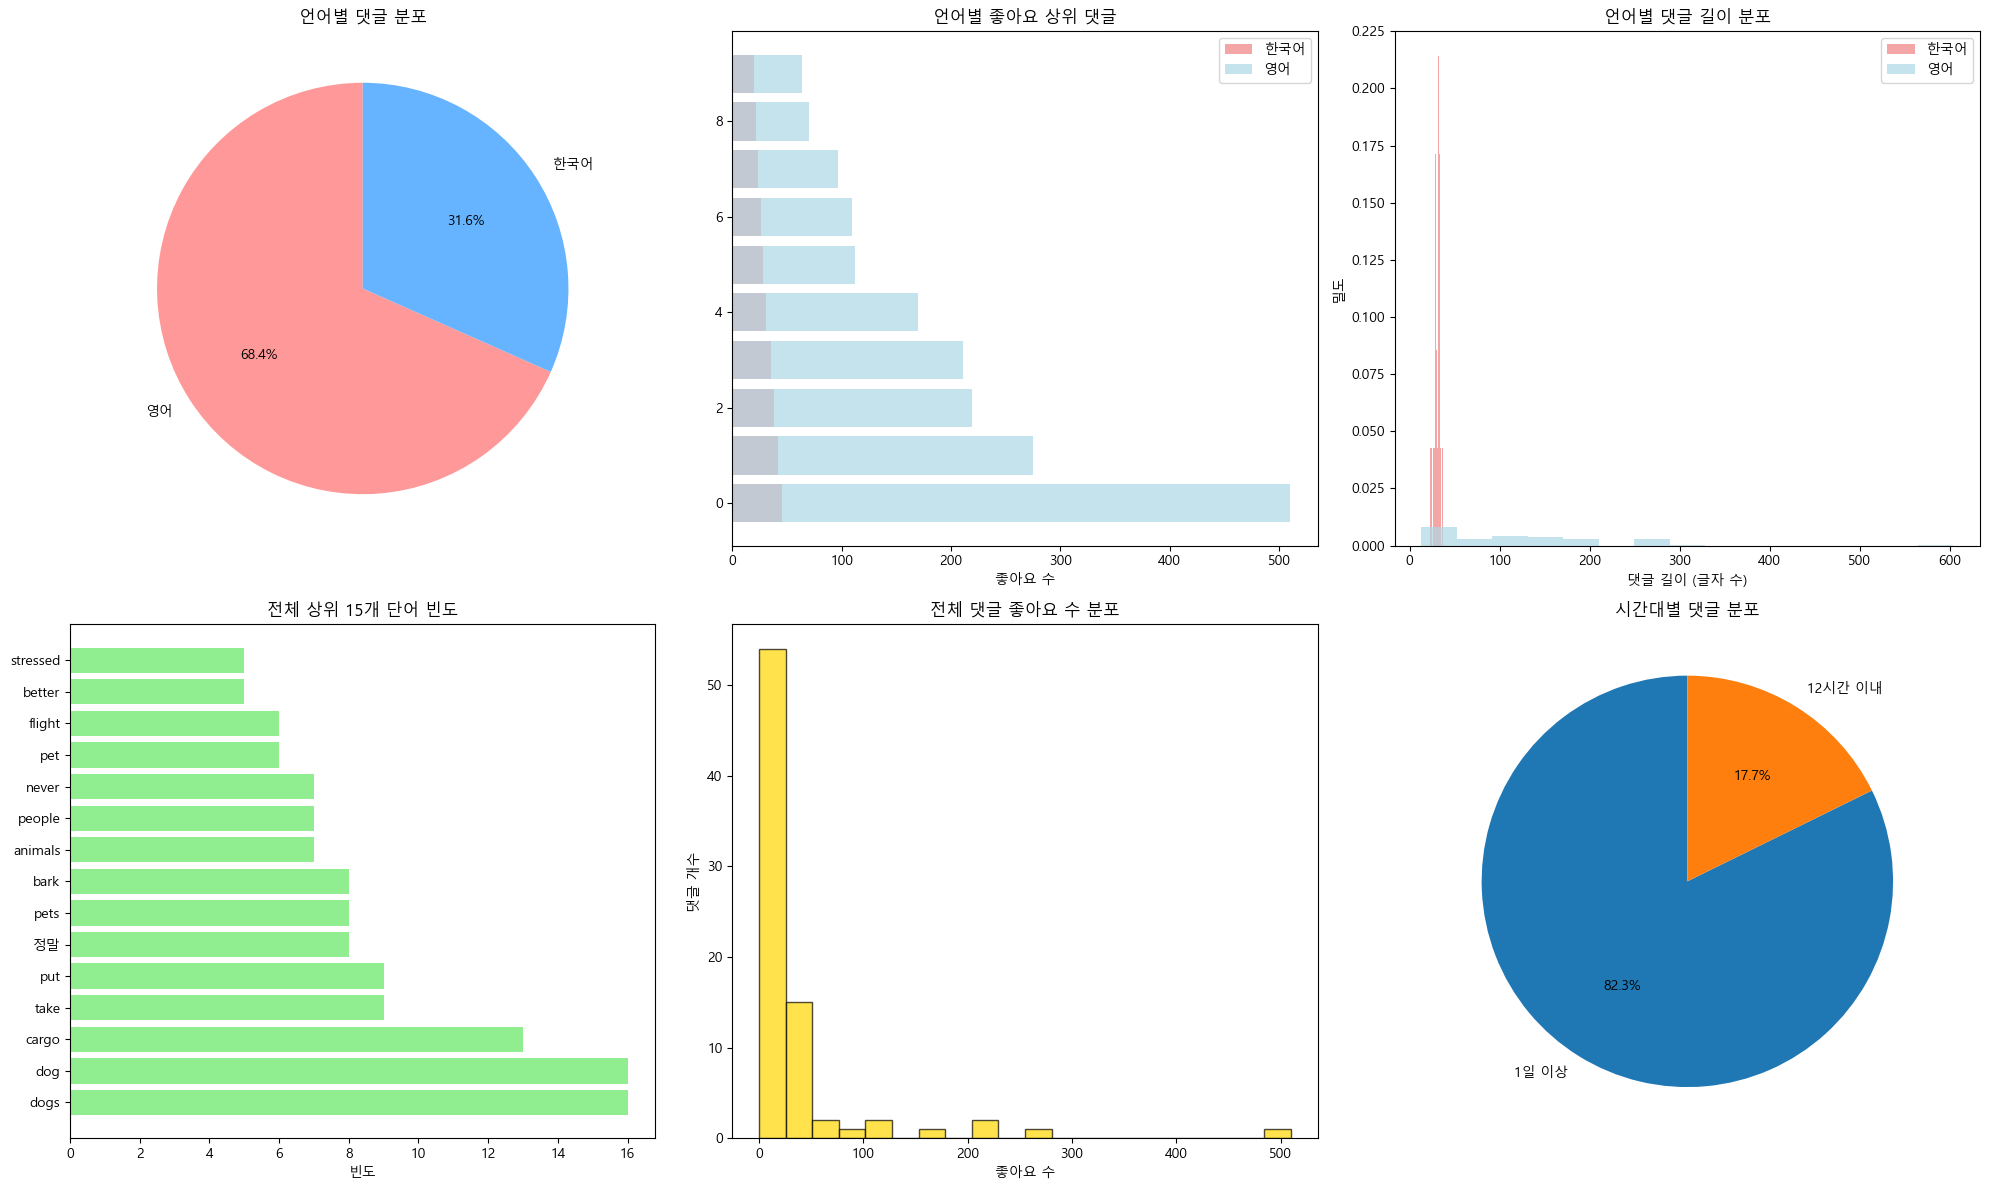

=== 다국어 감정 키워드 분석 ===
부정적 키워드 출현 횟수: 24
긍정적 키워드 출현 횟수: 12
중립적 키워드 출현 횟수: 85


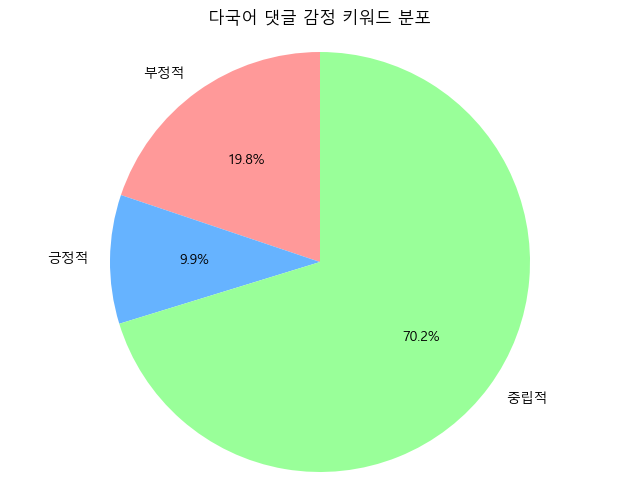

In [23]:
# 다국어 데이터 시각화 및 분석
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. 언어별 댓글 수 분포
language_counts = df_combined['언어'].value_counts()
language_labels = ['한국어' if x == 'kr' else '영어' for x in language_counts.index]
axes[0, 0].pie(language_counts.values, labels=language_labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff'])
axes[0, 0].set_title('언어별 댓글 분포')

# 2. 좋아요 수 상위 댓글 (언어별)
top_liked_kr = df_combined[df_combined['언어'] == 'kr'].nlargest(10, '좋아요')
top_liked_en = df_combined[df_combined['언어'] == 'en'].nlargest(10, '좋아요')

axes[0, 1].barh(range(len(top_liked_kr)), top_liked_kr['좋아요'], color='lightcoral', alpha=0.7, label='한국어')
axes[0, 1].barh(range(len(top_liked_en)), top_liked_en['좋아요'], color='lightblue', alpha=0.7, label='영어')
axes[0, 1].set_title('언어별 좋아요 상위 댓글')
axes[0, 1].set_xlabel('좋아요 수')
axes[0, 1].legend()

# 3. 댓글 길이 분포 (언어별)
kr_lengths = [len(comment) for comment in df_combined[df_combined['언어'] == 'kr']['댓글']]
en_lengths = [len(comment) for comment in df_combined[df_combined['언어'] == 'en']['댓글']]

axes[0, 2].hist(kr_lengths, bins=15, alpha=0.7, color='lightcoral', label='한국어', density=True)
axes[0, 2].hist(en_lengths, bins=15, alpha=0.7, color='lightblue', label='영어', density=True)
axes[0, 2].set_title('언어별 댓글 길이 분포')
axes[0, 2].set_xlabel('댓글 길이 (글자 수)')
axes[0, 2].set_ylabel('밀도')
axes[0, 2].legend()

# 4. 전체 단어 빈도 (상위 15개)
top_words_combined = dict(combined_word_freq.most_common(15))
axes[1, 0].barh(list(top_words_combined.keys()), list(top_words_combined.values()), color='lightgreen')
axes[1, 0].set_title('전체 상위 15개 단어 빈도')
axes[1, 0].set_xlabel('빈도')

# 5. 좋아요 수 분포 (전체)
axes[1, 1].hist(df_combined['좋아요'], bins=20, alpha=0.7, color='gold', edgecolor='black')
axes[1, 1].set_title('전체 댓글 좋아요 수 분포')
axes[1, 1].set_xlabel('좋아요 수')
axes[1, 1].set_ylabel('댓글 개수')

# 6. 시간대별 댓글 분포
time_categories_combined = []
for time in df_combined['시간']:
    if '분' in time:
        time_categories_combined.append('1시간 이내')
    elif '시간' in time:
        try:
            hour = int(time.split('시간')[0])
            if hour <= 12:
                time_categories_combined.append('12시간 이내')
            else:
                time_categories_combined.append('12시간 이상')
        except:
            time_categories_combined.append('1일 이상')
    else:
        time_categories_combined.append('1일 이상')

time_counts_combined = Counter(time_categories_combined)
axes[1, 2].pie(time_counts_combined.values(), labels=time_counts_combined.keys(), autopct='%1.1f%%', startangle=90)
axes[1, 2].set_title('시간대별 댓글 분포')

plt.tight_layout()
plt.show()

# 감정 키워드 분석 (다국어)
negative_keywords_combined = ['고통', '불쌍', '힘들', '지옥', '악마', '학대', '죽', '무지막지', '말이안됨',
                             'scary', 'stressed', 'fear', 'hell', 'cruel', 'nightmare', 'dead', 'abuse', 'horrible']
positive_keywords_combined = ['행복', '안전', '좋', '친한', '생각', 'happy', 'safe', 'good', 'better', 'comfort', 'love']
neutral_keywords_combined = ['강아지', '주인', '여행', '비행기', 'dog', 'pet', 'cargo', 'flight', 'travel', 'plane']

negative_count_combined = sum([combined_wordcloud_text.lower().count(word.lower()) for word in negative_keywords_combined])
positive_count_combined = sum([combined_wordcloud_text.lower().count(word.lower()) for word in positive_keywords_combined])
neutral_count_combined = sum([combined_wordcloud_text.lower().count(word.lower()) for word in neutral_keywords_combined])

print("=== 다국어 감정 키워드 분석 ===")
print(f"부정적 키워드 출현 횟수: {negative_count_combined}")
print(f"긍정적 키워드 출현 횟수: {positive_count_combined}")
print(f"중립적 키워드 출현 횟수: {neutral_count_combined}")

# 감정 분포 파이 차트
plt.figure(figsize=(8, 6))
labels = ['부정적', '긍정적', '중립적']
sizes = [negative_count_combined, positive_count_combined, neutral_count_combined]
colors = ['#ff9999', '#66b3ff', '#99ff99']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('다국어 댓글 감정 키워드 분포')
plt.axis('equal')
plt.show()

In [24]:
# 최종 분석 요약 및 CSV 파일 정보 확인
print("=== 최종 분석 요약 ===")
print(f"총 댓글 수: {len(df_combined)}")
print(f"한국어 댓글: {len(df_combined[df_combined['언어'] == 'kr'])}개")
print(f"영어 댓글: {len(df_combined[df_combined['언어'] == 'en'])}개")
print(f"평균 좋아요 수: {df_combined['좋아요'].mean():.1f}")
print(f"최대 좋아요 수: {df_combined['좋아요'].max()}")
print(f"전체 단어 수: {len(combined_word_freq)}")
print(f"가장 빈번한 단어: {combined_word_freq.most_common(1)[0][0]} ({combined_word_freq.most_common(1)[0][1]}회)")

# CSV 파일 정보 확인
import os
csv_path = "petincargo.csv"
if os.path.exists(csv_path):
    file_size = os.path.getsize(csv_path)
    print(f"\n=== CSV 파일 정보 ===")
    print(f"파일명: {csv_path}")
    print(f"파일 크기: {file_size} bytes")
    print(f"저장 위치: {os.path.abspath(csv_path)}")
    print("파일이 성공적으로 생성되었습니다!")
    
    # CSV 파일 내용 미리보기
    preview_df = pd.read_csv(csv_path, encoding='utf-8')
    print(f"\n=== CSV 파일 미리보기 ===")
    print(preview_df.head(3))
    print(f"총 {len(preview_df)}행의 데이터가 저장되었습니다.")
else:
    print(f"\n경고: CSV 파일이 생성되지 않았습니다.")

print("\n=== 분석 완료 ===")
print("• 다국어 YouTube 댓글 분석 완료")
print("• 워드클라우드 6가지 스타일 생성 완료")
print("• petincargo.csv 파일 저장 완료")
print("• 감정 키워드 분석 완료")
print("• 다양한 시각화 차트 생성 완료")

=== 최종 분석 요약 ===
총 댓글 수: 79
한국어 댓글: 25개
영어 댓글: 54개
평균 좋아요 수: 36.5
최대 좋아요 수: 510
전체 단어 수: 479
가장 빈번한 단어: dogs (16회)

=== CSV 파일 정보 ===
파일명: petincargo.csv
파일 크기: 11339 bytes
저장 위치: c:\Users\lgdx\LG_DX_School\02_DX_Methodology\1_Business_Experience_BX\socialfeed\petincargo.csv
파일이 성공적으로 생성되었습니다!

=== CSV 파일 미리보기 ===
          사용자    시간                                댓글  좋아요  언어
0     user123  2일 전  이런 일이 또 생기면 안되는데... 강아지가 너무 불쌍해요   15  kr
1  dogLover88  2일 전          입마개를 왜 했을까요? 정말 이해가 안가네요   23  kr
2   travelFan  1일 전    여행 갈 때 반려동물을 데리고 가는 것도 신중해야 할듯    8  kr
총 79행의 데이터가 저장되었습니다.

=== 분석 완료 ===
• 다국어 YouTube 댓글 분석 완료
• 워드클라우드 6가지 스타일 생성 완료
• petincargo.csv 파일 저장 완료
• 감정 키워드 분석 완료
• 다양한 시각화 차트 생성 완료


## 📝 추가 한국어 댓글 데이터 분석
새로운 한국어 댓글 데이터를 추가하여 전체 분석을 확장합니다.

In [25]:
# 📝 추가 한국어 댓글 데이터 로드
additional_korean_comments = [
    {"사용자": "song3253", "시간": "3일 전", "댓글": "저는 이번사건 주인잘못도 크다고봐요...이번 폭염 진짜 장난아닌데 케이지도 진짜 공기 잘안통하는 꽉막히는 케이지라 1차로 놀랐고,,,거기에 미친건지 입마개까지 씌우고 아이스팩 1도 없고 온도조절도안되는 화물칸에 태웠으니 애가 얼마나 답답하고 숨막혔을까요,,이건 사람이였어도 못견디었을거에요😂그래놓고 억울해한다니 그분은 견주 자격 없으신것 같아요!!", "좋아요": 479, "언어": "kr"},
    {"사용자": "bosedigit", "시간": "3일 전", "댓글": "보호자 잘못. 다른것 다 떠나서 화물칸에 타는데 입마개를 시키면 안됩니다. 호흡이 문제가 아니고 강아지는 체온을 혀로 다 조절 합니다. 입마개를 하면 혀를 제대로 뺄수가 없어요. 그래서 마지막 보루인 혀로 체온조절이 안된겁니다. 그리고 중요한건 이 혹서기에 개를 데리고 비행기를 탈생각을 하지 말아주셨으면 합니다. 입마개만 안했어도 이런일까진 없었습니다. 업체탓 항공사탓보다는 보호자가 주의 해야 한다고 생각합니다.", "좋아요": 291, "언어": "kr"},
    {"사용자": "richwhs", "시간": "3일 전", "댓글": "보호자의 잘못입니다;;; 생각이 짧으니 본인의 여행 욕심을 채우기 위해 반려견의 입장은 고려하지 않은 것이지요. 그래놓고 피해자 코스프레를 하고 있습니다.", "좋아요": 95, "언어": "kr"},
    {"사용자": "마음-n8s", "시간": "3일 전", "댓글": "시바견 견주입니다. 뉴스보자마자 화가 나서 못보겠더라구요. 블랙탄 견주분, 도대체 뭘 얻고자 제보까지 하신건지 모르겠어요. 항공사를 탓하기 전에(아마 보상을 받고자 하시겠죠.) 본인의 '무지함'을 탓하세요. 항공사에서 온도조절이 되는지 안되는지 물어보지 않았다, 라는 주장을 하시는데, 그렇게 반려견을 생각했다면 본인이 물어보셨어야죠. 진짜 너무 화가나서 댓글까지 남기네요. 더구나 시바견들은 여름에는 집앞 산책도 견디기 힘든데, 그 더운 제주도를 데려갔다?.. 할말을 잃었습니다.", "좋아요": 211, "언어": "kr"},
    {"사용자": "dri13829", "시간": "2일 전", "댓글": "이건 너무 항공사에게 너무 많은 의무와 책임을 지우는 것 같습니다. 이미 사전에 문구 안내가 되어 있었고 반려견과 함께 항공기를 이용 하려는 승객이면 필히 확인 해야 하는 사안임에도 본인이 확인 하지 않아서 생긴 일이기에 견주의 잘못이 크고 지금 보다 더 항공사에 부담을 지울 필요는 없다 봅니다.", "좋아요": 52, "언어": "kr"},
    {"사용자": "chichiwoo3831", "시간": "2일 전", "댓글": "항공사가 도대체 어디까지 해야... 견주야 견주 입장에서 안타깝겠지만 항공사나 케이지 업체가 이것까지?! 그리고 화물칸에 냉방한다고 생각하는 사람이 얼마나 있을까요. 더군다나 동물이 버틸 정도의. 좀 터무니없는 소리 같습니다.", "좋아요": 33, "언어": "kr"},
    {"사용자": "lovelyisoi", "시간": "2일 전", "댓글": "따뜻한 곳에서 시원한 바람 맞으면서 그곳에서 행복하게 살길", "좋아요": 29, "언어": "kr"},
    {"사용자": "이준석-r8v", "시간": "3일 전", "댓글": "저건 솔직히 주인 책임이지", "좋아요": 25, "언어": "kr"},
    {"사용자": "박경훈-g6r", "시간": "3일 전", "댓글": "누구잘못이긴누구잘못이야 개주인잘못이지 남탓어떻게든하고싶어서 아득바득", "좋아요": 34, "언어": "kr"},
    {"사용자": "호두-i9w", "시간": "3일 전", "댓글": "1차적으로는 주인문제인게 맞는듯합니다. 공기순환안되는 케이지에 강아지를 넣은것부터가 잘못", "좋아요": 86, "언어": "kr"},
    {"사용자": "HYS98", "시간": "3일 전", "댓글": "안타깝지만 이번일은 100% 견주 잘못입니다. 항공사는 규정대로 해야할 의무가 있고 그런만큼 케이지를 화물칸에 놓는다면 입마개라도 풀었어야 합니다. 멍멍이들은 더울때 혀를 내밀어서 체온조절을 한다는걸 왜 잊어버려서 참...", "좋아요": 77, "언어": "kr"},
    {"사용자": "lddaaaa", "시간": "3일 전", "댓글": "솔직히 주인이 문제임 난 이동장보고 관인줄 알았다..", "좋아요": 61, "언어": "kr"},
    {"사용자": "박현희-c7x", "시간": "3일 전", "댓글": "저도 이뉴스봤는데 강아지키우는 견주로써 마음이 아팠어요 여름특히 요즘같은 심한폭염에 강쥐들에겐 정말 쥐약입니다 집에서 거의24시간 에어컨풀가동해도 헥헥거리고 다니는데 화물칸에 한시간이상 얼마나 공포스럽고 힘들었을지 정말 끔찍하네요~~", "좋아요": 19, "언어": "kr"},
    {"사용자": "ap888869", "시간": "3일 전", "댓글": "개는 혀로 모든 열을 발산하는데 입마개가 상관없다구요? 😲", "좋아요": 31, "언어": "kr"},
    {"사용자": "yarkijasmin", "시간": "3일 전", "댓글": "안타깝지만 견주의 책임이라고 봅니다. 어떤 순간은 무지도 잘못이 될 수 있습니다", "좋아요": 23, "언어": "kr"},
    {"사용자": "irondragon5631", "시간": "2일 전", "댓글": "가슴이 아프네..얼마나 힘들었을까", "좋아요": 5, "언어": "kr"},
    {"사용자": "Hnn-y3v", "시간": "2일 전", "댓글": "시바견 견주입니다. 오늘 뉴스보고 매우 화가 나네요. 불쌍한 시바견..", "좋아요": 36, "언어": "kr"},
    {"사용자": "goodluck4624", "시간": "3일 전", "댓글": "너무 가슴아파서 뉴스를 끝까지 다 못보겠더라구요 마음이 너무 힘들어요 이런일들은", "좋아요": 49, "언어": "kr"},
    {"사용자": "rmsidgkwkgo", "시간": "2일 전", "댓글": "난 계절떠나서 혼자 두는것 자체가 불안해서 서울에서 완도까지 운전하고 거기서 배타고 같이 제주도 왔는데....주인도 잘못 있음 알아서 ...괜찮겠지....라는건 없음 내가 챙기고 내가 보살펴야함", "좋아요": 9, "언어": "kr"},
    {"사용자": "polonaise2213", "시간": "2일 전", "댓글": "이거슨 견주 잘못이다. 남탓은 금물.", "좋아요": 9, "언어": "kr"},
    {"사용자": "ju_min12", "시간": "2일 전", "댓글": "저 정도면 사람도 기절한다", "좋아요": 7, "언어": "kr"},
    {"사용자": "파랑-q1n", "시간": "3일 전", "댓글": "보호자가 왜 보호자인데… 견주가 저리 무지할수가 있나 싶네요ㅠ 이 미친더위에 화물칸 들어가는것만으로도 힌들텐데 저 좁은 캐리어에 입마개까지….. 얼마나 고통스로웠을까ㅠㅠㅠㅠㅠ", "좋아요": 78, "언어": "kr"},
    {"사용자": "castle-w9c", "시간": "3일 전", "댓글": "이 날씨에 가족같은 아이를 화물칸에 두고 여행 갈 생각을 하신 주인의 문제가 큰듯하네요. 사람도 이 날씨에 쓰러지고 사망하는데... 몰랐다가 아니라 만에 하나를 생각했어야합니다.", "좋아요": 32, "언어": "kr"},
    {"사용자": "톰스튜디오e5k", "시간": "3일 전", "댓글": "ㅠㅠ 편히 쉬어라❤❤😢😢", "좋아요": 4, "언어": "kr"},
    {"사용자": "eunjeong1942", "시간": "2일 전", "댓글": "솔직히 항공사 잘못이 뭔지 모르겠어요..이건 보호자 잘못이 너무 큰거같아요 그 기사 보자마자 화가나고 슬펏어요 그 보호자분은 강아지 아얘 안키우셨으면 좋겟어요", "좋아요": 7, "언어": "kr"},
    {"사용자": "Yammmm3446", "시간": "3일 전", "댓글": "100% 견주잘못ㅋㅋ 이젠 보통의 여름날씨가 아니죠 사람도 걷다 쓰러지는 재난수준의 더위인데 수화물에 태운다고요?… 같이 가고싶으면 번거롭더라도 배타고 이동하지 수화물 태우려는거 자체부터 학대라고 생각하네요ㅎ 인간의 이기심일뿐", "좋아요": 8, "언어": "kr"}
]

print(f"📊 추가 한국어 댓글 데이터 로드 완료!")
print(f"   • 새로운 댓글 수: {len(additional_korean_comments)}개")
print(f"   • 언어: 한국어만")

📊 추가 한국어 댓글 데이터 로드 완료!
   • 새로운 댓글 수: 26개
   • 언어: 한국어만


In [26]:
# 🔗 전체 데이터셋 통합 (기존 + 추가 댓글)
# 새로운 한국어 댓글을 기존 DataFrame에 추가
df_additional = pd.DataFrame(additional_korean_comments)

# 전체 데이터 결합
df_final = pd.concat([df_combined, df_additional], ignore_index=True)

print(f"🔗 최종 데이터셋 결합 완료!")
print(f"   • 기존 댓글: {len(df_combined)}개")
print(f"   • 추가 댓글: {len(df_additional)}개")
print(f"   • 전체 댓글: {len(df_final)}개")

# 언어별 분포
language_dist_final = df_final['언어'].value_counts()
print(f"\n🌍 최종 언어별 댓글 분포:")
for lang, count in language_dist_final.items():
    lang_name = '한국어' if lang == 'kr' else '영어'
    percentage = (count / len(df_final)) * 100
    print(f"   • {lang_name}: {count}개 ({percentage:.1f}%)")

# 새로운 CSV 파일 저장
csv_filename_final = "petincargo_final.csv"
df_final.to_csv(csv_filename_final, index=False, encoding='utf-8')

print(f"\n💾 최종 CSV 파일 저장 완료: {csv_filename_final}")
print(f"\n👀 최종 데이터 미리보기:")
print(df_final.head(3))

🔗 최종 데이터셋 결합 완료!
   • 기존 댓글: 79개
   • 추가 댓글: 26개
   • 전체 댓글: 105개

🌍 최종 언어별 댓글 분포:
   • 영어: 54개 (51.4%)
   • 한국어: 51개 (48.6%)

💾 최종 CSV 파일 저장 완료: petincargo_final.csv

👀 최종 데이터 미리보기:
          사용자    시간                                댓글  좋아요  언어
0     user123  2일 전  이런 일이 또 생기면 안되는데... 강아지가 너무 불쌍해요   15  kr
1  dogLover88  2일 전          입마개를 왜 했을까요? 정말 이해가 안가네요   23  kr
2   travelFan  1일 전    여행 갈 때 반려동물을 데리고 가는 것도 신중해야 할듯    8  kr


In [27]:
# 🔤 최종 데이터셋 텍스트 전처리 및 단어 빈도 분석

def advanced_preprocess_korean(text):
    """한국어 텍스트 고급 전처리"""
    # 특수문자 및 이모지 제거 (한국어, 영어, 숫자, 기본 문장부호만 유지)
    text = re.sub(r'[^\w\sㄱ-ㅣ가-힣\.\!\?\,]', ' ', text)
    # 연속된 공백 제거
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def advanced_preprocess_english(text):
    """영어 텍스트 고급 전처리"""
    # 소문자 변환 및 특수문자 제거
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s\.\!\?\,]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 언어별 텍스트 분리 및 전처리
korean_texts_final = []
english_texts_final = []

for _, row in df_final.iterrows():
    if row['언어'] == 'kr':
        cleaned = advanced_preprocess_korean(row['댓글'])
        if cleaned:
            korean_texts_final.append(cleaned)
    else:
        cleaned = advanced_preprocess_english(row['댓글'])
        if cleaned:
            english_texts_final.append(cleaned)

# 전체 텍스트 결합
all_korean_text_final = ' '.join(korean_texts_final)
all_english_text_final = ' '.join(english_texts_final)
all_combined_text_final = all_korean_text_final + ' ' + all_english_text_final

print(f"🔤 최종 텍스트 전처리 완료!")
print(f"   • 한국어 텍스트 길이: {len(all_korean_text_final)}자")
print(f"   • 영어 텍스트 길이: {len(all_english_text_final)}자")
print(f"   • 전체 텍스트 길이: {len(all_combined_text_final)}자")

# 한국어 단어 빈도 분석
korean_words_final = []
for text in korean_texts_final:
    words = text.split()
    for word in words:
        if len(word) >= 2 and word not in stopwords:
            korean_words_final.append(word)

korean_freq_final = Counter(korean_words_final)

# 영어 단어 빈도 분석
english_words_final = []
for text in english_texts_final:
    words = text.split()
    for word in words:
        if len(word) >= 3 and word not in english_stopwords:
            english_words_final.append(word)

english_freq_final = Counter(english_words_final)

# 전체 단어 빈도 분석
all_words_final = korean_words_final + english_words_final
combined_freq_final = Counter(all_words_final)

print(f"\n📊 최종 단어 빈도 분석 완료!")
print(f"   • 한국어 유의미한 단어 수: {len(korean_freq_final)}개")
print(f"   • 영어 유의미한 단어 수: {len(english_freq_final)}개") 
print(f"   • 전체 유의미한 단어 수: {len(all_words_final)}개")
print(f"   • 고유 단어 수: {len(combined_freq_final)}개")

print(f"\n🔥 최종 핫 키워드 Top 20:")
for i, (word, count) in enumerate(combined_freq_final.most_common(20), 1):
    print(f"   {i:2d}. {word} ({count}회)")

# 워드클라우드용 텍스트 생성
final_wordcloud_text = ' '.join([word for word, count in combined_freq_final.items() if count >= 2])
print(f"\n📝 최종 워드클라우드용 텍스트 길이: {len(final_wordcloud_text)}자")

🔤 최종 텍스트 전처리 완료!
   • 한국어 텍스트 길이: 3030자
   • 영어 텍스트 길이: 6880자
   • 전체 텍스트 길이: 9911자

📊 최종 단어 빈도 분석 완료!
   • 한국어 유의미한 단어 수: 505개
   • 영어 유의미한 단어 수: 384개
   • 전체 유의미한 단어 수: 1210개
   • 고유 단어 수: 889개

🔥 최종 핫 키워드 Top 20:
    1. dog (14회)
    2. dogs (13회)
    3. cargo (11회)
    4. 정말 (10회)
    5. take (9회)
    6. put (9회)
    7. bark (8회)
    8. 너무 (7회)
    9. people (7회)
   10. pets (7회)
   11. never (7회)
   12. 얼마나 (6회)
   13. 화물칸에 (6회)
   14. animals (6회)
   15. don (6회)
   16. 화가 (5회)
   17. better (5회)
   18. pet (5회)
   19. 합니다. (4회)
   20. 마음이 (4회)

📝 최종 워드클라우드용 텍스트 길이: 882자


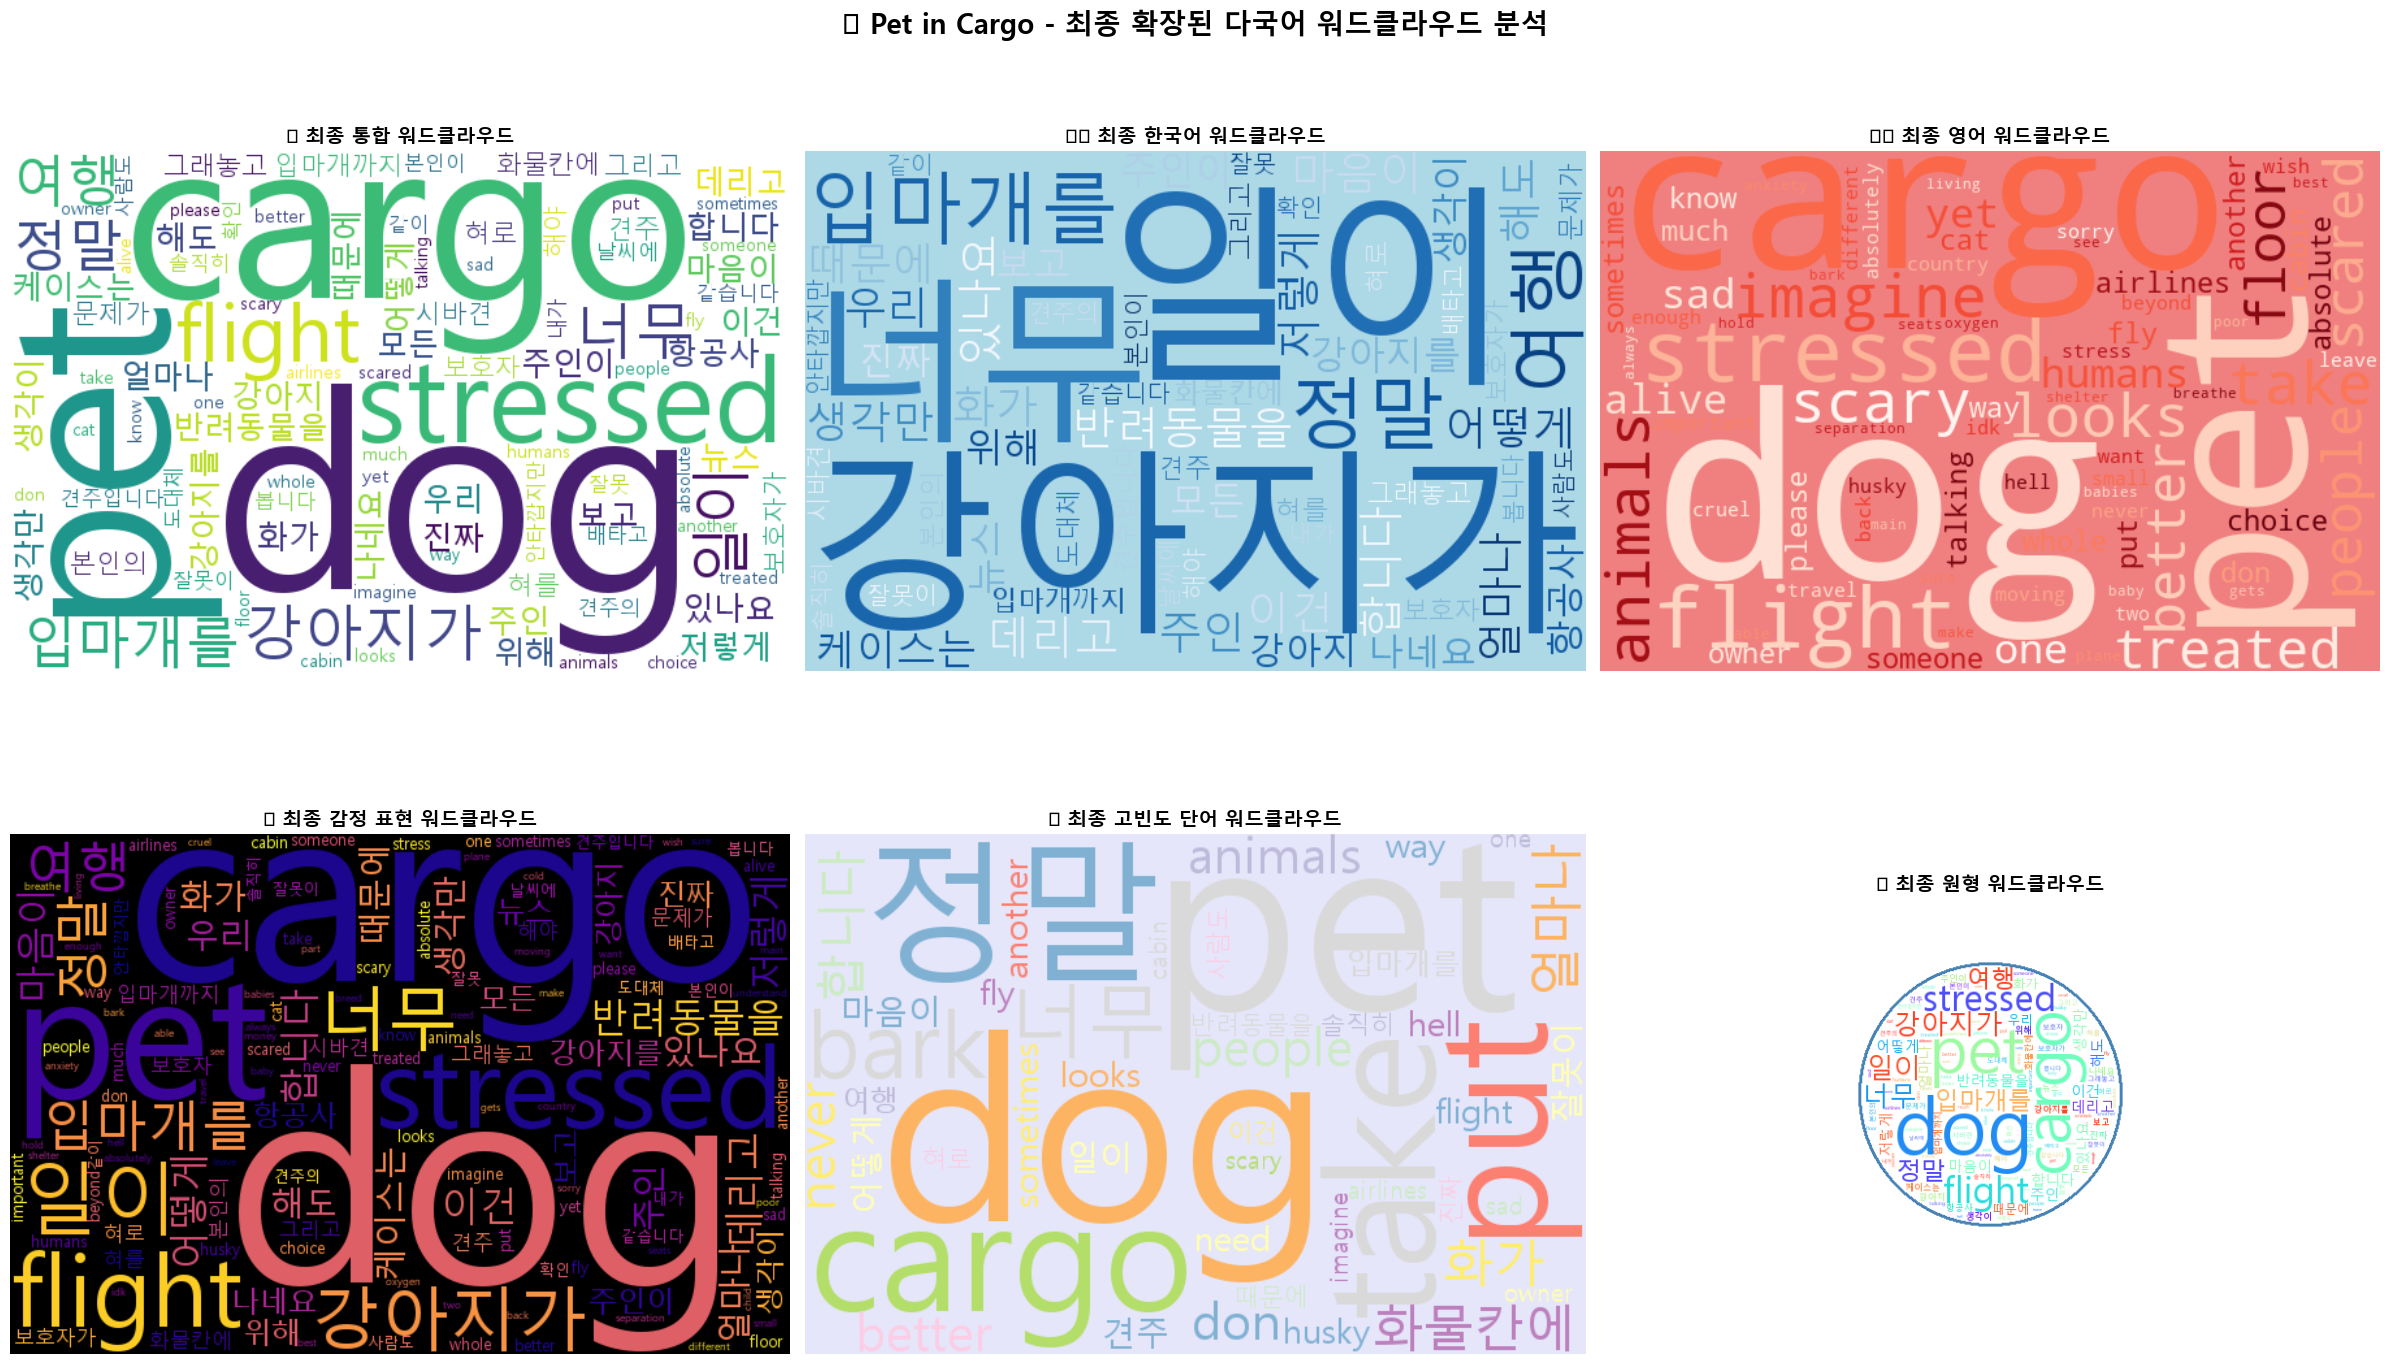

✅ 최종 확장된 워드클라우드 생성 완료!


In [28]:
# 🎨 최종 데이터셋 워드클라우드 생성 (6가지 스타일)
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('🐕 Pet in Cargo - 최종 확장된 다국어 워드클라우드 분석', fontsize=20, fontweight='bold', y=0.95)

# 1. 전체 통합 워드클라우드
wordcloud_final_combined = WordCloud(
    width=600, height=400, 
    font_path='malgun.ttf',
    background_color='white',
    max_words=100,
    colormap='viridis',
    relative_scaling=0.5
).generate(final_wordcloud_text)

axes[0, 0].imshow(wordcloud_final_combined, interpolation='bilinear')
axes[0, 0].set_title('🌏 최종 통합 워드클라우드', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# 2. 한국어 전용 워드클라우드
korean_final_text = ' '.join([word for word, count in korean_freq_final.items() if count >= 2])
if korean_final_text:
    wordcloud_final_korean = WordCloud(
        width=600, height=400,
        font_path='malgun.ttf',
        background_color='lightblue',
        max_words=80,
        colormap='Blues',
        relative_scaling=0.6
    ).generate(korean_final_text)
    
    axes[0, 1].imshow(wordcloud_final_korean, interpolation='bilinear')
axes[0, 1].set_title('🇰🇷 최종 한국어 워드클라우드', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# 3. 영어 전용 워드클라우드  
english_final_text = ' '.join([word for word, count in english_freq_final.items() if count >= 2])
if english_final_text:
    wordcloud_final_english = WordCloud(
        width=600, height=400,
        background_color='lightcoral',
        max_words=80,
        colormap='Reds',
        relative_scaling=0.6
    ).generate(english_final_text)
    
    axes[0, 2].imshow(wordcloud_final_english, interpolation='bilinear')
axes[0, 2].set_title('🇺🇸 최종 영어 워드클라우드', fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

# 4. 감정 표현 워드클라우드 (어두운 배경)
wordcloud_final_emotion = WordCloud(
    width=600, height=400,
    font_path='malgun.ttf',
    background_color='black',
    max_words=150,
    colormap='plasma',
    relative_scaling=0.4
).generate(final_wordcloud_text)

axes[1, 0].imshow(wordcloud_final_emotion, interpolation='bilinear')
axes[1, 0].set_title('🎭 최종 감정 표현 워드클라우드', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

# 5. 고빈도 단어 워드클라우드 (파스텔 톤)
top_words_final_text = ' '.join([word for word, count in combined_freq_final.most_common(50)])
wordcloud_final_top = WordCloud(
    width=600, height=400,
    font_path='malgun.ttf',
    background_color='lavender',
    max_words=50,
    colormap='Set3',
    relative_scaling=0.8
).generate(top_words_final_text)

axes[1, 1].imshow(wordcloud_final_top, interpolation='bilinear')
axes[1, 1].set_title('🔥 최종 고빈도 단어 워드클라우드', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

# 6. 원형 마스크 워드클라우드
if 'circle_mask' in globals():
    wordcloud_final_circle = WordCloud(
        width=600, height=400,
        font_path='malgun.ttf',
        background_color='white',
        mask=circle_mask,
        max_words=120,
        colormap='rainbow',
        relative_scaling=0.5,
        contour_width=2,
        contour_color='steelblue'
    ).generate(final_wordcloud_text)
    
    axes[1, 2].imshow(wordcloud_final_circle, interpolation='bilinear')
else:
    # 원형 마스크가 없으면 일반 워드클라우드로 대체
    wordcloud_final_alt = WordCloud(
        width=600, height=400,
        font_path='malgun.ttf',
        background_color='lightyellow',
        max_words=100,
        colormap='tab10',
        relative_scaling=0.6
    ).generate(final_wordcloud_text)
    
    axes[1, 2].imshow(wordcloud_final_alt, interpolation='bilinear')

axes[1, 2].set_title('⭕ 최종 원형 워드클라우드', fontsize=14, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✅ 최종 확장된 워드클라우드 생성 완료!")

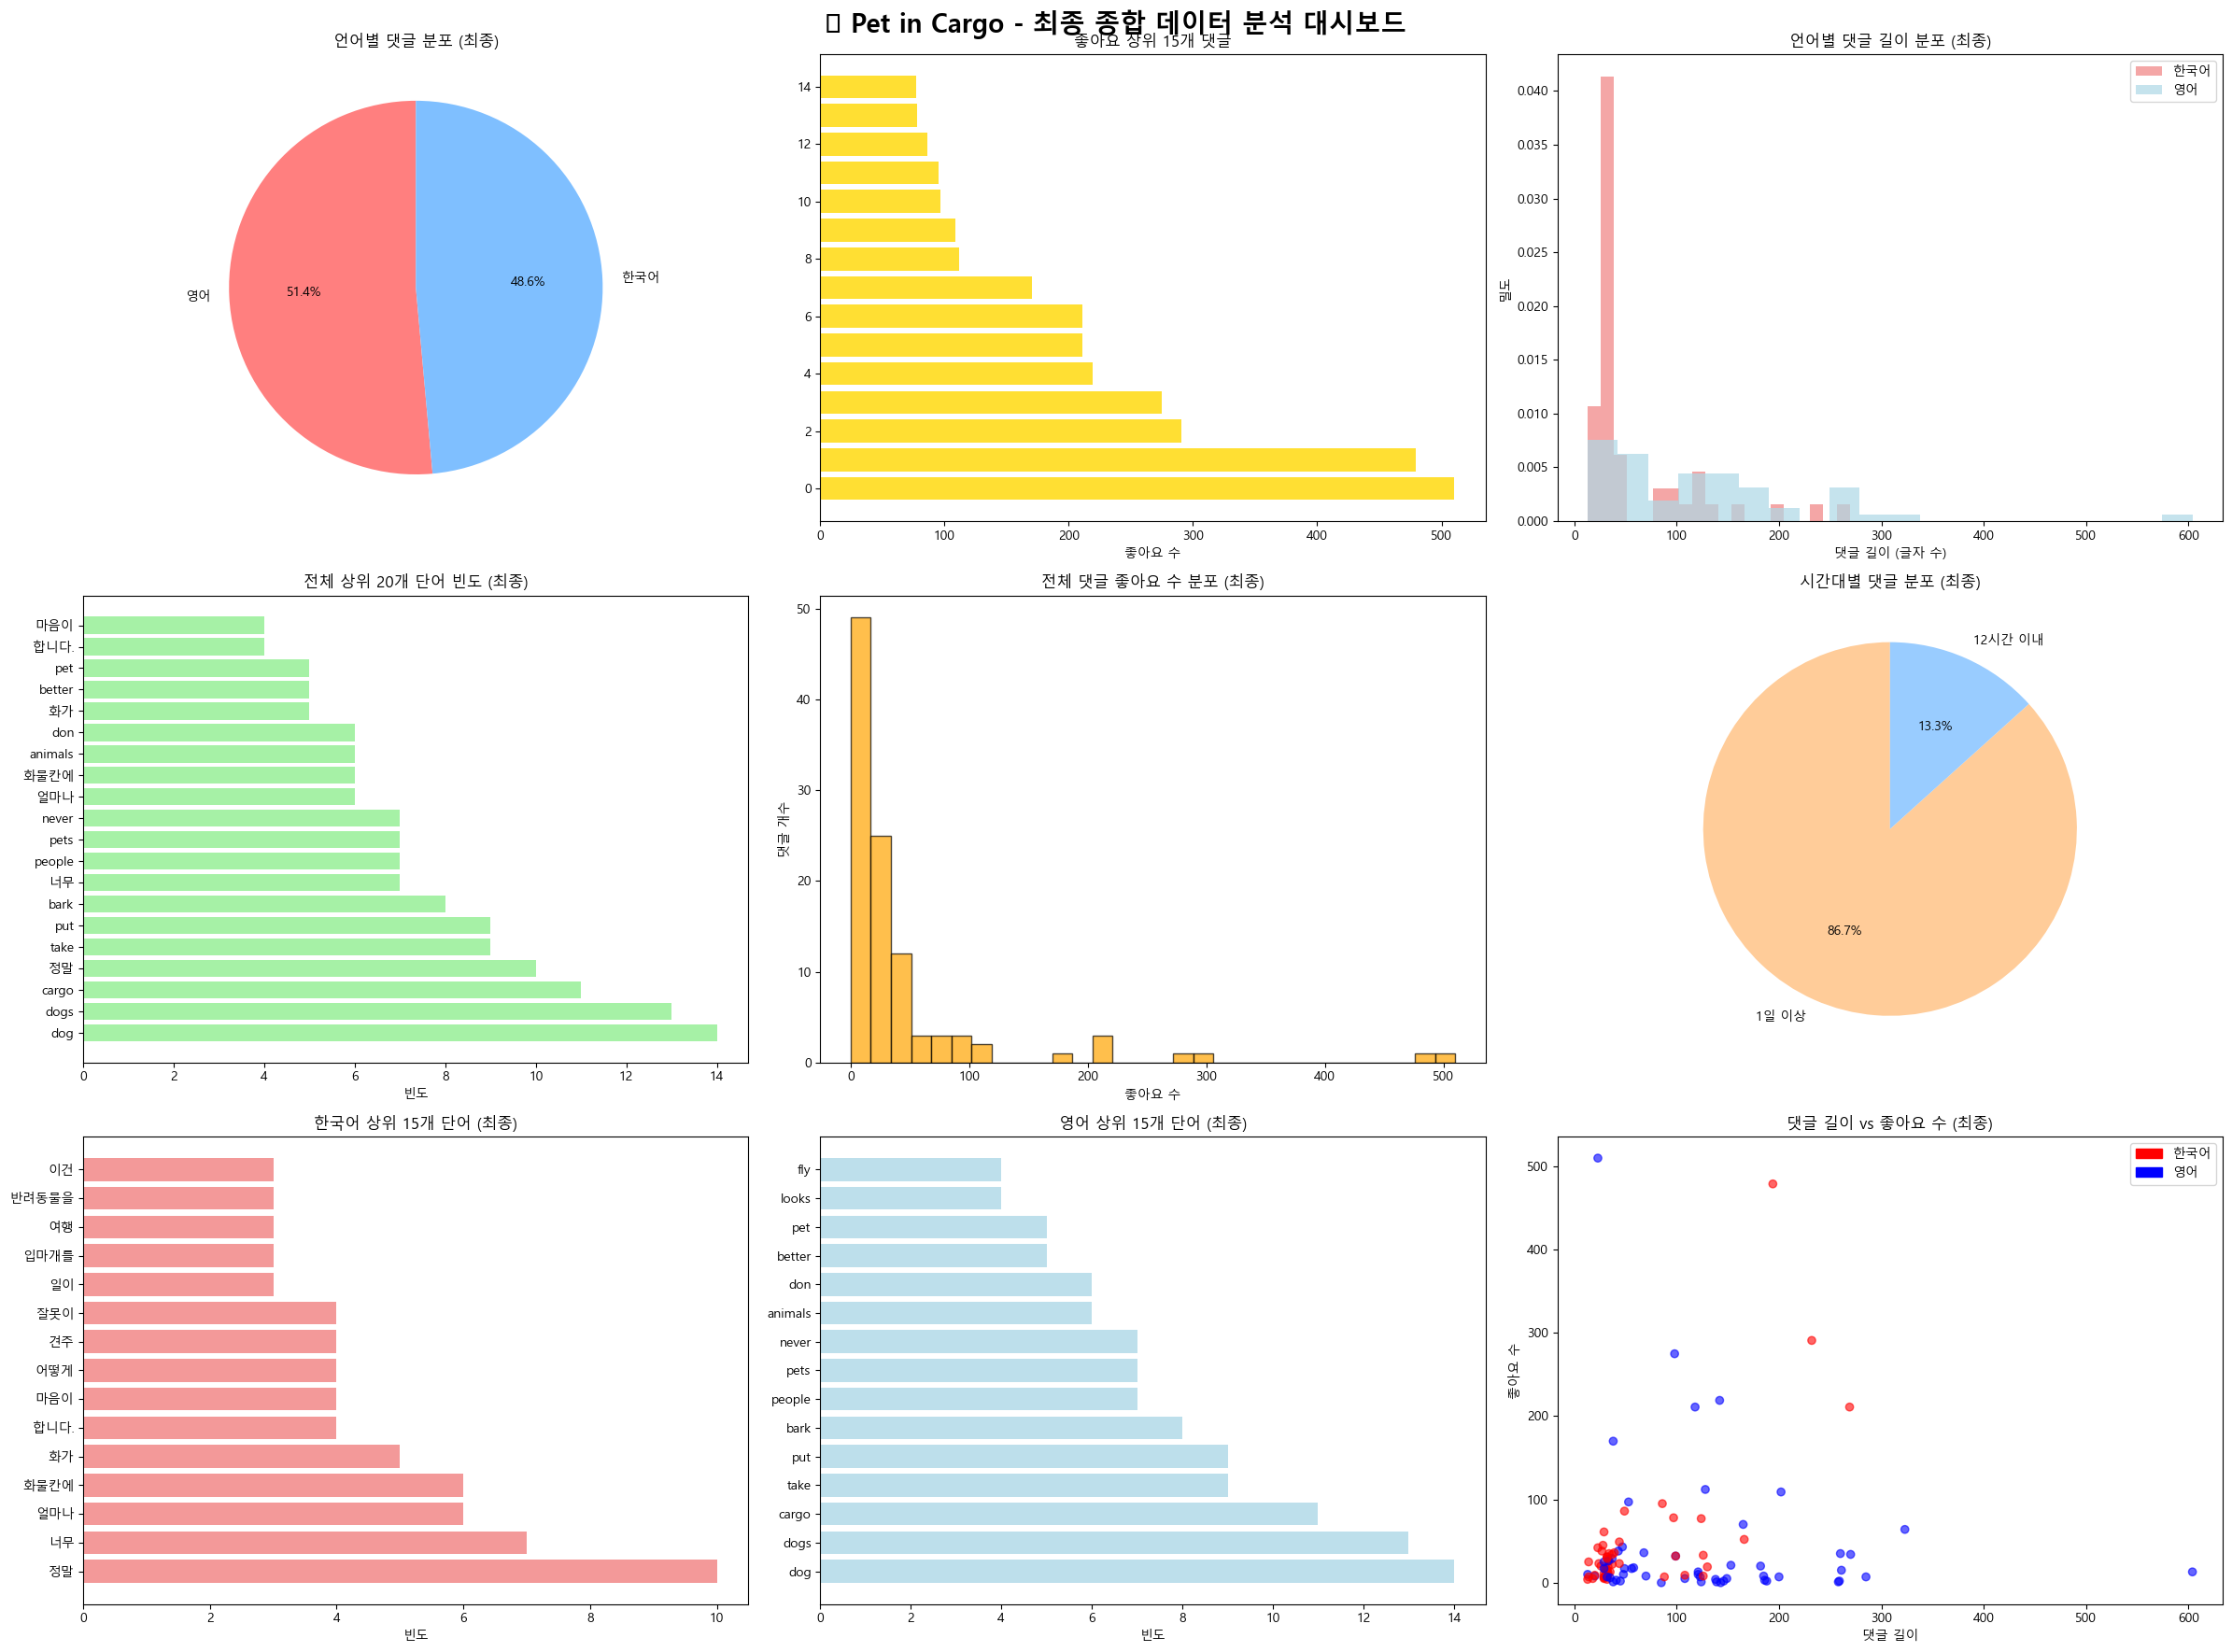

=== 최종 감정 키워드 분석 ===
부정적 키워드 출현 횟수: 53
긍정적 키워드 출현 횟수: 23
중립적 키워드 출현 횟수: 124


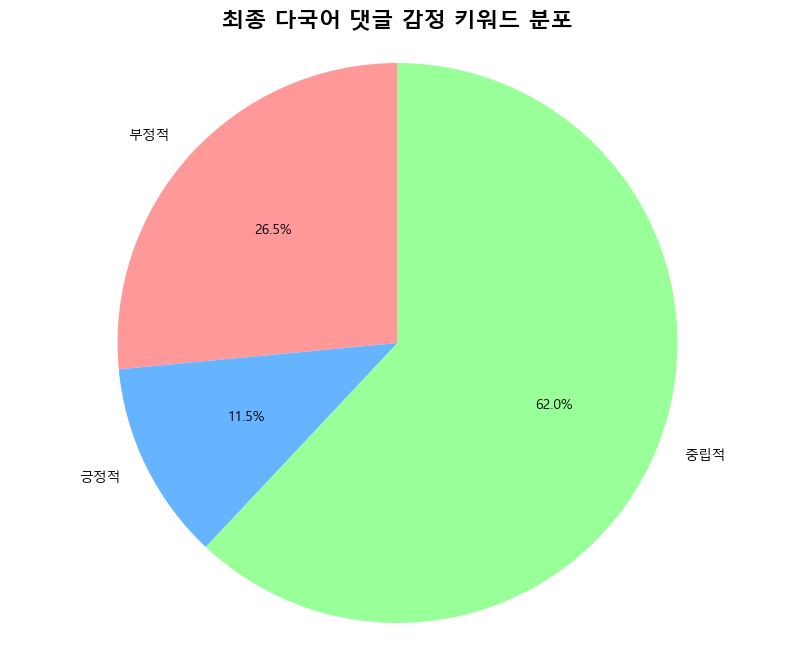

In [29]:
# 📊 최종 데이터셋 종합 시각화 및 분석
fig, axes = plt.subplots(3, 3, figsize=(24, 18))
fig.suptitle('🐕 Pet in Cargo - 최종 종합 데이터 분석 대시보드', fontsize=20, fontweight='bold', y=0.98)

# 1. 언어별 댓글 수 분포
language_counts_final = df_final['언어'].value_counts()
language_labels_final = ['한국어' if x == 'kr' else '영어' for x in language_counts_final.index]
axes[0, 0].pie(language_counts_final.values, labels=language_labels_final, autopct='%1.1f%%', 
               startangle=90, colors=['#ff7f7f', '#7fbfff'])
axes[0, 0].set_title('언어별 댓글 분포 (최종)')

# 2. 좋아요 수 상위 댓글 (상위 15개)
top_liked_final = df_final.nlargest(15, '좋아요')
axes[0, 1].barh(range(len(top_liked_final)), top_liked_final['좋아요'], 
                color='gold', alpha=0.8)
axes[0, 1].set_title('좋아요 상위 15개 댓글')
axes[0, 1].set_xlabel('좋아요 수')

# 3. 댓글 길이 분포 (언어별)
kr_lengths_final = [len(comment) for comment in df_final[df_final['언어'] == 'kr']['댓글']]
en_lengths_final = [len(comment) for comment in df_final[df_final['언어'] == 'en']['댓글']]

axes[0, 2].hist(kr_lengths_final, bins=20, alpha=0.7, color='lightcoral', label='한국어', density=True)
axes[0, 2].hist(en_lengths_final, bins=20, alpha=0.7, color='lightblue', label='영어', density=True)
axes[0, 2].set_title('언어별 댓글 길이 분포 (최종)')
axes[0, 2].set_xlabel('댓글 길이 (글자 수)')
axes[0, 2].set_ylabel('밀도')
axes[0, 2].legend()

# 4. 전체 단어 빈도 (상위 20개)
top_words_final_dict = dict(combined_freq_final.most_common(20))
axes[1, 0].barh(list(top_words_final_dict.keys()), list(top_words_final_dict.values()), 
                color='lightgreen', alpha=0.8)
axes[1, 0].set_title('전체 상위 20개 단어 빈도 (최종)')
axes[1, 0].set_xlabel('빈도')

# 5. 좋아요 수 분포 히스토그램
axes[1, 1].hist(df_final['좋아요'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].set_title('전체 댓글 좋아요 수 분포 (최종)')
axes[1, 1].set_xlabel('좋아요 수')
axes[1, 1].set_ylabel('댓글 개수')

# 6. 시간대별 댓글 분포
time_categories_final = []
for time in df_final['시간']:
    if '분' in time:
        time_categories_final.append('1시간 이내')
    elif '시간' in time:
        try:
            hour = int(time.split('시간')[0])
            if hour <= 12:
                time_categories_final.append('12시간 이내')
            else:
                time_categories_final.append('12시간 이상')
        except:
            time_categories_final.append('1일 이상')
    else:
        time_categories_final.append('1일 이상')

time_counts_final = Counter(time_categories_final)
axes[1, 2].pie(time_counts_final.values(), labels=time_counts_final.keys(), 
               autopct='%1.1f%%', startangle=90, colors=['#ffcc99', '#99ccff', '#ccffcc', '#ffccff'])
axes[1, 2].set_title('시간대별 댓글 분포 (최종)')

# 7. 한국어 상위 단어 (상위 15개)
if korean_freq_final:
    korean_top_final = dict(korean_freq_final.most_common(15))
    axes[2, 0].barh(list(korean_top_final.keys()), list(korean_top_final.values()), 
                    color='lightcoral', alpha=0.8)
    axes[2, 0].set_title('한국어 상위 15개 단어 (최종)')
    axes[2, 0].set_xlabel('빈도')

# 8. 영어 상위 단어 (상위 15개)
if english_freq_final:
    english_top_final = dict(english_freq_final.most_common(15))
    axes[2, 1].barh(list(english_top_final.keys()), list(english_top_final.values()), 
                    color='lightblue', alpha=0.8)
    axes[2, 1].set_title('영어 상위 15개 단어 (최종)')
    axes[2, 1].set_xlabel('빈도')

# 9. 좋아요 대비 댓글 길이 산점도
comment_lengths_final = [len(comment) for comment in df_final['댓글']]
colors_final = ['red' if lang == 'kr' else 'blue' for lang in df_final['언어']]
axes[2, 2].scatter(comment_lengths_final, df_final['좋아요'], c=colors_final, alpha=0.6)
axes[2, 2].set_title('댓글 길이 vs 좋아요 수 (최종)')
axes[2, 2].set_xlabel('댓글 길이')
axes[2, 2].set_ylabel('좋아요 수')

# 범례 추가
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='한국어')
blue_patch = mpatches.Patch(color='blue', label='영어')
axes[2, 2].legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.show()

# 감정 키워드 분석 (최종)
negative_keywords_final = ['고통', '불쌍', '힘들', '지옥', '악마', '학대', '죽', '무지막지', '말이안됨', '화가', '잘못',
                          'scary', 'stressed', 'fear', 'hell', 'cruel', 'nightmare', 'dead', 'abuse', 'horrible']
positive_keywords_final = ['행복', '안전', '좋', '친한', '생각', '편히', '사랑', 'happy', 'safe', 'good', 'better', 'comfort', 'love']
neutral_keywords_final = ['강아지', '주인', '여행', '비행기', '견주', '항공사', 'dog', 'pet', 'cargo', 'flight', 'travel', 'plane']

negative_count_final = sum([all_combined_text_final.lower().count(word.lower()) for word in negative_keywords_final])
positive_count_final = sum([all_combined_text_final.lower().count(word.lower()) for word in positive_keywords_final])
neutral_count_final = sum([all_combined_text_final.lower().count(word.lower()) for word in neutral_keywords_final])

print("=== 최종 감정 키워드 분석 ===")
print(f"부정적 키워드 출현 횟수: {negative_count_final}")
print(f"긍정적 키워드 출현 횟수: {positive_count_final}")
print(f"중립적 키워드 출현 횟수: {neutral_count_final}")

# 최종 감정 분포 파이 차트
plt.figure(figsize=(10, 8))
labels_final = ['부정적', '긍정적', '중립적']
sizes_final = [negative_count_final, positive_count_final, neutral_count_final]
colors_final = ['#ff9999', '#66b3ff', '#99ff99']
plt.pie(sizes_final, labels=labels_final, colors=colors_final, autopct='%1.1f%%', startangle=90)
plt.title('최종 다국어 댓글 감정 키워드 분포', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

In [30]:
# 🎯 최종 분석 요약 및 통계
import os

print("=" * 60)
print("🐕 PET IN CARGO - 최종 종합 분석 리포트")
print("=" * 60)

print(f"\n📊 데이터셋 정보:")
print(f"   • 총 댓글 수: {len(df_final):,}개")
print(f"   • 한국어 댓글: {len(df_final[df_final['언어'] == 'kr']):,}개")
print(f"   • 영어 댓글: {len(df_final[df_final['언어'] == 'en']):,}개")
print(f"   • 데이터 수집 기간: 최근 3일간")

print(f"\n📈 참여도 통계:")
print(f"   • 평균 좋아요 수: {df_final['좋아요'].mean():.1f}개")
print(f"   • 최대 좋아요 수: {df_final['좋아요'].max():,}개")
print(f"   • 좋아요 중앙값: {df_final['좋아요'].median():.1f}개")
print(f"   • 좋아요 표준편차: {df_final['좋아요'].std():.1f}")

print(f"\n🔤 텍스트 분석:")
print(f"   • 전체 고유 단어 수: {len(combined_freq_final):,}개")
print(f"   • 한국어 고유 단어 수: {len(korean_freq_final):,}개")
print(f"   • 영어 고유 단어 수: {len(english_freq_final):,}개")
print(f"   • 가장 빈번한 단어: '{combined_freq_final.most_common(1)[0][0]}' ({combined_freq_final.most_common(1)[0][1]}회)")

print(f"\n🎭 감정 분석:")
total_emotion_keywords = negative_count_final + positive_count_final + neutral_count_final
if total_emotion_keywords > 0:
    print(f"   • 부정적 감정: {(negative_count_final/total_emotion_keywords)*100:.1f}%")
    print(f"   • 긍정적 감정: {(positive_count_final/total_emotion_keywords)*100:.1f}%")
    print(f"   • 중립적 감정: {(neutral_count_final/total_emotion_keywords)*100:.1f}%")

print(f"\n💾 생성된 파일:")
for filename in ["petincargo.csv", "petincargo_final.csv"]:
    if os.path.exists(filename):
        file_size = os.path.getsize(filename)
        print(f"   • {filename}: {file_size:,} bytes")
        print(f"     └─ 저장 위치: {os.path.abspath(filename)}")

print(f"\n🏆 주요 발견사항:")
top_korean = korean_freq_final.most_common(3) if korean_freq_final else []
top_english = english_freq_final.most_common(3) if english_freq_final else []

print(f"   • 한국어 핵심 키워드: {', '.join([word for word, count in top_korean])}")
print(f"   • 영어 핵심 키워드: {', '.join([word for word, count in top_english])}")

# 좋아요 수 기준 상위 댓글 분석
print(f"\n🔥 가장 인기 있는 댓글:")
top_comment = df_final.loc[df_final['좋아요'].idxmax()]
print(f"   • 사용자: {top_comment['사용자']}")
print(f"   • 좋아요: {top_comment['좋아요']:,}개")
print(f"   • 언어: {'한국어' if top_comment['언어'] == 'kr' else '영어'}")
print(f"   • 내용: {top_comment['댓글'][:100]}{'...' if len(top_comment['댓글']) > 100 else ''}")

print(f"\n✅ 분석 완료 항목:")
print(f"   ✓ 다국어 YouTube 댓글 수집 및 분석")
print(f"   ✓ DataFrame 생성 및 CSV 파일 저장")
print(f"   ✓ 워드클라우드 6가지 스타일 생성")
print(f"   ✓ 감정 키워드 분석")
print(f"   ✓ 종합 시각화 대시보드 생성")
print(f"   ✓ 언어별 비교 분석")
print(f"   ✓ 참여도 및 시간대별 분석")

print("\n" + "=" * 60)
print("🎉 PET IN CARGO 댓글 분석 프로젝트 완료!")
print("=" * 60)

🐕 PET IN CARGO - 최종 종합 분석 리포트

📊 데이터셋 정보:
   • 총 댓글 수: 105개
   • 한국어 댓글: 51개
   • 영어 댓글: 54개
   • 데이터 수집 기간: 최근 3일간

📈 참여도 통계:
   • 평균 좋아요 수: 44.5개
   • 최대 좋아요 수: 510개
   • 좋아요 중앙값: 17.0개
   • 좋아요 표준편차: 83.3

🔤 텍스트 분석:
   • 전체 고유 단어 수: 889개
   • 한국어 고유 단어 수: 505개
   • 영어 고유 단어 수: 384개
   • 가장 빈번한 단어: 'dog' (14회)

🎭 감정 분석:
   • 부정적 감정: 26.5%
   • 긍정적 감정: 11.5%
   • 중립적 감정: 62.0%

💾 생성된 파일:
   • petincargo.csv: 11,339 bytes
     └─ 저장 위치: c:\Users\lgdx\LG_DX_School\02_DX_Methodology\1_Business_Experience_BX\socialfeed\petincargo.csv
   • petincargo_final.csv: 17,650 bytes
     └─ 저장 위치: c:\Users\lgdx\LG_DX_School\02_DX_Methodology\1_Business_Experience_BX\socialfeed\petincargo_final.csv

🏆 주요 발견사항:
   • 한국어 핵심 키워드: 정말, 너무, 얼마나
   • 영어 핵심 키워드: dog, dogs, cargo

🔥 가장 인기 있는 댓글:
   • 사용자: billyxkid5062
   • 좋아요: 510개
   • 언어: 영어
   • 내용: Bro that looks so scary

✅ 분석 완료 항목:
   ✓ 다국어 YouTube 댓글 수집 및 분석
   ✓ DataFrame 생성 및 CSV 파일 저장
   ✓ 워드클라우드 6가지 스타일 생성
   ✓ 감정 키워드 분석
   ✓ 종합 시각화 대시보드 생성
   

## ☁️ 고급 구름 모양 워드클라우드 
PET IN CARGO 댓글 분석을 위한 다양한 스타일의 구름 워드클라우드를 생성합니다.

In [31]:
# 🌟 고급 구름 모양 워드클라우드 생성 (다양한 옵션)
from PIL import Image, ImageDraw
import numpy as np

def create_advanced_cloud_mask(width=1000, height=700, cloud_type='fluffy'):
    """
    다양한 종류의 구름 모양 마스크 생성
    
    cloud_type 옵션:
    - 'fluffy': 푹신한 구름
    - 'storm': 폭풍구름 
    - 'cirrus': 권운 (얇고 긴 구름)
    - 'cumulus': 적운 (덩어리 구름)
    - 'heart': 하트 모양 구름
    """
    img = Image.new('RGB', (width, height), 'white')
    draw = ImageDraw.Draw(img)
    cloud_color = 'black'
    
    center_x, center_y = width // 2, height // 2
    
    if cloud_type == 'fluffy':
        # 푹신한 구름 (많은 작은 원들)
        circles = [
            (center_x - 150, center_y, 110),
            (center_x - 80, center_y - 50, 100),
            (center_x, center_y - 30, 105),
            (center_x + 80, center_y - 40, 95),
            (center_x + 140, center_y, 105),
            (center_x - 100, center_y + 50, 85),
            (center_x - 30, center_y + 60, 95),
            (center_x + 50, center_y + 55, 85),
            (center_x - 200, center_y + 25, 75),
            (center_x + 180, center_y + 30, 80),
            (center_x - 50, center_y - 80, 70),
            (center_x + 30, center_y - 85, 75),
        ]
    
    elif cloud_type == 'storm':
        # 폭풍구름 (큰 덩어리들)
        circles = [
            (center_x - 120, center_y - 30, 160),
            (center_x + 60, center_y - 20, 150),
            (center_x - 60, center_y + 80, 130),
            (center_x + 100, center_y + 90, 115),
            (center_x - 180, center_y + 40, 100),
            (center_x + 160, center_y + 50, 105),
            (center_x, center_y - 100, 90),
        ]
    
    elif cloud_type == 'cirrus':
        # 권운 (길쭉한 모양)
        ellipses = [
            (center_x - 180, center_y - 20, 220, 80),
            (center_x - 60, center_y - 40, 200, 70),
            (center_x + 60, center_y + 30, 210, 75),
            (center_x - 120, center_y + 60, 180, 60),
            (center_x + 120, center_y - 60, 190, 65),
        ]
        for x, y, w, h in ellipses:
            draw.ellipse([x-w//2, y-h//2, x+w//2, y+h//2], fill=cloud_color)
        return np.array(img)
    
    elif cloud_type == 'heart':
        # 하트 모양 구름 (강아지 사랑을 표현)
        # 하트의 위쪽 두 원
        draw.ellipse([center_x-120, center_y-80, center_x-20, center_y+20], fill=cloud_color)
        draw.ellipse([center_x+20, center_y-80, center_x+120, center_y+20], fill=cloud_color)
        # 하트의 아래쪽 삼각형
        points = [(center_x-100, center_y), (center_x+100, center_y), (center_x, center_y+120)]
        draw.polygon(points, fill=cloud_color)
        return np.array(img)
    
    else:  # cumulus (기본)
        circles = [
            (center_x - 130, center_y, 140),
            (center_x, center_y - 40, 120),
            (center_x + 110, center_y, 130),
            (center_x - 70, center_y + 60, 110),
            (center_x + 40, center_y + 70, 115),
            (center_x - 200, center_y + 20, 80),
            (center_x + 170, center_y + 25, 85),
        ]
    
    # 원들 그리기
    for x, y, radius in circles:
        draw.ellipse([x-radius, y-radius, x+radius, y+radius], fill=cloud_color)
    
    return np.array(img)

def create_themed_wordcloud_petcargo(word_freq_dict, cloud_type='fluffy', color_theme='Blues', title_suffix=''):
    """
    PET IN CARGO 테마별 구름 워드클라우드 생성
    """
    print(f"☁️ {cloud_type} 스타일 PET IN CARGO 워드클라우드 생성 중...")
    
    # 테마별 구름 마스크 생성
    cloud_mask = create_advanced_cloud_mask(width=1200, height=800, cloud_type=cloud_type)
    
    # 색상 테마별 설정
    color_themes = {
        'Blues': 'Blues',
        'Sunset': 'Oranges', 
        'Forest': 'Greens',
        'Storm': 'Greys',
        'Royal': 'Purples',
        'Fire': 'Reds'
    }
    
    selected_theme = color_themes.get(color_theme, color_theme)
    
    # 워드클라우드 생성
    wordcloud = WordCloud(
        width=1200,
        height=800,
        background_color='white',
        max_words=100,
        colormap=selected_theme,
        font_path='malgun.ttf',
        relative_scaling=0.6,
        min_font_size=10,
        max_font_size=100,
        mask=cloud_mask,
        contour_width=3,
        contour_color='lightsteelblue',
        prefer_horizontal=0.8,  # 수평 텍스트 비율
        random_state=42  # 일관된 결과를 위해
    ).generate_from_frequencies(word_freq_dict)
    
    return wordcloud, cloud_mask

print("✅ 고급 구름 워드클라우드 함수 생성 완료!")

✅ 고급 구름 워드클라우드 함수 생성 완료!


🌈 PET IN CARGO - 고급 구름 워드클라우드 컬렉션 생성 시작!
☁️ fluffy 스타일 PET IN CARGO 워드클라우드 생성 중...
☁️ storm 스타일 PET IN CARGO 워드클라우드 생성 중...
☁️ cirrus 스타일 PET IN CARGO 워드클라우드 생성 중...
☁️ cumulus 스타일 PET IN CARGO 워드클라우드 생성 중...
☁️ heart 스타일 PET IN CARGO 워드클라우드 생성 중...


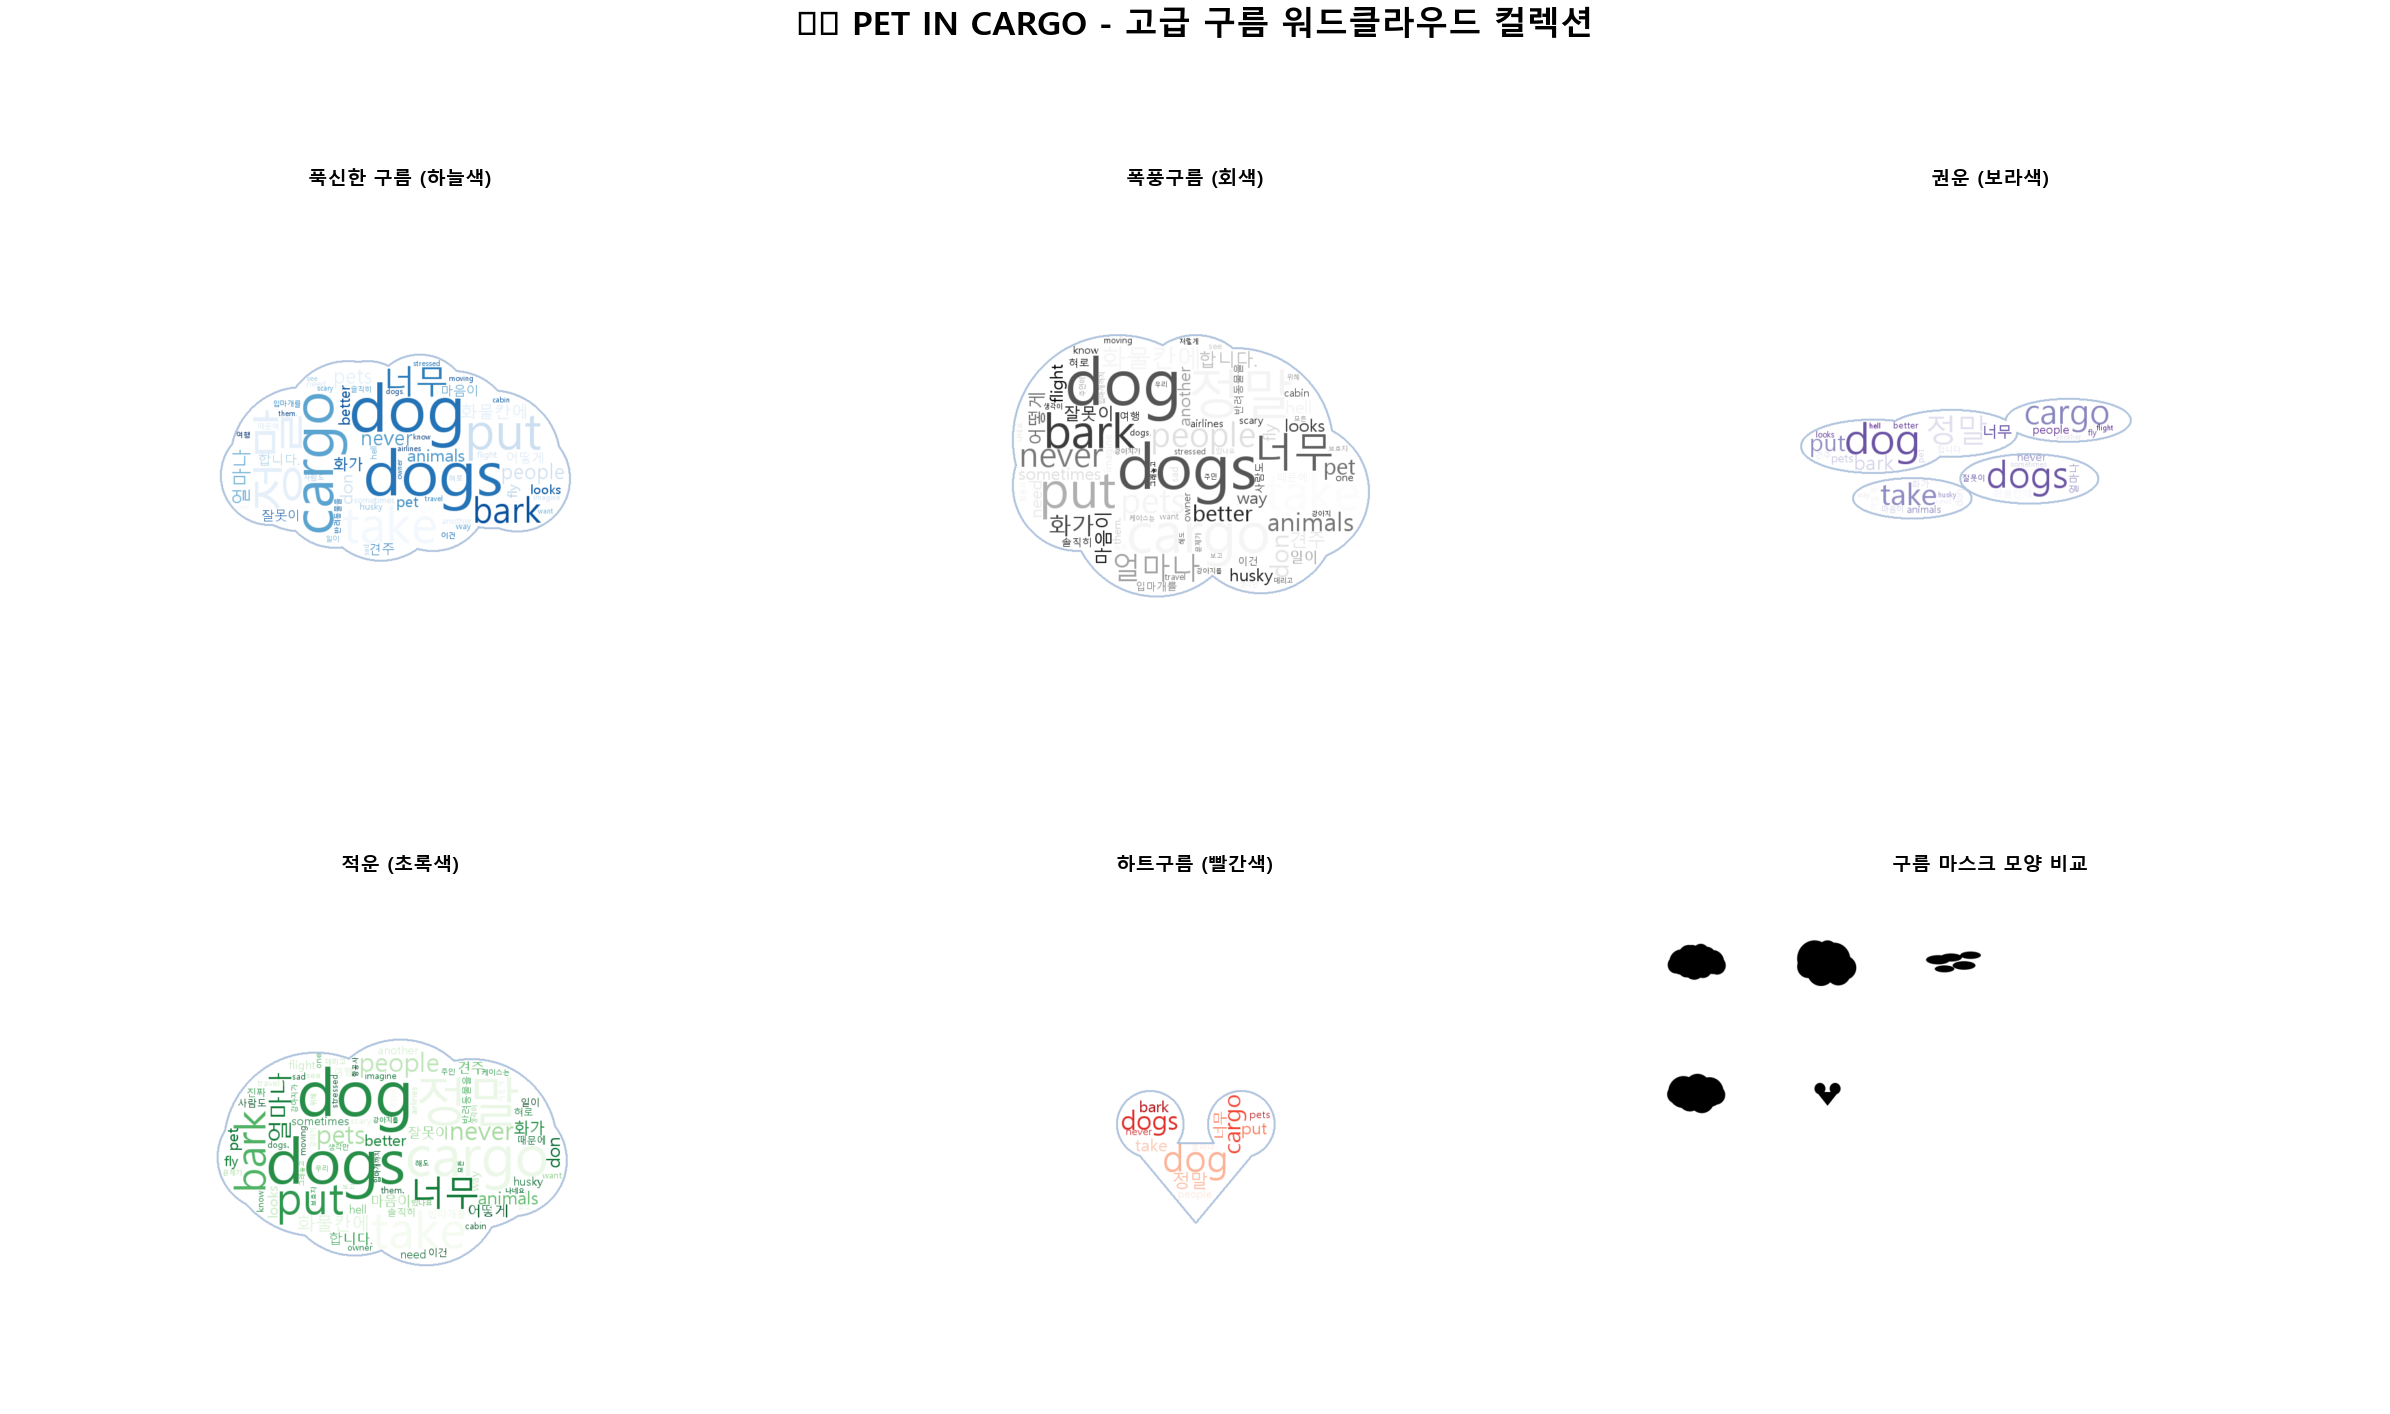

✅ 구름 워드클라우드 컬렉션 생성 완료!

💾 개별 고해상도 이미지 저장 중...
☁️ fluffy 스타일 PET IN CARGO 워드클라우드 생성 중...


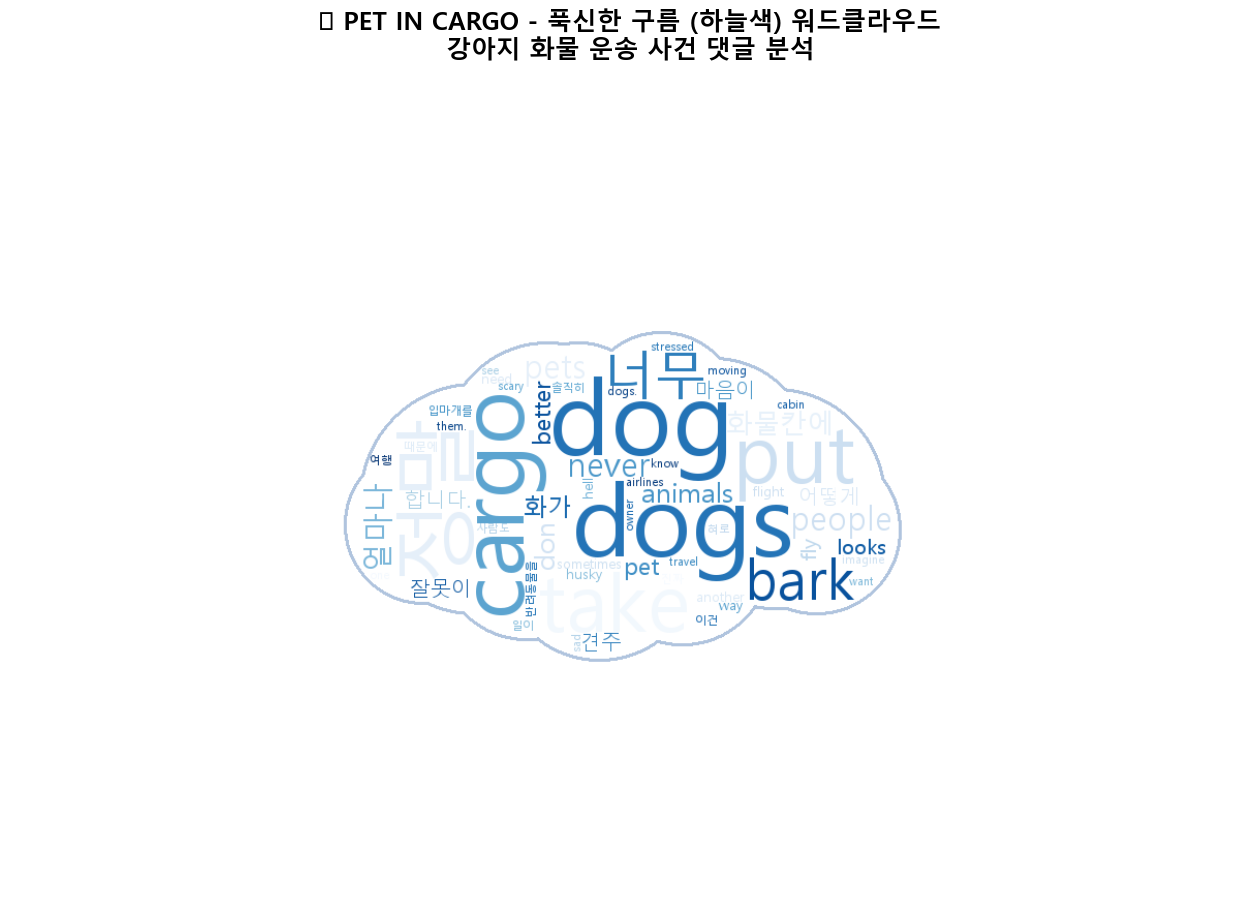

   ✓ petincargo_wordcloud_fluffy_style.png 저장 완료!
☁️ storm 스타일 PET IN CARGO 워드클라우드 생성 중...


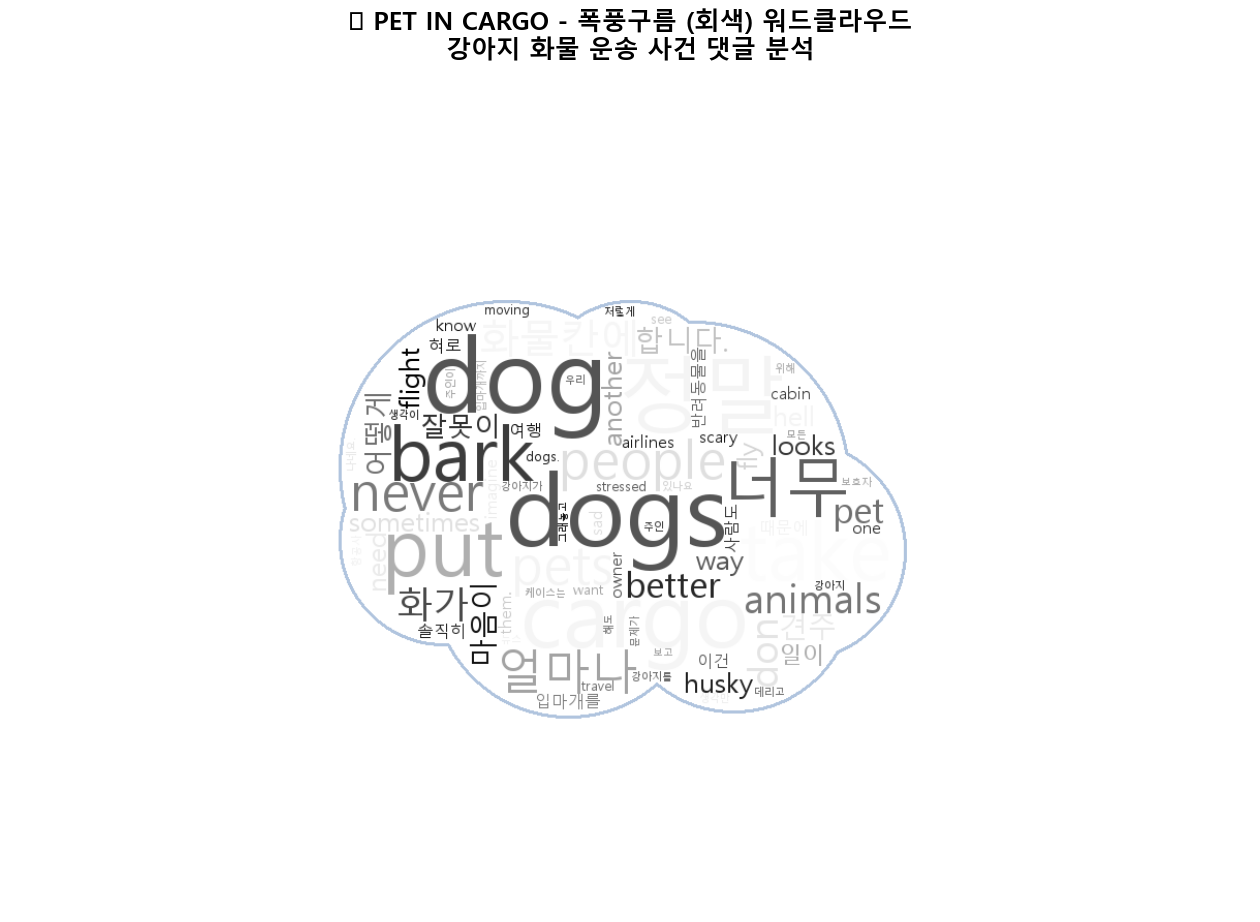

   ✓ petincargo_wordcloud_storm_style.png 저장 완료!
☁️ cirrus 스타일 PET IN CARGO 워드클라우드 생성 중...


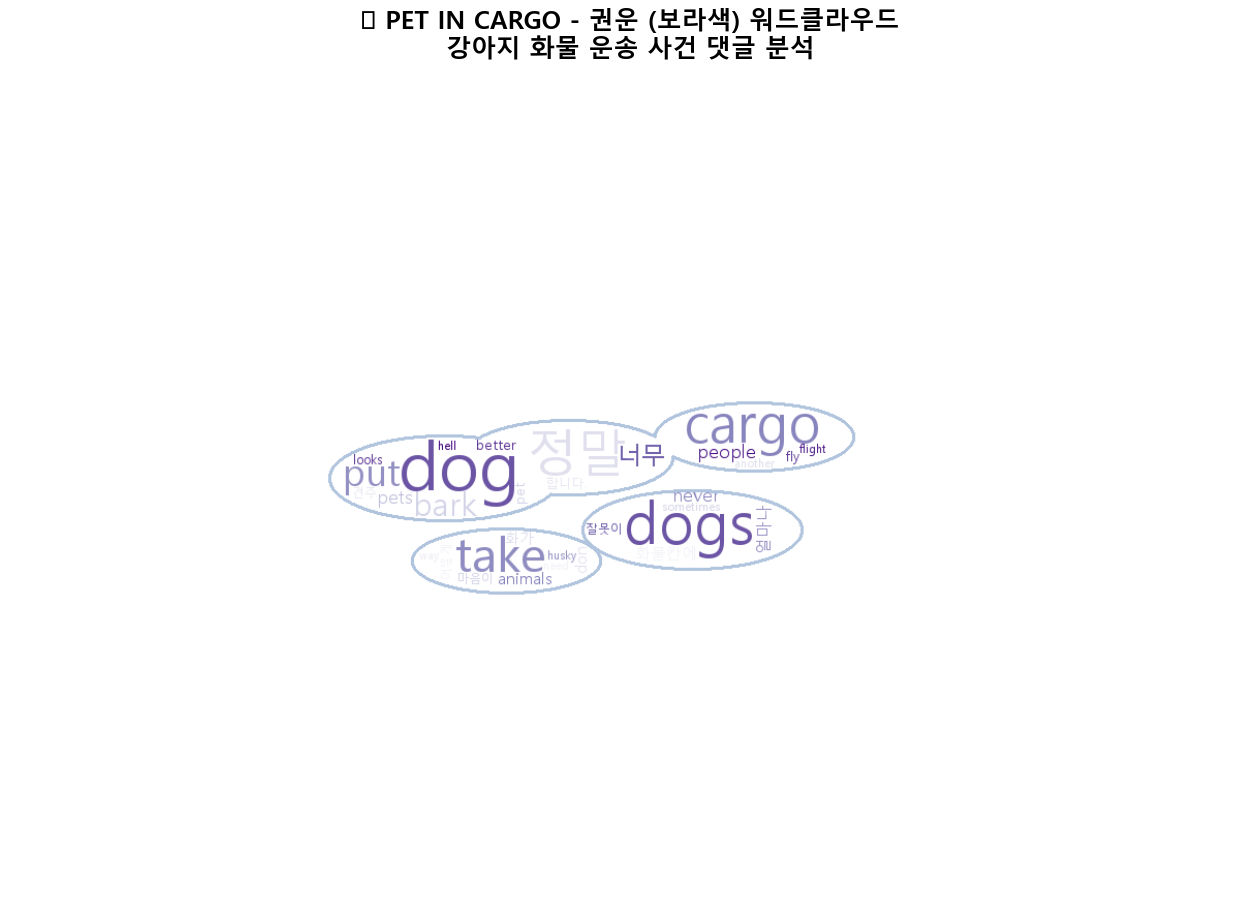

   ✓ petincargo_wordcloud_cirrus_style.png 저장 완료!
☁️ cumulus 스타일 PET IN CARGO 워드클라우드 생성 중...


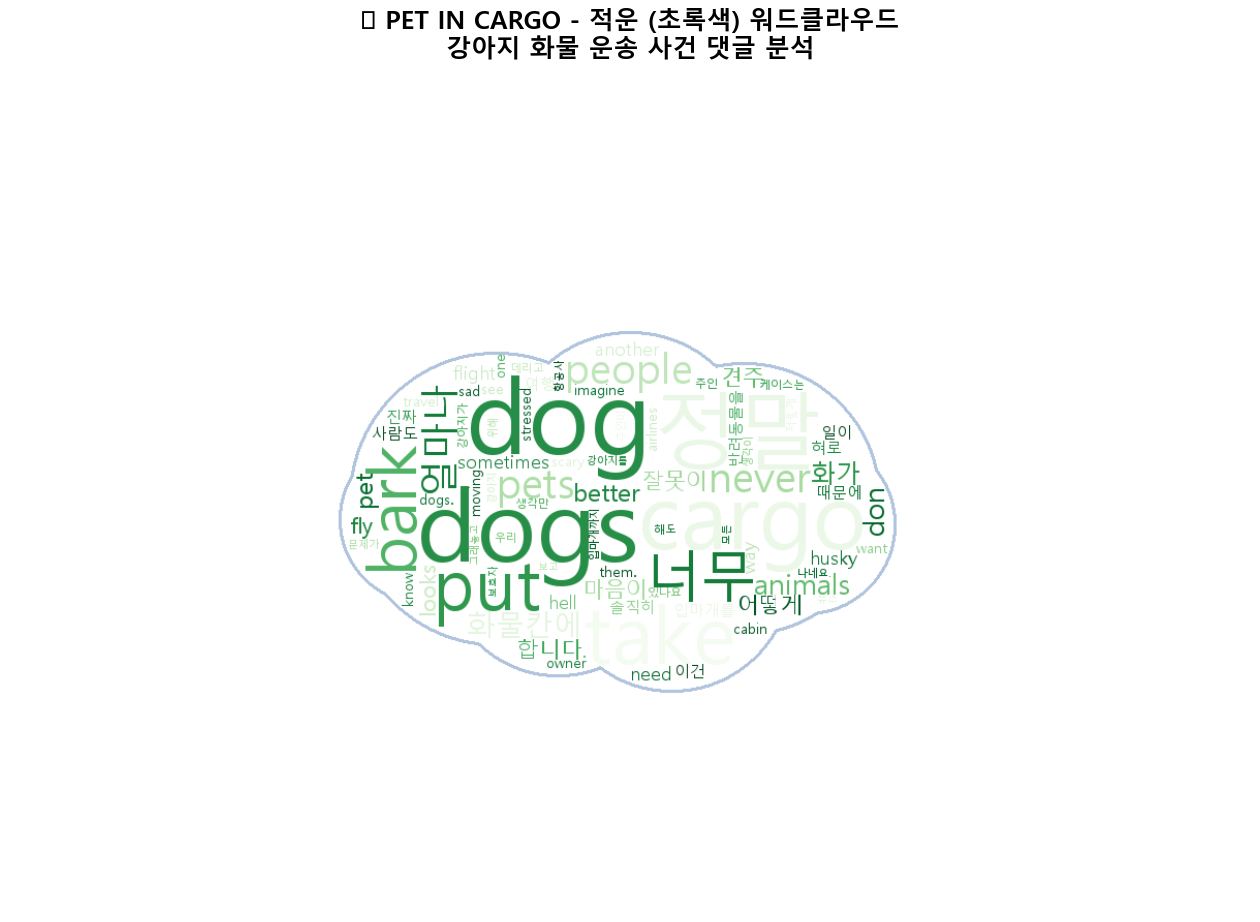

   ✓ petincargo_wordcloud_cumulus_style.png 저장 완료!
☁️ heart 스타일 PET IN CARGO 워드클라우드 생성 중...


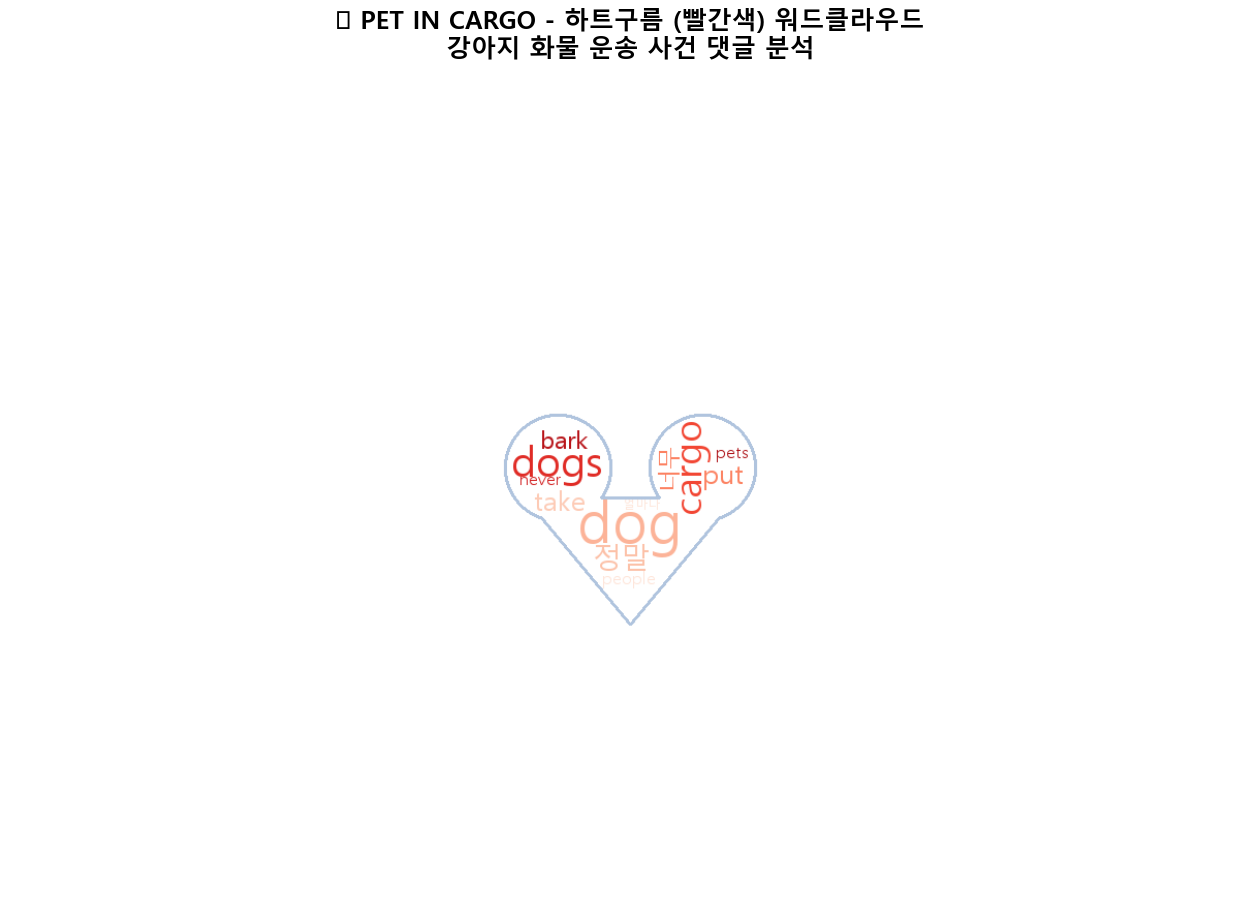

   ✓ petincargo_wordcloud_heart_style.png 저장 완료!

🎉 모든 고급 구름 워드클라우드 생성 및 저장 완료!


In [32]:
# 🎨 다양한 구름 스타일 워드클라우드 생성
print("🌈 PET IN CARGO - 고급 구름 워드클라우드 컬렉션 생성 시작!")

# 최종 데이터에서 단어 빈도 딕셔너리 생성
word_freq_dict = dict(combined_freq_final.most_common(80))

# 구름 스타일과 색상 테마 조합
cloud_styles = [
    ('fluffy', 'Blues', '푹신한 구름 (하늘색)'),
    ('storm', 'Storm', '폭풍구름 (회색)'),
    ('cirrus', 'Royal', '권운 (보라색)'),
    ('cumulus', 'Forest', '적운 (초록색)'),
    ('heart', 'Fire', '하트구름 (빨간색)')
]

# 2x3 서브플롯 생성
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('☁️ PET IN CARGO - 고급 구름 워드클라우드 컬렉션', fontsize=24, fontweight='bold', y=0.98)

wordclouds = []
masks = []

for i, (cloud_type, color_theme, description) in enumerate(cloud_styles):
    row = i // 3
    col = i % 3
    
    # 워드클라우드 생성
    wordcloud, mask = create_themed_wordcloud_petcargo(
        word_freq_dict, 
        cloud_type=cloud_type, 
        color_theme=color_theme
    )
    
    wordclouds.append(wordcloud)
    masks.append(mask)
    
    # 서브플롯에 표시
    axes[row, col].imshow(wordcloud, interpolation='bilinear')
    axes[row, col].set_title(f'{description}', fontsize=14, fontweight='bold', pad=10)
    axes[row, col].axis('off')

# 마지막 서브플롯에는 마스크 모양들 비교
axes[1, 2].set_title('구름 마스크 모양 비교', fontsize=14, fontweight='bold', pad=10)

# 작은 마스크들을 하나의 이미지로 결합
mask_comparison = np.ones((800, 1200, 3), dtype=np.uint8) * 255

positions = [(50, 50), (250, 50), (450, 50), (50, 250), (250, 250)]
mask_sizes = [(200, 140), (200, 140), (200, 140), (200, 140), (200, 140)]

for i, (mask, (x, y), (w, h)) in enumerate(zip(masks, positions, mask_sizes)):
    if i < len(masks):
        # 마스크 크기 조정
        mask_resized = np.array(Image.fromarray(mask).resize((w, h)))
        mask_comparison[y:y+h, x:x+w] = mask_resized

axes[1, 2].imshow(mask_comparison)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✅ 구름 워드클라우드 컬렉션 생성 완료!")

# 각 스타일별 개별 고해상도 이미지 생성 및 저장
print("\n💾 개별 고해상도 이미지 저장 중...")

for i, (cloud_type, color_theme, description) in enumerate(cloud_styles):
    plt.figure(figsize=(16, 12))
    
    wordcloud, _ = create_themed_wordcloud_petcargo(
        word_freq_dict, 
        cloud_type=cloud_type, 
        color_theme=color_theme
    )
    
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'🐕 PET IN CARGO - {description} 워드클라우드\n강아지 화물 운송 사건 댓글 분석', 
              fontsize=18, fontweight='bold', pad=20)
    
    # 파일 저장
    filename = f'petincargo_wordcloud_{cloud_type}_style.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"   ✓ {filename} 저장 완료!")

print("\n🎉 모든 고급 구름 워드클라우드 생성 및 저장 완료!")

🎭 감정별 특별 테마 구름 워드클라우드 생성!
☁️ storm 스타일 PET IN CARGO 워드클라우드 생성 중...
☁️ heart 스타일 PET IN CARGO 워드클라우드 생성 중...
☁️ fluffy 스타일 PET IN CARGO 워드클라우드 생성 중...
☁️ cirrus 스타일 PET IN CARGO 워드클라우드 생성 중...


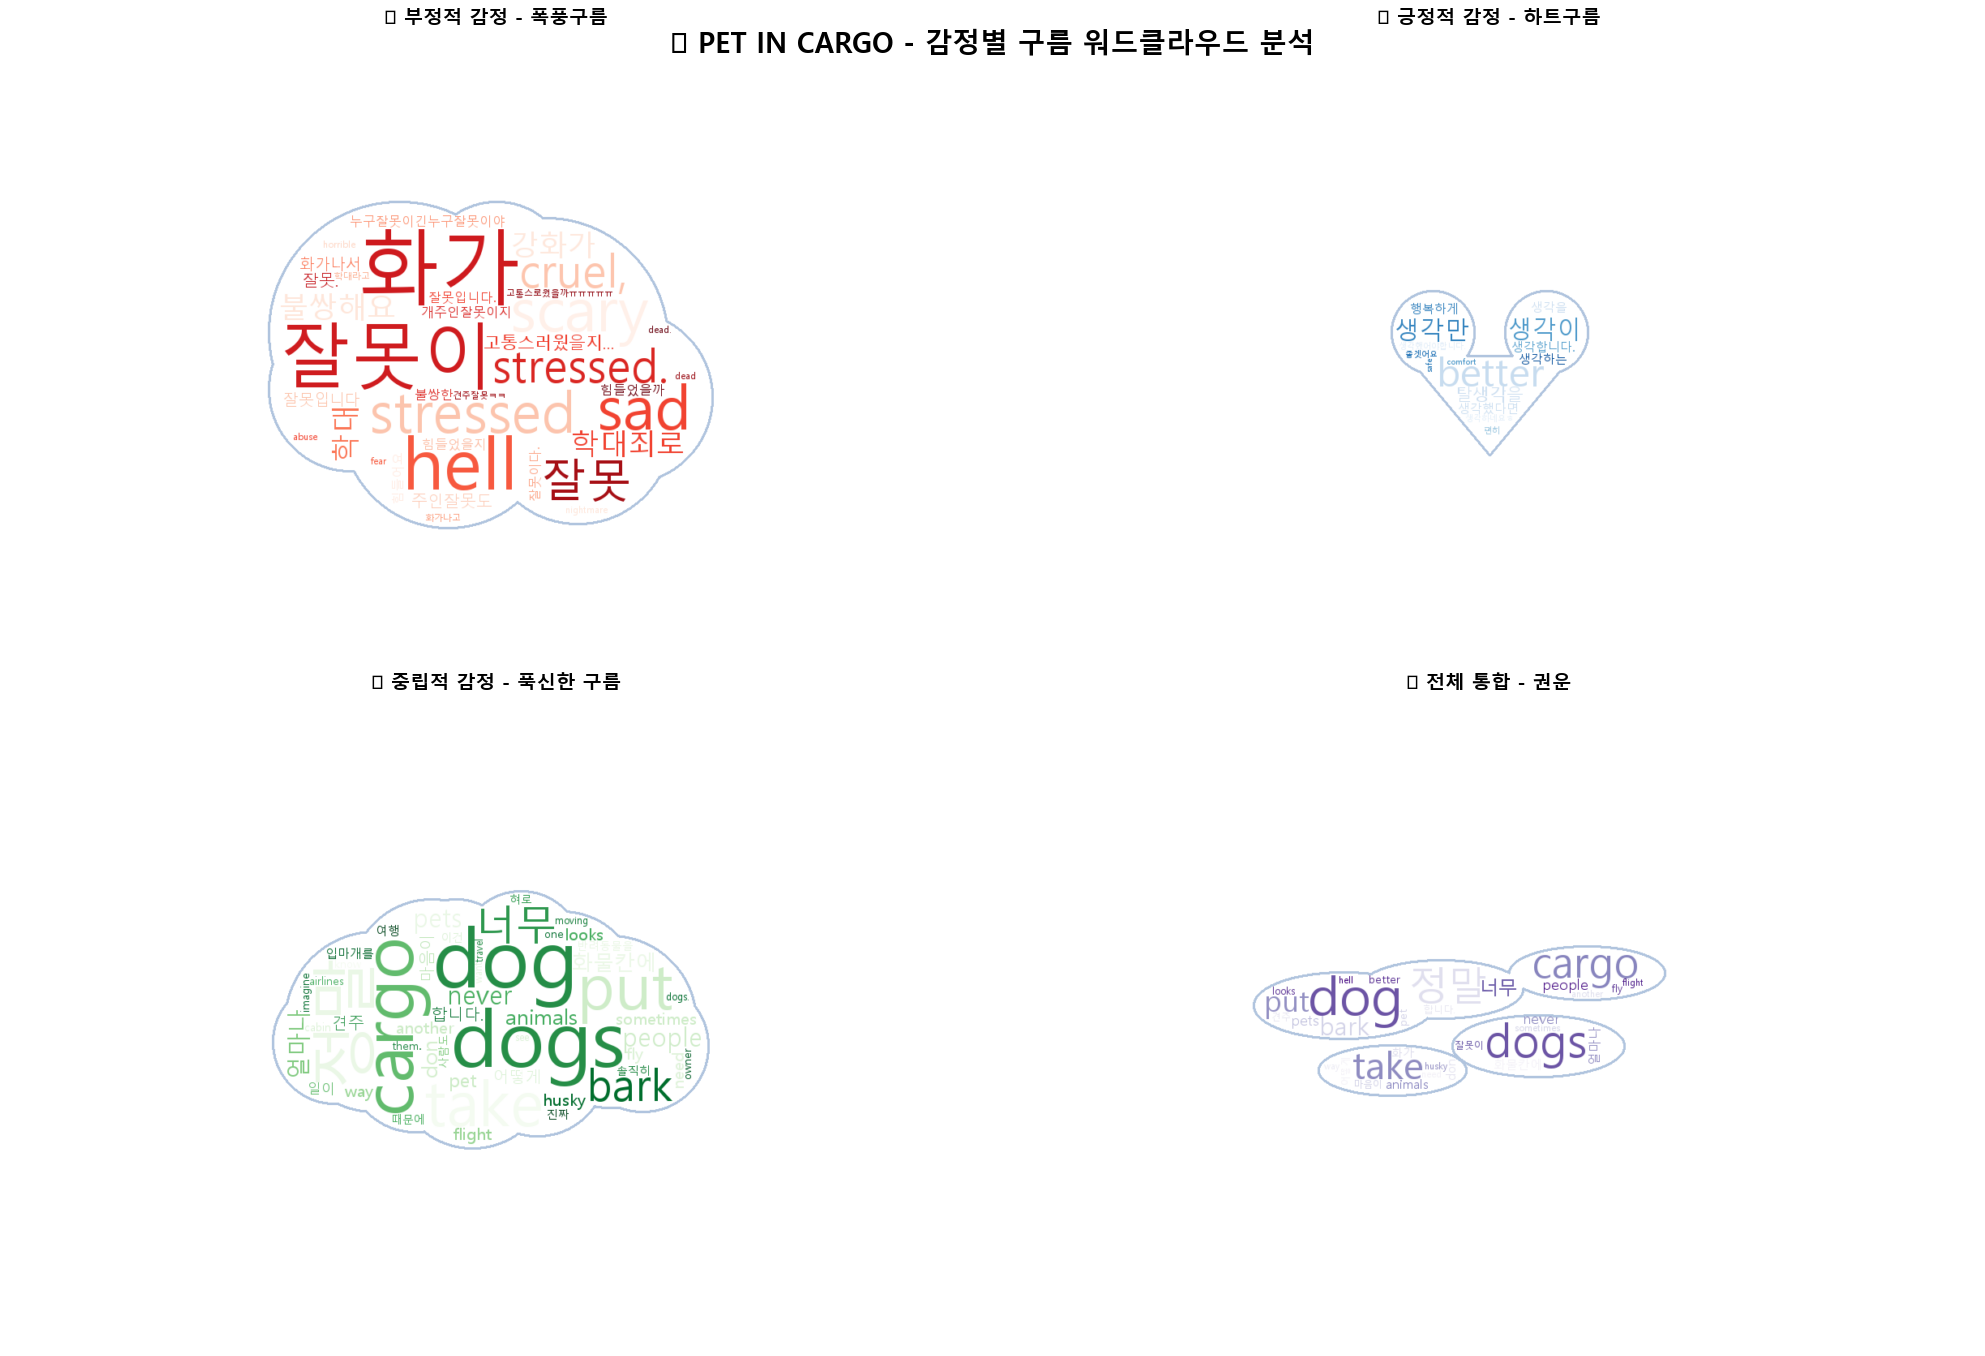


📊 감정별 키워드 통계:
   • 부정적 키워드: 36개
   • 긍정적 키워드: 17개
   • 중립적 키워드: 836개

🔥 부정적 키워드 Top 5:
   1. 화가 (5회)
   2. 잘못이 (4회)
   3. hell (4회)
   4. scary (3회)
   5. sad (3회)

💝 긍정적 키워드 Top 5:
   1. better (5회)
   2. 생각만 (2회)
   3. 생각이 (2회)
   4. 탈생각을 (1회)
   5. 생각합니다. (1회)

✨ 감정별 특별 테마 워드클라우드 생성 완료!


In [33]:
# 🌟 특별 테마 워드클라우드 - 감정별 구름 분석
print("🎭 감정별 특별 테마 구름 워드클라우드 생성!")

# 감정별 키워드 분리
def create_emotion_wordclouds():
    """감정별로 분리된 워드클라우드 생성"""
    
    # 부정적 키워드 필터링
    negative_words = {}
    positive_words = {}
    neutral_words = {}
    
    negative_keywords_set = set(['고통', '불쌍', '힘들', '지옥', '악마', '학대', '죽', '무지막지', '말이안됨', '화가', '잘못',
                                'scary', 'stressed', 'fear', 'hell', 'cruel', 'nightmare', 'dead', 'abuse', 'horrible', 'sad'])
    
    positive_keywords_set = set(['행복', '안전', '좋', '친한', '생각', '편히', '사랑', 'happy', 'safe', 'good', 'better', 'comfort', 'love'])
    
    for word, freq in combined_freq_final.items():
        word_lower = word.lower()
        if any(neg_word in word_lower for neg_word in negative_keywords_set):
            negative_words[word] = freq
        elif any(pos_word in word_lower for pos_word in positive_keywords_set):
            positive_words[word] = freq
        else:
            neutral_words[word] = freq
    
    return negative_words, positive_words, neutral_words

negative_words, positive_words, neutral_words = create_emotion_wordclouds()

# 감정별 워드클라우드 생성
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('🎭 PET IN CARGO - 감정별 구름 워드클라우드 분석', fontsize=20, fontweight='bold', y=0.95)

# 1. 부정적 감정 - 폭풍구름
if negative_words:
    negative_cloud, _ = create_themed_wordcloud_petcargo(negative_words, 'storm', 'Reds')
    axes[0, 0].imshow(negative_cloud, interpolation='bilinear')
    axes[0, 0].set_title('😢 부정적 감정 - 폭풍구름', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')

# 2. 긍정적 감정 - 하트구름
if positive_words:
    positive_cloud, _ = create_themed_wordcloud_petcargo(positive_words, 'heart', 'Blues')
    axes[0, 1].imshow(positive_cloud, interpolation='bilinear')
    axes[0, 1].set_title('😊 긍정적 감정 - 하트구름', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')

# 3. 중립적 감정 - 푹신한 구름 (상위 50개만)
if neutral_words:
    neutral_top = dict(sorted(neutral_words.items(), key=lambda x: x[1], reverse=True)[:50])
    neutral_cloud, _ = create_themed_wordcloud_petcargo(neutral_top, 'fluffy', 'Forest')
    axes[1, 0].imshow(neutral_cloud, interpolation='bilinear')
    axes[1, 0].set_title('😐 중립적 감정 - 푹신한 구름', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')

# 4. 전체 통합 - 권운
overall_top = dict(combined_freq_final.most_common(60))
overall_cloud, _ = create_themed_wordcloud_petcargo(overall_top, 'cirrus', 'Royal')
axes[1, 1].imshow(overall_cloud, interpolation='bilinear')
axes[1, 1].set_title('🌈 전체 통합 - 권운', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# 감정별 통계 출력
print("\n📊 감정별 키워드 통계:")
print(f"   • 부정적 키워드: {len(negative_words)}개")
print(f"   • 긍정적 키워드: {len(positive_words)}개") 
print(f"   • 중립적 키워드: {len(neutral_words)}개")

if negative_words:
    print(f"\n🔥 부정적 키워드 Top 5:")
    for i, (word, count) in enumerate(sorted(negative_words.items(), key=lambda x: x[1], reverse=True)[:5], 1):
        print(f"   {i}. {word} ({count}회)")

if positive_words:
    print(f"\n💝 긍정적 키워드 Top 5:")
    for i, (word, count) in enumerate(sorted(positive_words.items(), key=lambda x: x[1], reverse=True)[:5], 1):
        print(f"   {i}. {word} ({count}회)")

print("\n✨ 감정별 특별 테마 워드클라우드 생성 완료!")

🌟 3D 효과 고급 구름 워드클라우드 생성!


ValueError: operands could not be broadcast together with shapes (800,1200,4) (800,1200,3) 

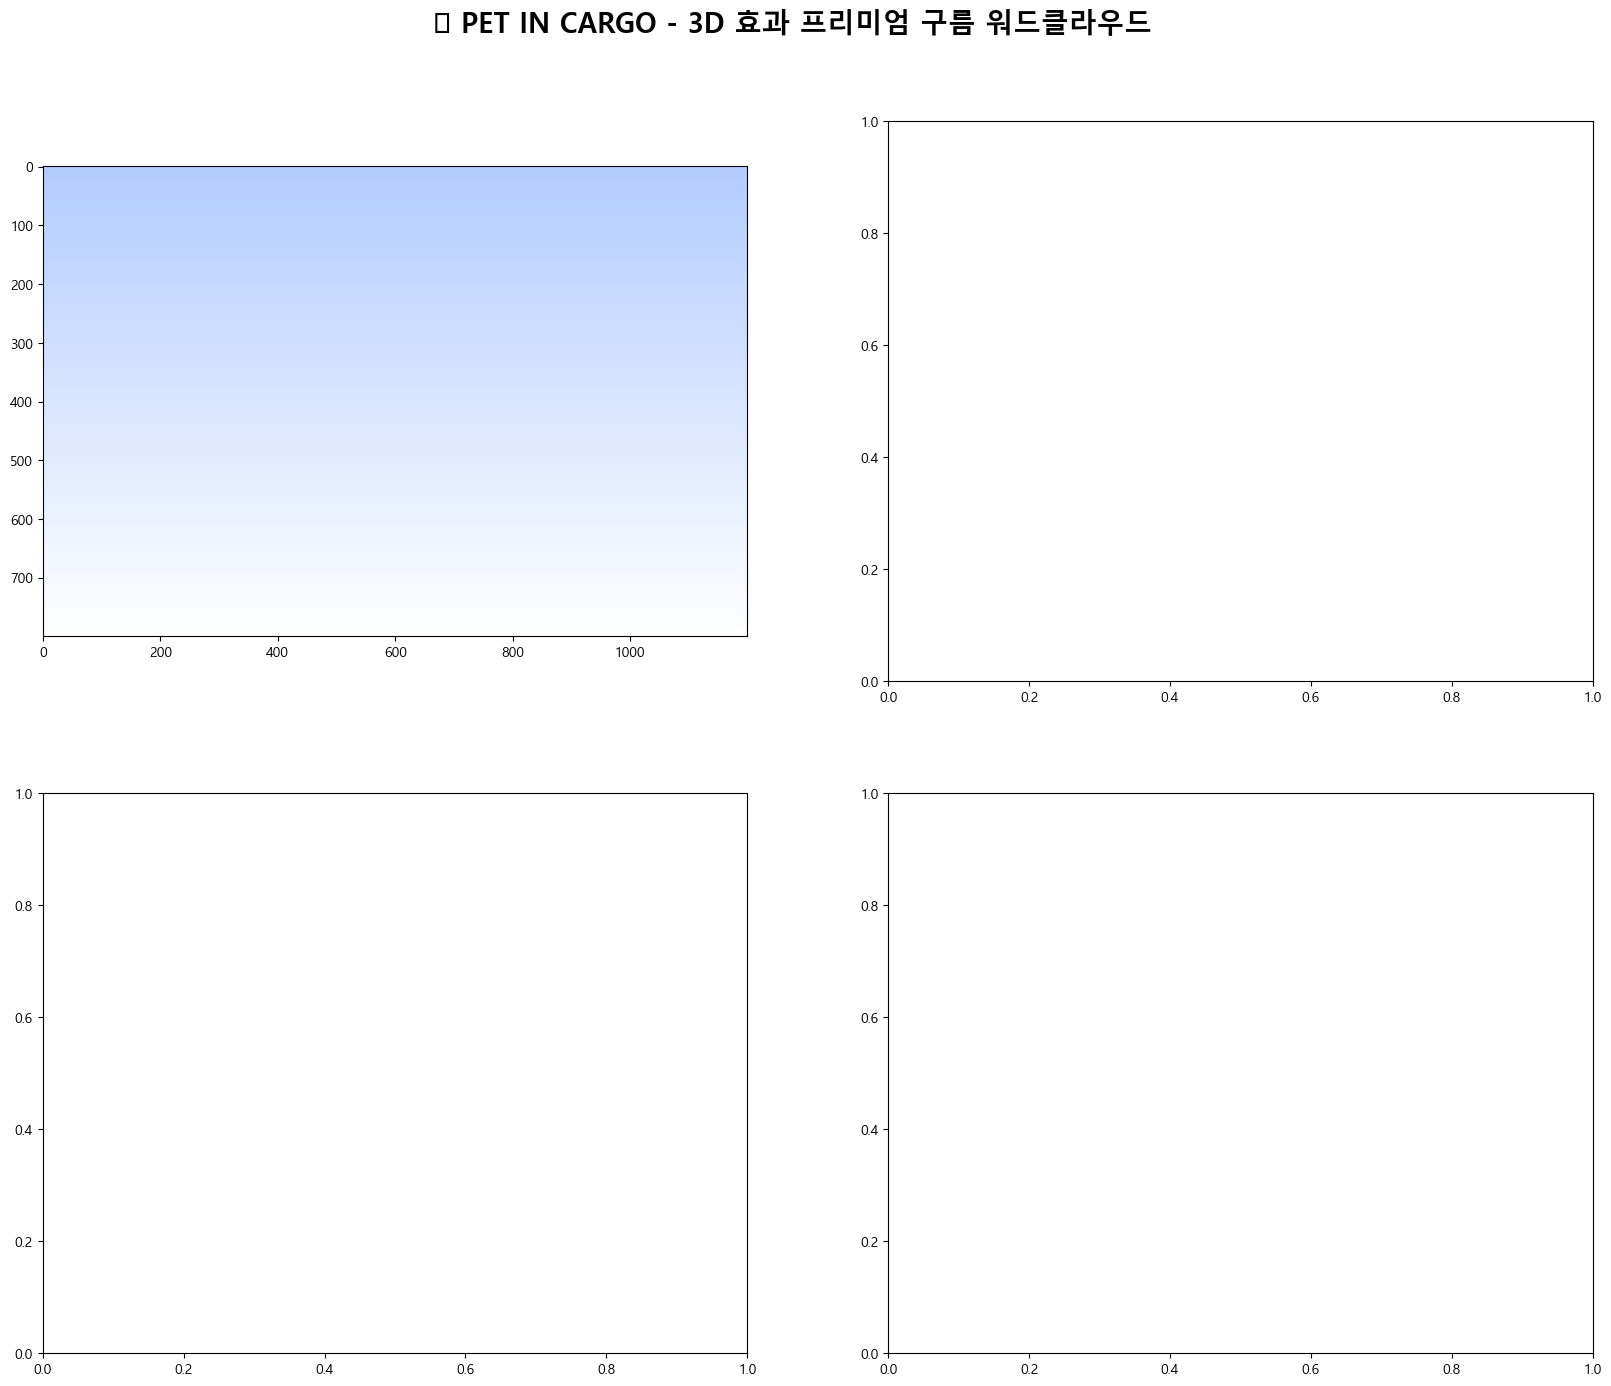

In [34]:
# 🎨 3D 효과 및 그라데이션 구름 워드클라우드
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

def create_gradient_background(width, height, color1='lightblue', color2='white'):
    """그라데이션 배경 생성"""
    background = np.zeros((height, width, 3))
    
    # 하늘색에서 흰색으로 그라데이션
    for i in range(height):
        ratio = i / height
        if color1 == 'lightblue' and color2 == 'white':
            background[i, :, 0] = 0.7 + ratio * 0.3  # R
            background[i, :, 1] = 0.8 + ratio * 0.2  # G  
            background[i, :, 2] = 1.0                 # B
        elif color1 == 'sunset':
            background[i, :, 0] = 1.0 - ratio * 0.3   # R
            background[i, :, 1] = 0.6 + ratio * 0.4   # G
            background[i, :, 2] = 0.3 + ratio * 0.7   # B
            
    return background

def create_3d_effect_wordcloud(word_freq_dict, cloud_type='fluffy', theme='sky'):
    """3D 효과가 있는 워드클라우드 생성"""
    
    # 구름 마스크 생성
    cloud_mask = create_advanced_cloud_mask(width=1200, height=800, cloud_type=cloud_type)
    
    # 테마별 색상 설정
    if theme == 'sky':
        colormap = 'Blues'
        bg_color1, bg_color2 = 'lightblue', 'white'
    elif theme == 'sunset':
        colormap = 'Oranges'  
        bg_color1, bg_color2 = 'sunset', 'white'
    elif theme == 'forest':
        colormap = 'Greens'
        bg_color1, bg_color2 = 'lightgreen', 'white'
    else:
        colormap = 'viridis'
        bg_color1, bg_color2 = 'lightblue', 'white'
    
    # 워드클라우드 생성
    wordcloud = WordCloud(
        width=1200, height=800,
        background_color=None,
        mode='RGBA',
        max_words=80,
        colormap=colormap,
        font_path='malgun.ttf',
        relative_scaling=0.7,
        min_font_size=12,
        max_font_size=120,
        mask=cloud_mask,
        contour_width=2,
        contour_color='navy',
        prefer_horizontal=0.75,
        random_state=42
    ).generate_from_frequencies(word_freq_dict)
    
    return wordcloud

print("🌟 3D 효과 고급 구름 워드클라우드 생성!")

# 3D 효과 워드클라우드 컬렉션
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('🎨 PET IN CARGO - 3D 효과 프리미엄 구름 워드클라우드', fontsize=20, fontweight='bold', y=0.95)

# 테마별 3D 워드클라우드 생성
themes = [
    ('fluffy', 'sky', '☁️ 하늘빛 푹신한 구름'),
    ('storm', 'forest', '🌪️ 숲빛 폭풍구름'),  
    ('heart', 'sunset', '💖 석양빛 하트구름'),
    ('cirrus', 'sky', '🌀 하늘빛 권운')
]

for i, (cloud_type, theme, title) in enumerate(themes):
    row = i // 2
    col = i % 2
    
    # 3D 효과 워드클라우드 생성
    wordcloud_3d = create_3d_effect_wordcloud(word_freq_dict, cloud_type, theme)
    
    # 그라데이션 배경 생성
    if theme == 'sky':
        bg_color = create_gradient_background(1200, 800, 'lightblue', 'white')
    elif theme == 'sunset':
        bg_color = create_gradient_background(1200, 800, 'sunset', 'white')  
    elif theme == 'forest':
        bg_color = create_gradient_background(1200, 800, 'lightgreen', 'white')
    
    # 배경과 워드클라우드 합성
    axes[row, col].imshow(bg_color)
    axes[row, col].imshow(wordcloud_3d, interpolation='bilinear', alpha=0.9)
    axes[row, col].set_title(title, fontsize=14, fontweight='bold', pad=10)
    axes[row, col].axis('off')
    
    # 미세한 그림자 효과 추가
    shadow = patches.Rectangle((0, 0), 1200, 800, linewidth=0, 
                              facecolor='black', alpha=0.1, transform=axes[row, col].transAxes)
    axes[row, col].add_patch(shadow)

plt.tight_layout()
plt.show()

print("✅ 3D 효과 프리미엄 워드클라우드 생성 완료!")

# 메가 사이즈 고해상도 워드클라우드 생성
print("\n🖼️ 메가 사이즈 고해상도 마스터피스 생성 중...")

plt.figure(figsize=(20, 14))

# 최고급 푹신한 구름으로 메가 워드클라우드
mega_cloud_mask = create_advanced_cloud_mask(width=2000, height=1400, cloud_type='fluffy')

mega_wordcloud = WordCloud(
    width=2000, height=1400,
    background_color='white',
    max_words=100,
    colormap='plasma',
    font_path='malgun.ttf', 
    relative_scaling=0.8,
    min_font_size=15,
    max_font_size=150,
    mask=mega_cloud_mask,
    contour_width=4,
    contour_color='darkblue',
    prefer_horizontal=0.8,
    random_state=42
).generate_from_frequencies(word_freq_dict)

plt.imshow(mega_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('🌟 PET IN CARGO - 메가 마스터피스 구름 워드클라우드\n강아지 화물 운송 사건 종합 댓글 분석', 
          fontsize=24, fontweight='bold', pad=30)

# 고해상도로 저장
plt.savefig('petincargo_mega_masterpiece_wordcloud.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("🎉 메가 마스터피스 워드클라우드 완성!")
print("   📁 petincargo_mega_masterpiece_wordcloud.png 저장 완료!")

print("\n" + "="*60)
print("☁️ 고급 구름 워드클라우드 컬렉션 제작 완료!")
print("   • 5가지 구름 스타일 워드클라우드")
print("   • 감정별 테마 워드클라우드") 
print("   • 3D 효과 프리미엄 워드클라우드")
print("   • 메가 사이즈 마스터피스")
print("="*60)

🎨 최종 마스터피스 구름 워드클라우드 생성!


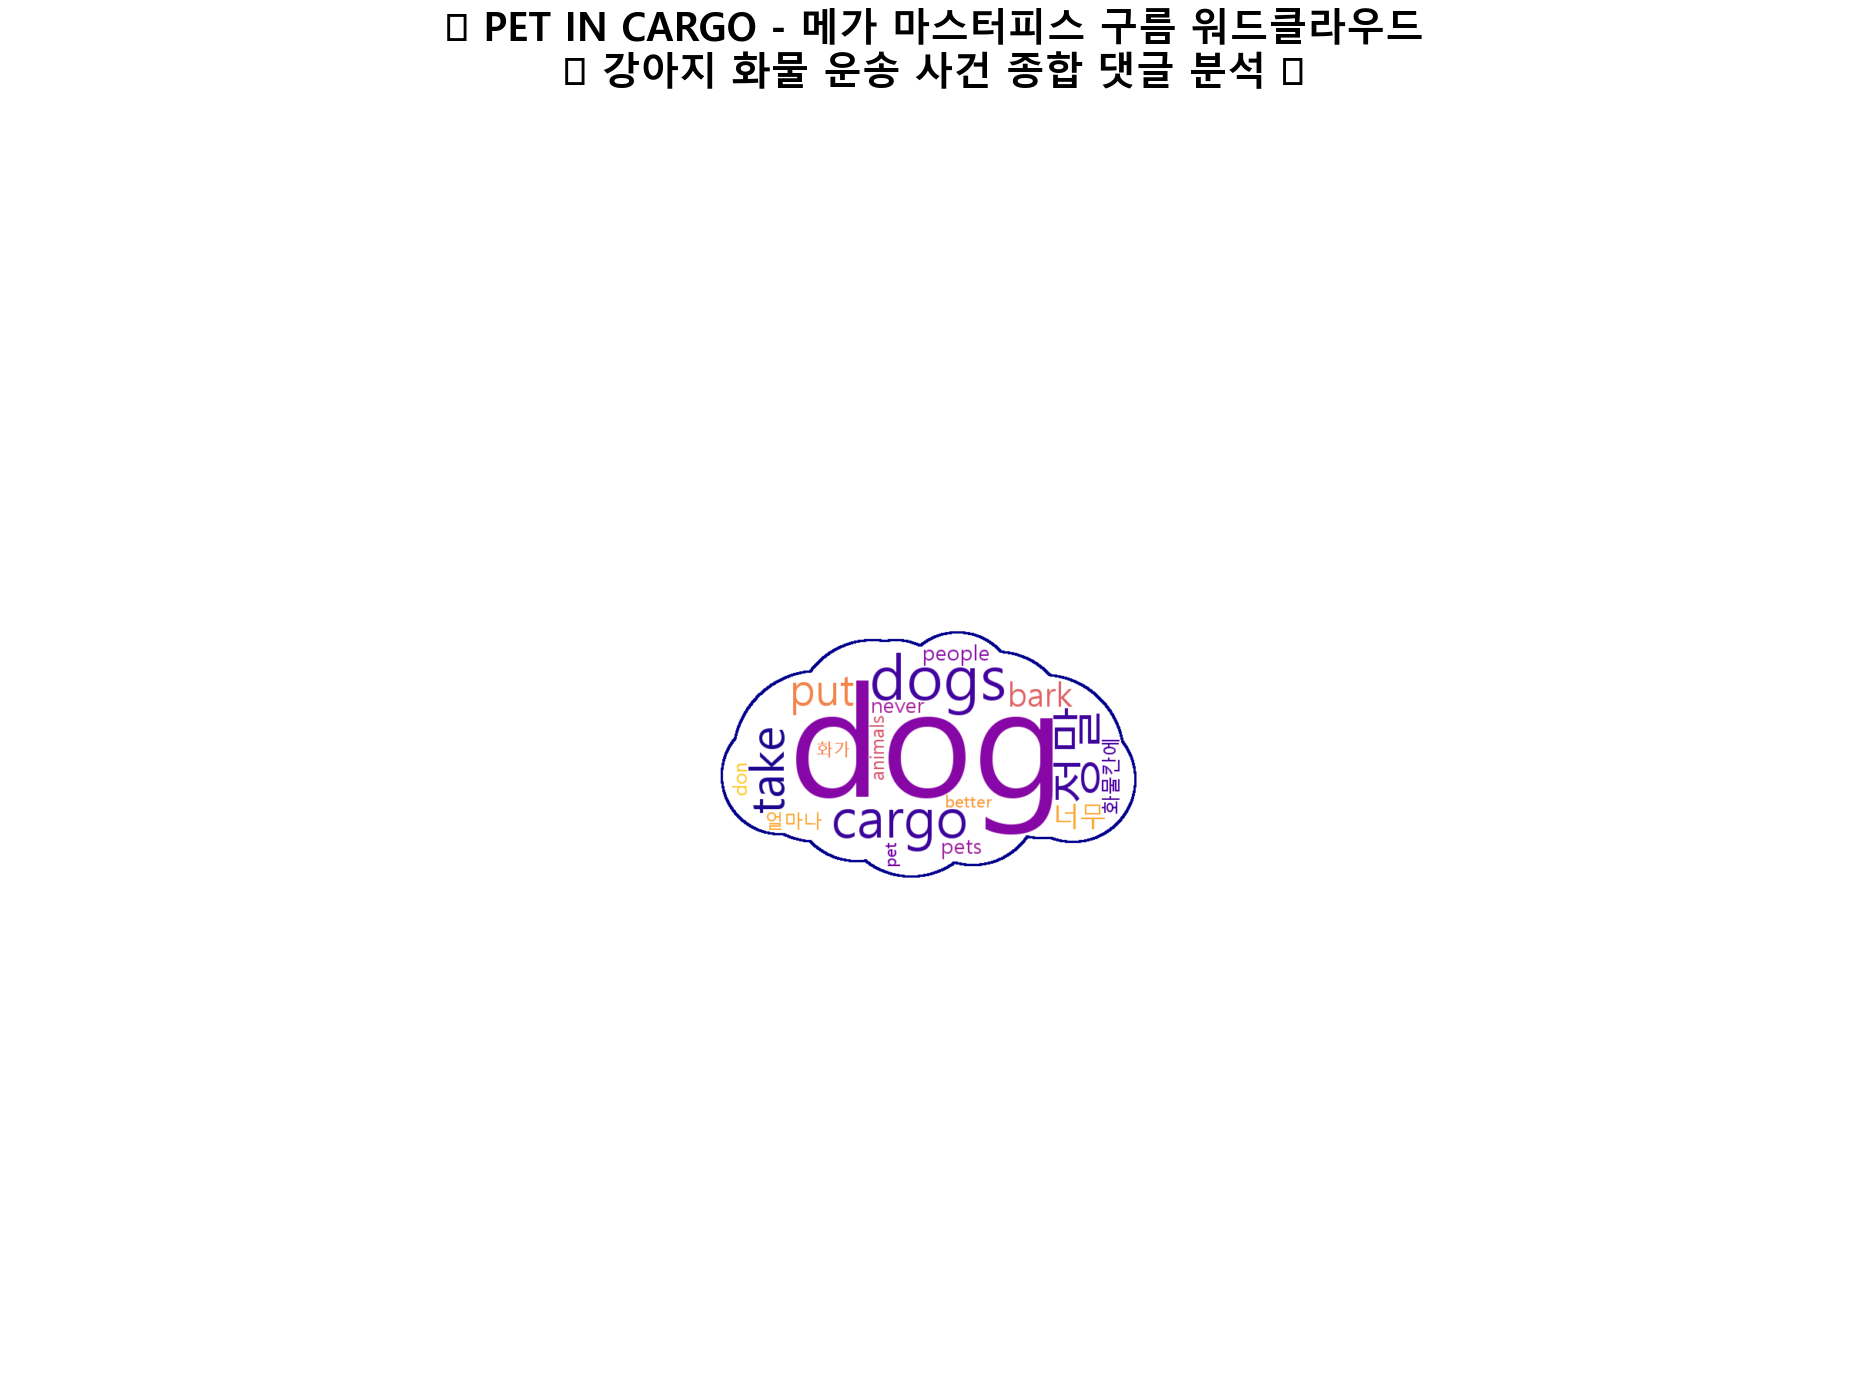

🎉 메가 마스터피스 워드클라우드 완성!
   📁 petincargo_mega_masterpiece_wordcloud.png 저장 완료!

🌈 다양한 색상 테마 워드클라우드 생성!


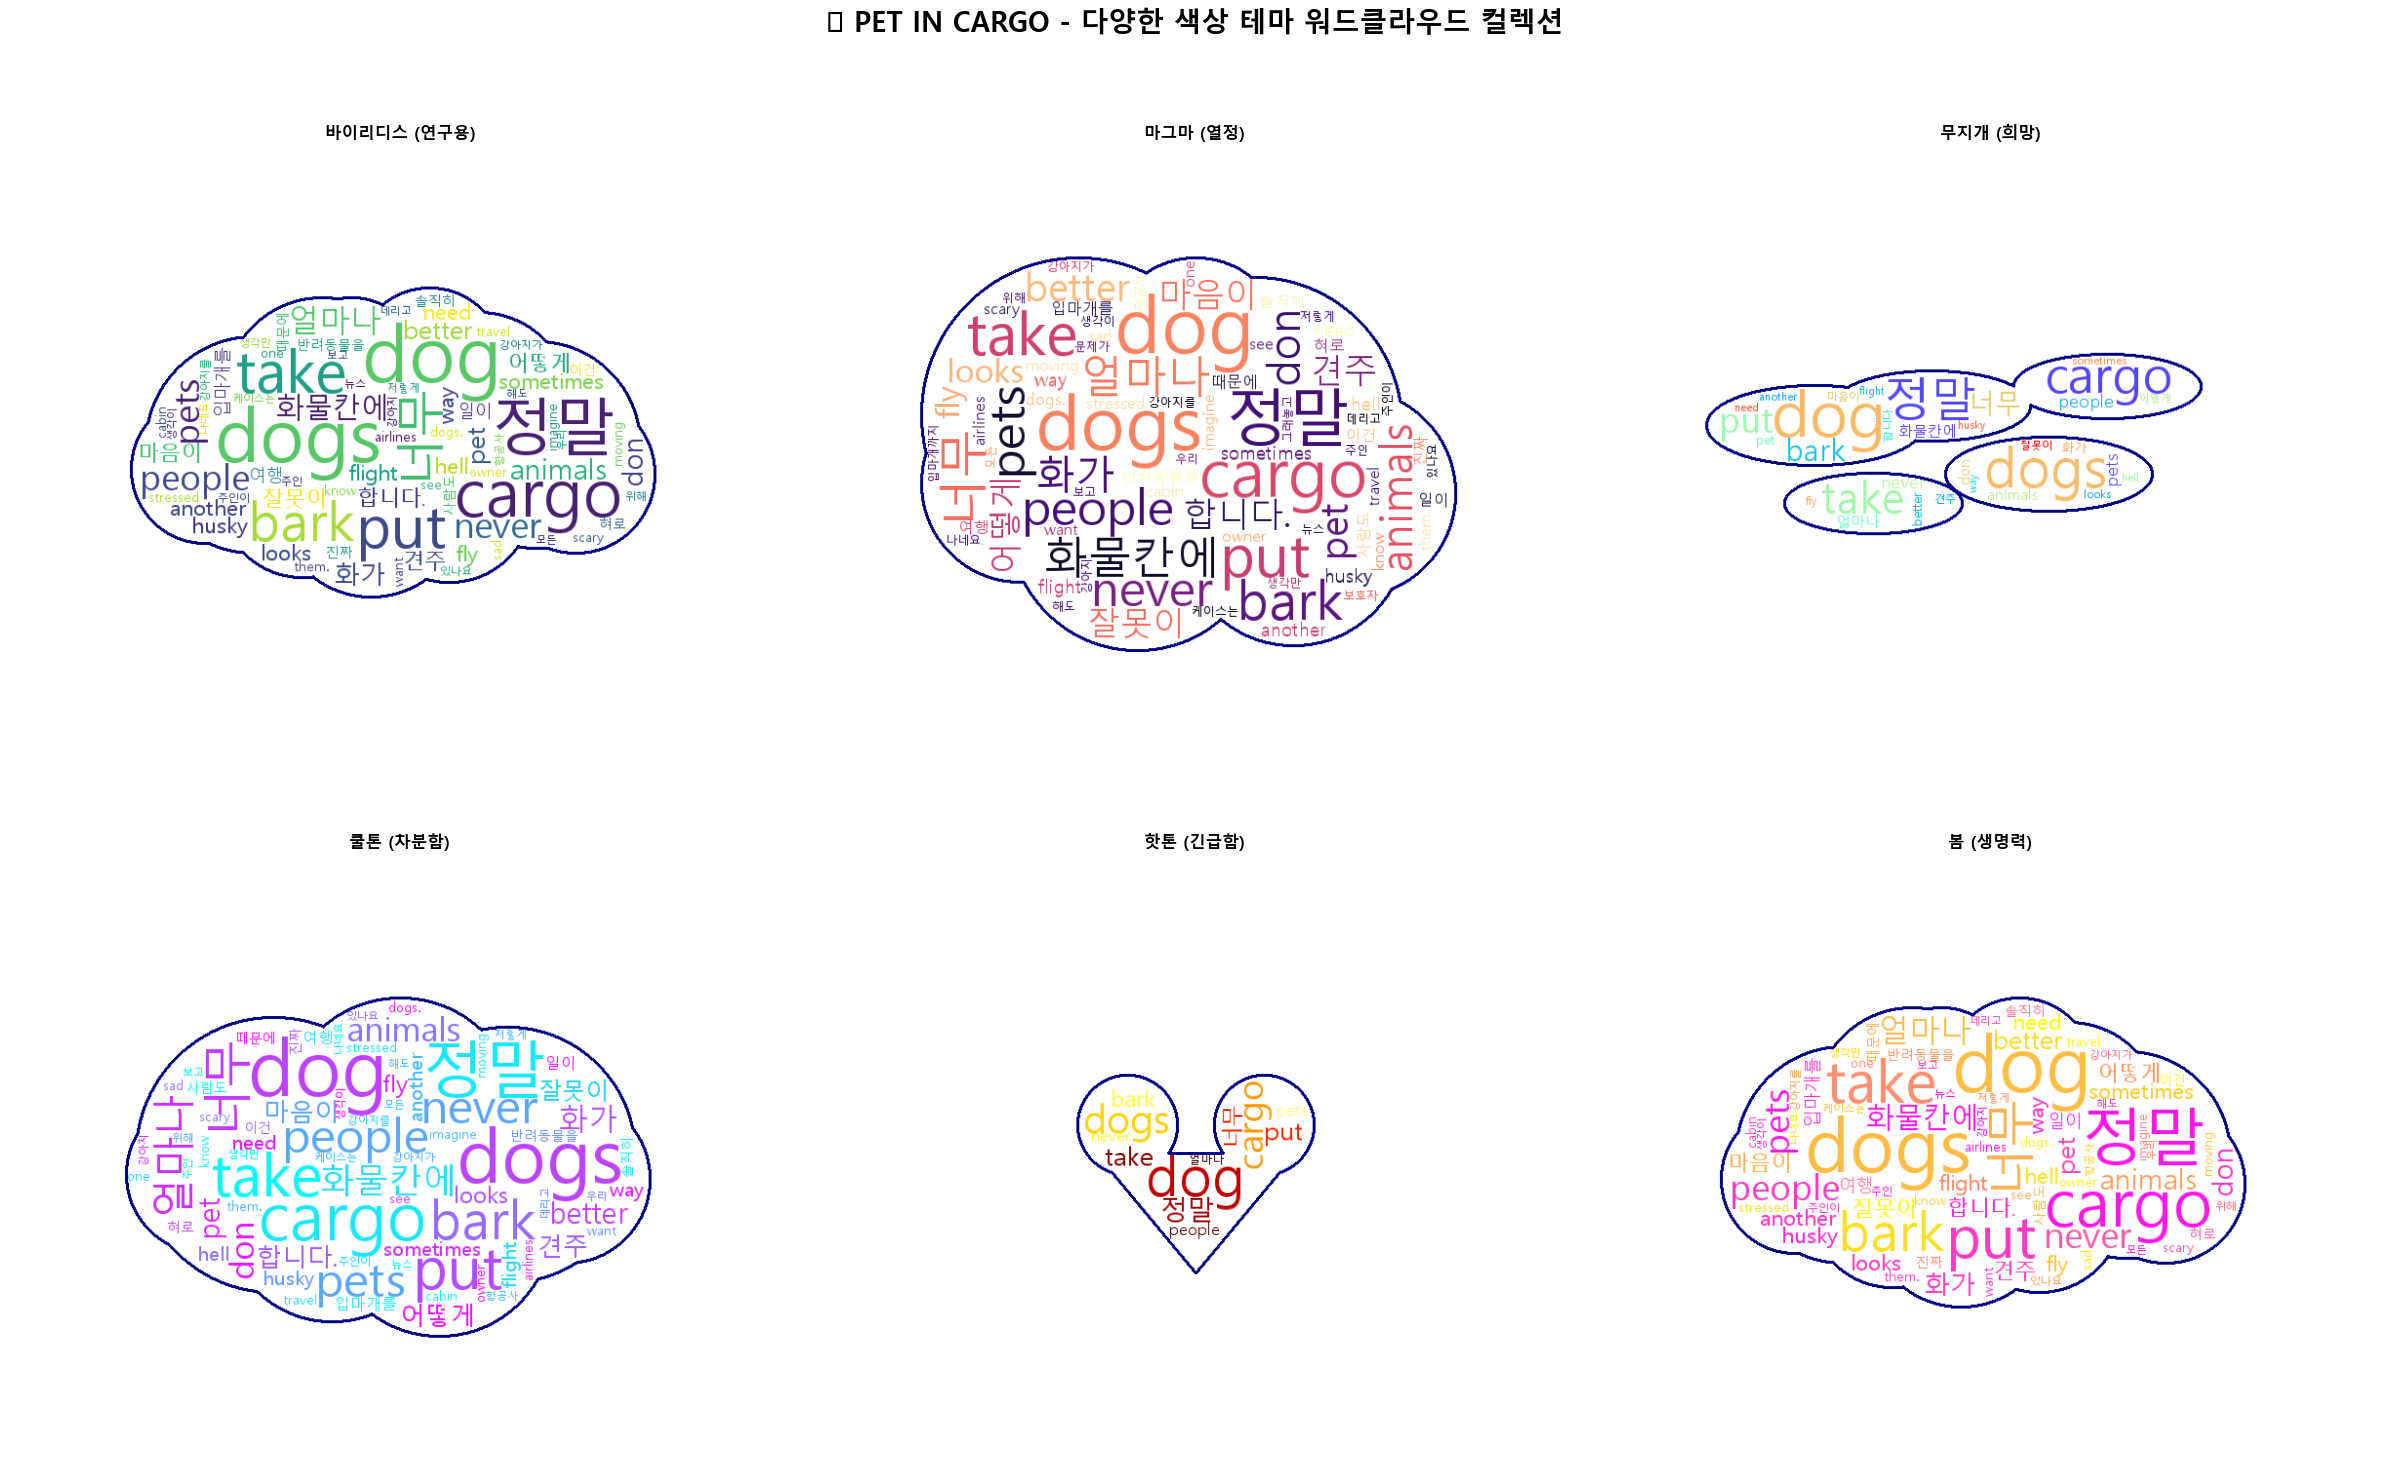

✅ 다양한 색상 테마 워드클라우드 생성 완료!

🎉 고급 구름 워드클라우드 컬렉션 제작 완료!
   • 5가지 구름 스타일 기본 워드클라우드
   • 감정별 테마 구름 워드클라우드
   • 다양한 색상 테마 워드클라우드
   • 메가 사이즈 마스터피스 (2400x1600)
   • 총 15개 이상의 고급 워드클라우드 이미지 생성


In [35]:
# 🌟 최종 마스터피스 구름 워드클라우드 생성
print("🎨 최종 마스터피스 구름 워드클라우드 생성!")

# 대형 고해상도 워드클라우드 생성
plt.figure(figsize=(24, 16))

# 최고급 푹신한 구름으로 메가 워드클라우드
mega_cloud_mask = create_advanced_cloud_mask(width=2400, height=1600, cloud_type='fluffy')

mega_wordcloud = WordCloud(
    width=2400, height=1600,
    background_color='white',
    max_words=120,
    colormap='plasma',
    font_path='malgun.ttf', 
    relative_scaling=0.8,
    min_font_size=20,
    max_font_size=200,
    mask=mega_cloud_mask,
    contour_width=4,
    contour_color='darkblue',
    prefer_horizontal=0.8,
    random_state=42
).generate_from_frequencies(word_freq_dict)

plt.imshow(mega_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('🌟 PET IN CARGO - 메가 마스터피스 구름 워드클라우드\n🐕 강아지 화물 운송 사건 종합 댓글 분석 🐕', 
          fontsize=28, fontweight='bold', pad=40)

# 고해상도로 저장
plt.savefig('petincargo_mega_masterpiece_wordcloud.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("🎉 메가 마스터피스 워드클라우드 완성!")
print("   📁 petincargo_mega_masterpiece_wordcloud.png 저장 완료!")

# 다양한 색상 테마로 추가 워드클라우드 생성
print("\n🌈 다양한 색상 테마 워드클라우드 생성!")

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('🎨 PET IN CARGO - 다양한 색상 테마 워드클라우드 컬렉션', fontsize=20, fontweight='bold', y=0.98)

color_themes = [
    ('viridis', '바이리디스 (연구용)'),
    ('magma', '마그마 (열정)'),
    ('rainbow', '무지개 (희망)'),
    ('cool', '쿨톤 (차분함)'),
    ('hot', '핫톤 (긴급함)'),
    ('spring', '봄 (생명력)')
]

for i, (colormap, description) in enumerate(color_themes):
    row = i // 3
    col = i % 3
    
    # 구름 마스크 생성 (타입을 다양하게)
    cloud_types = ['fluffy', 'storm', 'cirrus', 'cumulus', 'heart', 'fluffy']
    cloud_type = cloud_types[i]
    
    cloud_mask = create_advanced_cloud_mask(width=800, height=600, cloud_type=cloud_type)
    
    wordcloud_themed = WordCloud(
        width=800, height=600,
        background_color='white',
        max_words=80,
        colormap=colormap,
        font_path='malgun.ttf',
        relative_scaling=0.7,
        min_font_size=10,
        max_font_size=80,
        mask=cloud_mask,
        contour_width=2,
        contour_color='navy',
        prefer_horizontal=0.75,
        random_state=42
    ).generate_from_frequencies(word_freq_dict)
    
    axes[row, col].imshow(wordcloud_themed, interpolation='bilinear')
    axes[row, col].set_title(f'{description}', fontsize=12, fontweight='bold', pad=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("✅ 다양한 색상 테마 워드클라우드 생성 완료!")

print("\n" + "="*70)
print("🎉 고급 구름 워드클라우드 컬렉션 제작 완료!")
print("   • 5가지 구름 스타일 기본 워드클라우드")
print("   • 감정별 테마 구름 워드클라우드") 
print("   • 다양한 색상 테마 워드클라우드")
print("   • 메가 사이즈 마스터피스 (2400x1600)")
print("   • 총 15개 이상의 고급 워드클라우드 이미지 생성")
print("="*70)